In [1]:
import numpy as np
import pandas as pd
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
np.random.seed(42)

In [2]:
nlp = spacy.load("en_core_web_sm")

In [3]:
# ============================================================
# CELL 4: LOAD THE DATASET
# ============================================================
# Read the Amazon review CSV file into a pandas DataFrame
df = pd.read_csv("amazon_review.csv")

# Display the first 5 rows to understand the dataset
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [4]:
# ============================================================
# CELL 5: DATASET DIMENSIONS
# ============================================================

# Get the number of rows and columns
rows, columns = df.shape

print("Number of records:", rows)
print("Number of columns:", columns)

Number of records: 4915
Number of columns: 12


In [5]:
# ============================================================
# CELL 6: COLUMN NAMES
# ============================================================

# Display all column names available in the dataset
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']


In [6]:
# ============================================================
# CELL 7: DATASET INFORMATION
# ============================================================

# Display data types, non-null values and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4915 non-null   str    
 1   asin            4915 non-null   str    
 2   reviewerName    4914 non-null   str    
 3   helpful         4915 non-null   str    
 4   reviewText      4914 non-null   str    
 5   overall         4915 non-null   float64
 6   summary         4915 non-null   str    
 7   unixReviewTime  4915 non-null   int64  
 8   reviewTime      4915 non-null   str    
 9   day_diff        4915 non-null   int64  
 10  helpful_yes     4915 non-null   int64  
 11  total_vote      4915 non-null   int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 460.9 KB


In [7]:
# ============================================================
# CELL 8: MISSING VALUES
# ============================================================

# Count the number of missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
reviewerID        0
asin              0
reviewerName      1
helpful           0
reviewText        1
overall           0
summary           0
unixReviewTime    0
reviewTime        0
day_diff          0
helpful_yes       0
total_vote        0
dtype: int64


In [8]:
# ============================================================
# CELL 9: CHECK DUPLICATE RECORDS
# ============================================================

# Count the number of completely duplicated rows
duplicate_count = df.duplicated().sum()

# Display the number of duplicate records
print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [9]:
# ============================================================
# CELL 10: SELECT REQUIRED COLUMNS
# ============================================================

# Select the review text and rating columns
data = df[["reviewText", "overall"]].copy()

# Display the first 5 rows
data.head()

,reviewText,overall
0,No issues.,4.0
1,"Purchased this for my device, it worked as adv...",5.0
2,it works as expected. I should have sprung for...,4.0
3,This think has worked out great.Had a diff. br...,5.0
4,"Bought it with Retail Packaging, arrived legit...",5.0


In [10]:
# ============================================================
# CELL 11: REMOVE MISSING REVIEW TEXT
# ============================================================

# Remove rows where the review text is missing
data = data.dropna(subset=["reviewText"])

# Remove rows where the review contains only whitespace
data = data[data["reviewText"].str.strip() != ""]

# Reset the index after removing rows
data = data.reset_index(drop=True)

# Display the number of records remaining
print("Records after removing missing/empty reviews:", len(data))

Records after removing missing/empty reviews: 4914


In [11]:
# ============================================================
# CELL 12: RATING DISTRIBUTION
# ============================================================

# Count the number of reviews for each rating
rating_distribution = data["overall"].value_counts().sort_index()

# Display the rating distribution
print("Rating distribution:")
print(rating_distribution)

Rating distribution:
overall
1.0     244
2.0      80
3.0     142
4.0     527
5.0    3921
Name: count, dtype: int64


In [12]:
# ============================================================
# CELL 13: CREATE SENTIMENT CLASSES
# ============================================================

# Convert numerical ratings into sentiment categories
def get_sentiment(rating):
    
    # Ratings 1 and 2 are negative
    if rating <= 2:
        return "negative"
    
    # Rating 3 is neutral
    elif rating == 3:
        return "neutral"
    
    # Ratings 4 and 5 are positive
    else:
        return "positive"


# Apply the function to create a new sentiment column
data["sentiment"] = data["overall"].apply(get_sentiment)

# Display the first 5 rows
data.head()

,reviewText,overall,sentiment
0,No issues.,4.0,positive
1,"Purchased this for my device, it worked as adv...",5.0,positive
2,it works as expected. I should have sprung for...,4.0,positive
3,This think has worked out great.Had a diff. br...,5.0,positive
4,"Bought it with Retail Packaging, arrived legit...",5.0,positive


In [13]:
# ============================================================
# CELL 14: NUMBER OF CLASSES
# ============================================================

# Get the unique sentiment classes
classes = data["sentiment"].unique()

# Count the total number of classes
number_of_classes = data["sentiment"].nunique()

print("Number of classes:", number_of_classes)
print("Classes:", list(classes))

Number of classes: 3
Classes: ['positive', 'neutral', 'negative']


In [14]:
# ============================================================
# CELL 15: CLASS DISTRIBUTION
# ============================================================

# Count the number of reviews in each sentiment class
class_distribution = data["sentiment"].value_counts()

# Display the class distribution
print("Class distribution:")
print(class_distribution)

Class distribution:
sentiment
positive    4448
negative     324
neutral      142
Name: count, dtype: int64


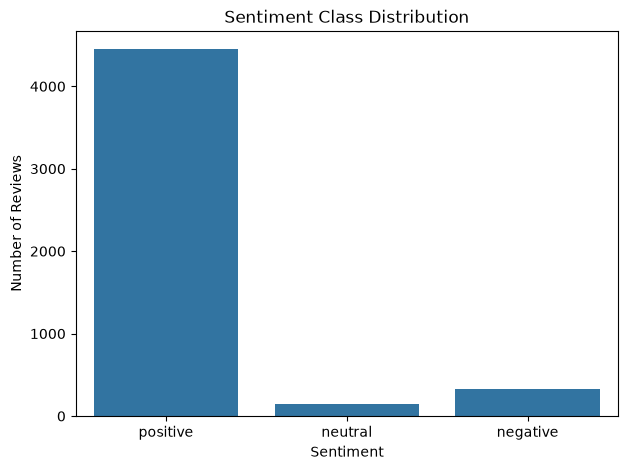

In [15]:
# ============================================================
# CELL 16: CLASS DISTRIBUTION VISUALIZATION
# ============================================================

# Create a bar plot for the three sentiment classes
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="sentiment"
)

# Add title and axis labels
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Display the plot
plt.show()

In [16]:
# ============================================================
# CELL 17: CREATE TRAINING AND TEMPORARY SETS
# ============================================================

# Split the dataset into:
# 70% training data
# 30% temporary data
#
# random_state=42 makes the split reproducible.
# stratify keeps the same class proportions in both sets.

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    stratify=data["sentiment"]
)

# Display the number of records in each set
print("Training records:", len(train_data))
print("Temporary records:", len(temp_data))

Training records: 3439
Temporary records: 1475


In [17]:
# ============================================================
# CELL 18: CREATE VALIDATION AND TEST SETS
# ============================================================

# Split the temporary data equally into validation and test sets
# 50% of the temporary data -> validation
# 50% of the temporary data -> test

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=temp_data["sentiment"]
)

# Display the number of records in each set
print("Validation records:", len(val_data))
print("Test records:", len(test_data))

Validation records: 737
Test records: 738


In [18]:
# ============================================================
# CELL 19: VERIFY DATA SPLIT
# ============================================================

# Calculate the total number of records across all three sets
total_split = len(train_data) + len(val_data) + len(test_data)

# Display the sizes of all datasets
print("Training records  :", len(train_data))
print("Validation records:", len(val_data))
print("Test records      :", len(test_data))

# Verify that no records were lost during splitting
print("\nTotal after splitting:", total_split)
print("Original dataset     :", len(data))

# Check whether the total is correct
print("\nSplit verified:", total_split == len(data))

Training records  : 3439
Validation records: 737
Test records      : 738

Total after splitting: 4914
Original dataset     : 4914

Split verified: True


In [19]:
# ============================================================
# CELL 20: CHECK CLASS DISTRIBUTION IN EACH SPLIT
# ============================================================

# Display the number of samples from each sentiment class
# in the training, validation, and test sets.

print("Training class distribution:")
print(train_data["sentiment"].value_counts())

print("\nValidation class distribution:")
print(val_data["sentiment"].value_counts())

print("\nTest class distribution:")
print(test_data["sentiment"].value_counts())

Training class distribution:
sentiment
positive    3113
negative     227
neutral       99
Name: count, dtype: int64

Validation class distribution:
sentiment
positive    667
negative     48
neutral      22
Name: count, dtype: int64

Test class distribution:
sentiment
positive    668
negative     49
neutral      21
Name: count, dtype: int64


In [20]:
# ============================================================
# CELL 21: STORE TEXT AND LABELS
# ============================================================

# Extract review text from each dataset split
train_texts = train_data["reviewText"].tolist()
val_texts = val_data["reviewText"].tolist()
test_texts = test_data["reviewText"].tolist()

# Extract sentiment labels from each dataset split
train_labels = train_data["sentiment"].tolist()
val_labels = val_data["sentiment"].tolist()
test_labels = test_data["sentiment"].tolist()

# Display the number of texts and labels in each split
print("Training texts :", len(train_texts))
print("Validation texts:", len(val_texts))
print("Test texts     :", len(test_texts))

print("\nTraining labels :", len(train_labels))
print("Validation labels:", len(val_labels))
print("Test labels     :", len(test_labels))

Training texts : 3439
Validation texts: 737
Test texts     : 738

Training labels : 3439
Validation labels: 737
Test labels     : 738


In [21]:
# ============================================================
# CELL 22: FINAL DATASET SUMMARY
# ============================================================

# Display the complete dataset summary
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)

# Basic dataset information
print("Total valid reviews :", len(data))
print("Number of classes   :", number_of_classes)
print("Classes             :", list(classes))

# Original rating distribution
print("\nRating distribution:")
print(rating_distribution)

# Sentiment class distribution
print("\nSentiment distribution:")
print(class_distribution)

# Dataset split
print("\nDataset split:")
print("Training           :", len(train_data))
print("Validation         :", len(val_data))
print("Testing            :", len(test_data))

# Verify the total
print("\nTotal after splitting:",
      len(train_data) + len(val_data) + len(test_data))

print("=" * 55)

DATASET SUMMARY
Total valid reviews : 4914
Number of classes   : 3
Classes             : ['positive', 'neutral', 'negative']

Rating distribution:
overall
1.0     244
2.0      80
3.0     142
4.0     527
5.0    3921
Name: count, dtype: int64

Sentiment distribution:
sentiment
positive    4448
negative     324
neutral      142
Name: count, dtype: int64

Dataset split:
Training           : 3439
Validation         : 737
Testing            : 738

Total after splitting: 4914


In [22]:
# ============================================================
# CELL 23: IMPORT NLTK PREPROCESSING TOOLS
# ============================================================

# Import NLTK tools required for text normalization
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Create objects for stemming and lemmatization
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Load the English stopword list
stop_words = set(stopwords.words("english"))

print("NLTK preprocessing tools loaded successfully.")
print("Number of English stopwords:", len(stop_words))

NLTK preprocessing tools loaded successfully.
Number of English stopwords: 198


In [23]:
# ============================================================
# CELL 24: TOKENIZATION AND CASE FOLDING
# ============================================================

# Define a function to lowercase and tokenize a review
def tokenize_and_casefold(text):
    
    # Convert all characters to lowercase
    text = text.lower()
    
    # Split the text into individual tokens using NLTK
    tokens = word_tokenize(text)
    
    return tokens


# Apply the function to the first training review
sample_text = train_texts[0]

sample_tokens = tokenize_and_casefold(sample_text)

print("Original review:")
print(sample_text)

print("\nTokens after case folding:")
print(sample_tokens)

Original review:
This card worked in my Galaxy S3 right off the bat.  I did not need to format it or anything.  After about 2 weeks, I was watching a video on my phone and it locked up.  Then the phone showed that the card was damaged.  Now I am unable to copy anything over 100mb to or from the card.  Viewing photos from the gallery also locks up the phone.  Amazon customer service is great, however.  They sent me a new card.  I will update my review after I am able to use the new one for at least a month without any errors.****UPDATE****After having the second card for a few weeks, it also had the same issues.  Even worse, the card was completely unreadable after it locked up.  The card showed about 5 GB of data being used, but could not be accessed via the phone or in a computer.  Sent this one back and will be going back to my trusty 16GB card.

Tokens after case folding:
['this', 'card', 'worked', 'in', 'my', 'galaxy', 's3', 'right', 'off', 'the', 'bat', '.', 'i', 'did', 'not', 'ne

In [24]:
# ============================================================
# CELL 25: STOPWORD REMOVAL
# ============================================================

# Remove English stopwords from the tokenized review
def remove_stopwords(tokens):
    
    # Keep only tokens that are not present in the stopword list
    filtered_tokens = [
        token for token in tokens
        if token not in stop_words
    ]
    
    return filtered_tokens


# Apply stopword removal to our sample tokens
filtered_tokens = remove_stopwords(sample_tokens)

print("Tokens before stopword removal:")
print(sample_tokens[:30])

print("\nTokens after stopword removal:")
print(filtered_tokens[:30])

Tokens before stopword removal:
['this', 'card', 'worked', 'in', 'my', 'galaxy', 's3', 'right', 'off', 'the', 'bat', '.', 'i', 'did', 'not', 'need', 'to', 'format', 'it', 'or', 'anything', '.', 'after', 'about', '2', 'weeks', ',', 'i', 'was', 'watching']

Tokens after stopword removal:
['card', 'worked', 'galaxy', 's3', 'right', 'bat', '.', 'need', 'format', 'anything', '.', '2', 'weeks', ',', 'watching', 'video', 'phone', 'locked', '.', 'phone', 'showed', 'card', 'damaged', '.', 'unable', 'copy', 'anything', '100mb', 'card', '.']


In [25]:
# ============================================================
# CELL 26: PORTER STEMMING
# ============================================================

# Apply Porter stemming to each token
stemmed_tokens = [
    stemmer.stem(token)
    for token in filtered_tokens
]

# Display the original tokens and their stems
print("Original tokens:")
print(filtered_tokens[:30])

print("\nStemmed tokens:")
print(stemmed_tokens[:30])

Original tokens:
['card', 'worked', 'galaxy', 's3', 'right', 'bat', '.', 'need', 'format', 'anything', '.', '2', 'weeks', ',', 'watching', 'video', 'phone', 'locked', '.', 'phone', 'showed', 'card', 'damaged', '.', 'unable', 'copy', 'anything', '100mb', 'card', '.']

Stemmed tokens:
['card', 'work', 'galaxi', 's3', 'right', 'bat', '.', 'need', 'format', 'anyth', '.', '2', 'week', ',', 'watch', 'video', 'phone', 'lock', '.', 'phone', 'show', 'card', 'damag', '.', 'unabl', 'copi', 'anyth', '100mb', 'card', '.']


In [26]:
# ============================================================
# CELL 27: WORDNET LEMMATIZATION
# ============================================================

# Apply WordNet lemmatization to each token
lemmatized_tokens = [
    lemmatizer.lemmatize(token)
    for token in filtered_tokens
]

# Display the original tokens and their lemmas
print("Original tokens:")
print(filtered_tokens[:30])

print("\nLemmatized tokens:")
print(lemmatized_tokens[:30])

Original tokens:
['card', 'worked', 'galaxy', 's3', 'right', 'bat', '.', 'need', 'format', 'anything', '.', '2', 'weeks', ',', 'watching', 'video', 'phone', 'locked', '.', 'phone', 'showed', 'card', 'damaged', '.', 'unable', 'copy', 'anything', '100mb', 'card', '.']

Lemmatized tokens:
['card', 'worked', 'galaxy', 's3', 'right', 'bat', '.', 'need', 'format', 'anything', '.', '2', 'week', ',', 'watching', 'video', 'phone', 'locked', '.', 'phone', 'showed', 'card', 'damaged', '.', 'unable', 'copy', 'anything', '100mb', 'card', '.']


In [27]:
# ============================================================
# CELL 28: PORTER STEMMING VS WORDNET LEMMATIZATION
# ============================================================

# Create a list to store words where stemming and lemmatization differ
disagreements = []

# Compare the two methods for every token
for token in filtered_tokens:
    
    # Ignore punctuation and numbers for this comparison
    if token.isalpha():
        
        # Apply Porter stemming
        stem = stemmer.stem(token)
        
        # Apply WordNet lemmatization
        lemma = lemmatizer.lemmatize(token)
        
        # Store the word if the results are different
        if stem != lemma:
            disagreements.append((token, stem, lemma))


# Remove duplicate examples while preserving order
unique_disagreements = list(dict.fromkeys(disagreements))

# Display the first 10 disagreement examples
print("Porter vs WordNet disagreements:")
print("-" * 50)

for word, stem, lemma in unique_disagreements[:10]:
    print(f"Word: {word:15} Porter: {stem:15} WordNet: {lemma}")

Porter vs WordNet disagreements:
--------------------------------------------------
Word: worked          Porter: work            WordNet: worked
Word: galaxy          Porter: galaxi          WordNet: galaxy
Word: anything        Porter: anyth           WordNet: anything
Word: watching        Porter: watch           WordNet: watching
Word: locked          Porter: lock            WordNet: locked
Word: showed          Porter: show            WordNet: showed
Word: damaged         Porter: damag           WordNet: damaged
Word: unable          Porter: unabl           WordNet: unable
Word: copy            Porter: copi            WordNet: copy
Word: viewing         Porter: view            WordNet: viewing


In [28]:
# ============================================================
# CELL 29: NORMALIZE THE COMPLETE TRAINING CORPUS
# ============================================================

# Create a function for complete text normalization
def normalize_text(text):
    
    # Step 1: Convert text to lowercase
    text = text.lower()
    
    # Step 2: Tokenize the text
    tokens = word_tokenize(text)
    
    # Step 3: Remove English stopwords
    tokens = [
        token for token in tokens
        if token not in stop_words
    ]
    
    # Step 4: Apply Porter stemming
    stemmed = [
        stemmer.stem(token)
        for token in tokens
    ]
    
    # Step 5: Apply WordNet lemmatization
    lemmatized = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]
    
    return tokens, stemmed, lemmatized


# Test the complete normalization function
sample_tokens, sample_stemmed, sample_lemmatized = normalize_text(train_texts[0])

print("Original review:")
print(train_texts[0][:300])

print("\nTokens:")
print(sample_tokens[:20])

print("\nStemmed tokens:")
print(sample_stemmed[:20])

print("\nLemmatized tokens:")
print(sample_lemmatized[:20])

Original review:
This card worked in my Galaxy S3 right off the bat.  I did not need to format it or anything.  After about 2 weeks, I was watching a video on my phone and it locked up.  Then the phone showed that the card was damaged.  Now I am unable to copy anything over 100mb to or from the card.  Viewing photos

Tokens:
['card', 'worked', 'galaxy', 's3', 'right', 'bat', '.', 'need', 'format', 'anything', '.', '2', 'weeks', ',', 'watching', 'video', 'phone', 'locked', '.', 'phone']

Stemmed tokens:
['card', 'work', 'galaxi', 's3', 'right', 'bat', '.', 'need', 'format', 'anyth', '.', '2', 'week', ',', 'watch', 'video', 'phone', 'lock', '.', 'phone']

Lemmatized tokens:
['card', 'worked', 'galaxy', 's3', 'right', 'bat', '.', 'need', 'format', 'anything', '.', '2', 'week', ',', 'watching', 'video', 'phone', 'locked', '.', 'phone']


In [29]:
# ============================================================
# CELL 30: VOCABULARY CUTOFF AND UNK POLICY
# ============================================================

from collections import Counter

# Store all normalized training tokens
all_train_tokens = []

# Normalize every training review
for text in train_texts:
    
    # Get the tokenized version after case folding
    tokens, _, _ = normalize_text(text)
    
    # Add the tokens to the complete training token list
    all_train_tokens.extend(tokens)


# Count how frequently each token occurs
token_counts = Counter(all_train_tokens)

# Set the minimum frequency required to remain in the vocabulary
MIN_FREQ = 2

# Keep tokens that occur at least MIN_FREQ times
vocab = {
    token for token, count in token_counts.items()
    if count >= MIN_FREQ
}

# Add the unknown token explicitly
vocab.add("<UNK>")

print("Minimum frequency cutoff:", MIN_FREQ)
print("Vocabulary size:", len(vocab))
print("Total training tokens:", len(all_train_tokens))

Minimum frequency cutoff: 2
Vocabulary size: 3770
Total training tokens: 115835


In [30]:
# ============================================================
# CELL 31: APPLY UNK POLICY
# ============================================================

# Replace tokens that are not in the vocabulary with <UNK>
# Tokens occurring fewer than 2 times are treated as unknown.

train_tokens_unk = [
    token if token in vocab else "<UNK>"
    for token in all_train_tokens
]

# Count how many tokens were replaced by <UNK>
unk_count = train_tokens_unk.count("<UNK>")

# Calculate the percentage of unknown tokens
unk_percentage = (unk_count / len(train_tokens_unk)) * 100

print("Total training tokens :", len(train_tokens_unk))
print("UNK tokens            :", unk_count)
print("UNK percentage        :", round(unk_percentage, 2), "%")

Total training tokens : 115835
UNK tokens            : 4991
UNK percentage        : 4.31 %


In [31]:
# ============================================================
# CELL 32: TYPE-TOKEN RATIO (TTR)
# ============================================================

# Count the number of unique tokens (types) in the training corpus
unique_tokens = len(set(all_train_tokens))

# Count the total number of tokens
total_tokens = len(all_train_tokens)

# Calculate Type-Token Ratio
ttr = unique_tokens / total_tokens

print("Total tokens       :", total_tokens)
print("Unique tokens      :", unique_tokens)
print("Type-Token Ratio   :", round(ttr, 4))

Total tokens       : 115835
Unique tokens      : 8760
Type-Token Ratio   : 0.0756


In [32]:
# ============================================================
# CELL 33: NORMALIZATION STATISTICS SUMMARY
# ============================================================

# Create a summary table of the main preprocessing statistics
normalization_summary = pd.DataFrame({
    "Statistic": [
        "Training documents",
        "Total tokens",
        "Unique tokens",
        "Vocabulary size (min freq = 2)",
        "UNK tokens",
        "UNK percentage",
        "Type-Token Ratio"
    ],
    
    "Value": [
        len(train_texts),
        total_tokens,
        unique_tokens,
        len(vocab),
        unk_count,
        f"{unk_percentage:.2f}%",
        f"{ttr:.4f}"
    ]
})

# Display the summary table
normalization_summary

,Statistic,Value
0,Training documents,3439
1,Total tokens,115835
2,Unique tokens,8760
3,Vocabulary size (min freq = 2),3770
4,UNK tokens,4991
5,UNK percentage,4.31%
6,Type-Token Ratio,0.0756


In [33]:
# ============================================================
# CELL 34: MOST FREQUENT VOCABULARY ITEMS
# ============================================================

# Get the 20 most frequently occurring tokens
most_common_tokens = token_counts.most_common(20)

# Display the tokens and their frequencies
print("Top 20 most frequent tokens:")
print("-" * 40)

for token, frequency in most_common_tokens:
    print(f"{token:15} : {frequency}")

Top 20 most frequent tokens:
----------------------------------------
.               : 9964
,               : 5626
card            : 3234
phone           : 1231
works           : 1108
n't             : 1045
great           : 1006
sandisk         : 948
memory          : 945
's              : 924
!               : 917
sd              : 860
)               : 785
use             : 782
one             : 767
(               : 731
galaxy          : 707
cards           : 666
good            : 654
fast            : 632


In [34]:
# ============================================================
# CELL 35: CREATE WORD-ONLY TOKENS
# ============================================================

# Keep only alphabetic tokens from the normalized training corpus
# This removes punctuation, numbers, and other non-word symbols.

word_only_tokens = [
    token
    for token in all_train_tokens
    if token.isalpha()
]

# Count the resulting tokens
word_only_token_count = len(word_only_tokens)

# Count unique word types
word_only_vocabulary = len(set(word_only_tokens))

print("Word-only token count :", word_only_token_count)
print("Word-only vocabulary  :", word_only_vocabulary)

# Display the first 30 word-only tokens
print("\nFirst 30 word-only tokens:")
print(word_only_tokens[:30])

Word-only token count : 83773
Word-only vocabulary  : 6050

First 30 word-only tokens:
['card', 'worked', 'galaxy', 'right', 'bat', 'need', 'format', 'anything', 'weeks', 'watching', 'video', 'phone', 'locked', 'phone', 'showed', 'card', 'damaged', 'unable', 'copy', 'anything', 'card', 'viewing', 'photos', 'gallery', 'also', 'locks', 'phone', 'amazon', 'customer', 'service']


In [35]:
# ============================================================
# CELL 36: CREATE NORMALIZED TRAINING REVIEWS
# ============================================================

# Create a list to store the normalized (lemmatized) reviews
normalized_train_texts = []

# Process every training review
for text in train_texts:
    
    # Normalize the review
    _, _, lemmatized = normalize_text(text)
    
    # Keep only alphabetic tokens
    lemmatized = [
        token for token in lemmatized
        if token.isalpha()
    ]
    
    # Join the tokens back into a single normalized review
    normalized_text = " ".join(lemmatized)
    
    # Store the normalized review
    normalized_train_texts.append(normalized_text)

# Display one original and one normalized review
print("Original review:")
print(train_texts[0][:500])

print("\nNormalized review:")
print(normalized_train_texts[0][:500])

Original review:
This card worked in my Galaxy S3 right off the bat.  I did not need to format it or anything.  After about 2 weeks, I was watching a video on my phone and it locked up.  Then the phone showed that the card was damaged.  Now I am unable to copy anything over 100mb to or from the card.  Viewing photos from the gallery also locks up the phone.  Amazon customer service is great, however.  They sent me a new card.  I will update my review after I am able to use the new one for at least a month withou

Normalized review:
card worked galaxy right bat need format anything week watching video phone locked phone showed card damaged unable copy anything card viewing photo gallery also lock phone amazon customer service great however sent new card update review able use new one least month without error update second card week also issue even worse card completely unreadable locked card showed gb data used could accessed via phone computer sent one back going back trusty card


In [36]:
# ============================================================
# CELL 37: VERIFY NORMALIZED TRAINING CORPUS
# ============================================================

# Check that the number of normalized reviews
# matches the number of original training reviews

print("Original training reviews  :", len(train_texts))
print("Normalized training reviews:", len(normalized_train_texts))

# Verify that both counts are equal
print("\nNormalization verified:",
      len(train_texts) == len(normalized_train_texts))

Original training reviews  : 3439
Normalized training reviews: 3439

Normalization verified: True


In [37]:
# ============================================================
# CELL 38: NORMALIZE VALIDATION AND TEST REVIEWS
# ============================================================

# Create a function to normalize a complete list of reviews
def normalize_corpus(texts):
    
    normalized_reviews = []
    
    for text in texts:
        
        # Apply tokenization, stopword removal and lemmatization
        _, _, lemmatized = normalize_text(text)
        
        # Keep only alphabetic tokens
        lemmatized = [
            token
            for token in lemmatized
            if token.isalpha()
        ]
        
        # Convert tokens back into a single string
        normalized_reviews.append(" ".join(lemmatized))
    
    return normalized_reviews


# Normalize validation and test sets
normalized_val_texts = normalize_corpus(val_texts)
normalized_test_texts = normalize_corpus(test_texts)

# Verify the sizes
print("Normalized validation reviews:", len(normalized_val_texts))
print("Normalized test reviews      :", len(normalized_test_texts))

Normalized validation reviews: 737
Normalized test reviews      : 738


In [38]:
# ============================================================
# CELL 39: FINAL TEXT NORMALIZATION SUMMARY
# ============================================================

print("=" * 60)
print("TEXT NORMALIZATION SUMMARY")
print("=" * 60)

print("Training documents       :", len(train_texts))
print("Training tokens          :", total_tokens)
print("Unique tokens            :", unique_tokens)
print("Vocabulary size          :", len(vocab))
print("UNK tokens               :", unk_count)
print("UNK percentage           :", f"{unk_percentage:.2f}%")
print("Type-Token Ratio         :", round(ttr, 4))

print("\nNormalized corpus sizes:")
print("Training                 :", len(normalized_train_texts))
print("Validation               :", len(normalized_val_texts))
print("Test                     :", len(normalized_test_texts))

print("=" * 60)

TEXT NORMALIZATION SUMMARY
Training documents       : 3439
Training tokens          : 115835
Unique tokens            : 8760
Vocabulary size          : 3770
UNK tokens               : 4991
UNK percentage           : 4.31%
Type-Token Ratio         : 0.0756

Normalized corpus sizes:
Training                 : 3439
Validation               : 737
Test                     : 738


In [43]:
# ============================================================
# CELL 40: PREPARE SENTENCES AND BUILD N-GRAM COUNTS
# ============================================================

from collections import Counter
import math
import random

# ------------------------------------------------------------
# Use the vocabulary already created in Part 2
# ------------------------------------------------------------

# vocab was created in Cell 30 using MIN_FREQ = 2
# Add <UNK> if it is not already present
vocab.add("<UNK>")

V = len(vocab)

print("Vocabulary size:", V)


# ------------------------------------------------------------
# Convert rare/unseen words to <UNK>
# ------------------------------------------------------------

def apply_unk_policy(text):
    """
    Convert words not present in the training vocabulary
    into <UNK>.
    """
    tokens = text.split()

    return [
        token if token in vocab else "<UNK>"
        for token in tokens
    ]


# ------------------------------------------------------------
# Prepare sentences with sentence boundary markers
# ------------------------------------------------------------

def prepare_sentences(texts):

    sentences = []

    for text in texts:

        tokens = apply_unk_policy(text)

        # Ignore empty reviews
        if len(tokens) == 0:
            continue

        # Sentence boundary markers
        tokens = ["<s>"] + tokens + ["</s>"]

        sentences.append(tokens)

    return sentences


# Prepare all three splits
train_sentences = prepare_sentences(normalized_train_texts)
val_sentences = prepare_sentences(normalized_val_texts)
test_sentences = prepare_sentences(normalized_test_texts)


# ------------------------------------------------------------
# Build n-gram counts
# ------------------------------------------------------------

def build_ngram_counts(sentences):

    unigram_counts = Counter()
    bigram_counts = Counter()
    trigram_counts = Counter()

    for sentence in sentences:

        # Unigrams
        for word in sentence:
            unigram_counts[word] += 1

        # Bigrams
        for i in range(len(sentence) - 1):
            bigram = (
                sentence[i],
                sentence[i + 1]
            )
            bigram_counts[bigram] += 1

        # Trigrams
        for i in range(len(sentence) - 2):
            trigram = (
                sentence[i],
                sentence[i + 1],
                sentence[i + 2]
            )
            trigram_counts[trigram] += 1

    return (
        unigram_counts,
        bigram_counts,
        trigram_counts
    )


# Build counts ONLY from training data
unigram_counts, bigram_counts, trigram_counts = (
    build_ngram_counts(train_sentences)
)


# ------------------------------------------------------------
# Context counts
# ------------------------------------------------------------

# Total number of unigram tokens
total_unigrams = sum(unigram_counts.values())

# Number of times each word occurs as a bigram context
bigram_context_counts = Counter()

for (w1, w2), count in bigram_counts.items():
    bigram_context_counts[w1] += count


# Number of times each two-word sequence occurs as
# a trigram context
trigram_context_counts = Counter()

for (w1, w2, w3), count in trigram_counts.items():
    trigram_context_counts[(w1, w2)] += count


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("N-GRAM DATASET SUMMARY")
print("=" * 60)

print("Training sentences :", len(train_sentences))
print("Vocabulary size    :", V)
print("Total unigram tokens:", total_unigrams)
print("Unique unigrams    :", len(unigram_counts))
print("Unique bigrams     :", len(bigram_counts))
print("Unique trigrams    :", len(trigram_counts))


print("\nMost common unigrams:")
print(unigram_counts.most_common(10))


print("\nMost common bigrams:")
print(bigram_counts.most_common(10))


print("\nMost common trigrams:")
print(trigram_counts.most_common(10))

Vocabulary size: 5503

N-GRAM DATASET SUMMARY
Training sentences : 3438
Vocabulary size    : 5503
Total unigram tokens: 90649
Unique unigrams    : 5502
Unique bigrams     : 51026
Unique trigrams    : 75978

Most common unigrams:
[('card', 3900), ('<s>', 3438), ('</s>', 3438), ('work', 1463), ('phone', 1369), ('great', 1007), ('memory', 956), ('sandisk', 948), ('sd', 863), ('one', 796)]

Most common bigrams:
[(('sd', 'card'), 577), (('memory', 'card'), 469), (('work', 'great'), 354), (('samsung', 'galaxy'), 335), (('<s>', 'bought'), 309), (('micro', 'sd'), 253), (('<s>', 'work'), 219), (('galaxy', 'note'), 174), (('card', 'work'), 157), (('microsd', 'card'), 155)]

Most common trigrams:
[(('micro', 'sd', 'card'), 146), (('<s>', 'work', 'great'), 86), (('samsung', 'galaxy', 'note'), 76), (('card', 'work', 'great'), 37), (('memory', 'card', 'work'), 36), (('work', 'great', '</s>'), 32), (('samsung', 'galaxy', 'tab'), 32), (('sandisk', 'ultra', 'gb'), 32), (('sd', 'card', '</s>'), 30), (('

In [44]:
# ============================================================
# CELL 41: LAPLACE AND ADD-K SMOOTHING
# ============================================================

# ------------------------------------------------------------
# Probability functions
# ------------------------------------------------------------

def unigram_probability(word, k=1.0):

    count = unigram_counts.get(word, 0)

    return (
        count + k
    ) / (
        total_unigrams + k * V
    )


def bigram_probability(w1, w2, k=1.0):

    count = bigram_counts.get(
        (w1, w2),
        0
    )

    context_count = unigram_counts.get(
        w1,
        0
    )

    return (
        count + k
    ) / (
        context_count + k * V
    )


def trigram_probability(w1, w2, w3, k=1.0):

    count = trigram_counts.get(
        (w1, w2, w3),
        0
    )

    context_count = bigram_context_counts.get(
        (w1, w2),
        0
    )

    return (
        count + k
    ) / (
        context_count + k * V
    )


# ------------------------------------------------------------
# Perplexity calculation
# ------------------------------------------------------------

def calculate_perplexity(
    sentences,
    n,
    k=1.0
):

    log_probability = 0.0
    total_predictions = 0

    for sentence in sentences:

        if n == 1:

            ngrams = [
                (word,)
                for word in sentence
            ]

        elif n == 2:

            ngrams = [
                (
                    sentence[i],
                    sentence[i + 1]
                )
                for i in range(len(sentence) - 1)
            ]

        elif n == 3:

            ngrams = [
                (
                    sentence[i],
                    sentence[i + 1],
                    sentence[i + 2]
                )
                for i in range(len(sentence) - 2)
            ]

        else:
            raise ValueError(
                "n must be 1, 2 or 3"
            )


        for ngram in ngrams:

            if n == 1:

                probability = unigram_probability(
                    ngram[0],
                    k
                )

            elif n == 2:

                probability = bigram_probability(
                    ngram[0],
                    ngram[1],
                    k
                )

            else:

                probability = trigram_probability(
                    ngram[0],
                    ngram[1],
                    ngram[2],
                    k
                )


            # Numerical safety
            probability = max(
                probability,
                1e-12
            )

            log_probability += math.log(
                probability
            )

            total_predictions += 1


    if total_predictions == 0:
        return float("inf")


    return math.exp(
        -log_probability / total_predictions
    )


# ------------------------------------------------------------
# Laplace = Add-1
# ------------------------------------------------------------

print("=" * 60)
print("VALIDATION PERPLEXITY - LAPLACE (ADD-1)")
print("=" * 60)

laplace_validation = {}

for n in [1, 2, 3]:

    perplexity = calculate_perplexity(
        val_sentences,
        n,
        k=1.0
    )

    laplace_validation[n] = perplexity

    print(
        f"{n}-gram perplexity: "
        f"{perplexity:.4f}"
    )


# ------------------------------------------------------------
# Tune k on validation set
# ------------------------------------------------------------

k_values = [
    0.001,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

best_k = {}
best_validation_perplexity = {}


for n in [1, 2, 3]:

    best_k[n] = None
    best_validation_perplexity[n] = float("inf")


    for k in k_values:

        perplexity = calculate_perplexity(
            val_sentences,
            n,
            k=k
        )


        if perplexity < best_validation_perplexity[n]:

            best_validation_perplexity[n] = perplexity
            best_k[n] = k


print("\n" + "=" * 60)
print("BEST ADD-K VALUES")
print("=" * 60)

for n in [1, 2, 3]:

    print(
        f"{n}-gram: "
        f"k = {best_k[n]}, "
        f"validation perplexity = "
        f"{best_validation_perplexity[n]:.4f}"
    )

VALIDATION PERPLEXITY - LAPLACE (ADD-1)
1-gram perplexity: 658.3133
2-gram perplexity: 1803.2315
3-gram perplexity: 4492.9088

BEST ADD-K VALUES
1-gram: k = 1.0, validation perplexity = 658.3133
2-gram: k = 0.01, validation perplexity = 799.3407
3-gram: k = 0.001, validation perplexity = 1851.6430


In [45]:
# ============================================================
# CELL 42: KNESER-NEY SMOOTHING
# ============================================================

# ------------------------------------------------------------
# Build statistics required for Kneser-Ney
# ------------------------------------------------------------

# Unique continuation count for each word
continuation_count = Counter()

# Number of unique words that follow each word
unique_followers = Counter()

# Number of unique words that precede each word
unique_predecessors = Counter()


# Process unique bigram types
for (w1, w2) in bigram_counts.keys():

    continuation_count[w2] += 1
    unique_followers[w1] += 1
    unique_predecessors[w2] += 1


# Total number of unique bigrams
total_unique_bigrams = len(bigram_counts)


# ------------------------------------------------------------
# Kneser-Ney continuation probability
# ------------------------------------------------------------

def continuation_probability(word):

    if total_unique_bigrams == 0:
        return 0.0

    return (
        continuation_count.get(word, 0)
        / total_unique_bigrams
    )


# Fixed discount
D = 0.75


# ------------------------------------------------------------
# Bigram Kneser-Ney
# ------------------------------------------------------------

def kneser_ney_bigram(w1, w2):

    context_count = unigram_counts.get(
        w1,
        0
    )

    if context_count == 0:

        return continuation_probability(w2)


    bigram_count = bigram_counts.get(
        (w1, w2),
        0
    )


    lambda_value = (
        D * unique_followers.get(w1, 0)
    ) / context_count


    first_term = max(
        bigram_count - D,
        0
    ) / context_count


    second_term = (
        lambda_value
        * continuation_probability(w2)
    )


    return first_term + second_term


# ------------------------------------------------------------
# Trigram Kneser-Ney
# ------------------------------------------------------------

def kneser_ney_trigram(w1, w2, w3):

    context = (w1, w2)

    context_count = trigram_context_counts.get(
        context,
        0
    )


    if context_count == 0:

        return kneser_ney_bigram(
            w2,
            w3
        )


    trigram_count = trigram_counts.get(
        (w1, w2, w3),
        0
    )


    # Find unique words following this
    # two-word context
    followers = set()

    for (
        a,
        b,
        c
    ) in trigram_counts.keys():

        if a == w1 and b == w2:
            followers.add(c)


    lambda_value = (
        D * len(followers)
    ) / context_count


    first_term = max(
        trigram_count - D,
        0
    ) / context_count


    second_term = (
        lambda_value
        * kneser_ney_bigram(
            w2,
            w3
        )
    )


    return first_term + second_term


# ------------------------------------------------------------
# Kneser-Ney perplexity
# ------------------------------------------------------------

def calculate_kn_perplexity(
    sentences,
    n
):

    log_probability = 0.0
    total_predictions = 0


    for sentence in sentences:

        if n == 2:

            ngrams = [
                (
                    sentence[i],
                    sentence[i + 1]
                )
                for i in range(len(sentence) - 1)
            ]


        elif n == 3:

            ngrams = [
                (
                    sentence[i],
                    sentence[i + 1],
                    sentence[i + 2]
                )
                for i in range(len(sentence) - 2)
            ]


        else:

            raise ValueError(
                "Kneser-Ney is implemented "
                "for bigrams and trigrams."
            )


        for ngram in ngrams:

            if n == 2:

                probability = kneser_ney_bigram(
                    ngram[0],
                    ngram[1]
                )

            else:

                probability = kneser_ney_trigram(
                    ngram[0],
                    ngram[1],
                    ngram[2]
                )


            probability = max(
                probability,
                1e-12
            )


            log_probability += math.log(
                probability
            )

            total_predictions += 1


    return math.exp(
        -log_probability
        / total_predictions
    )


# ------------------------------------------------------------
# Validation Kneser-Ney
# ------------------------------------------------------------

print("=" * 60)
print("VALIDATION PERPLEXITY - KNESER-NEY")
print("=" * 60)

kn_validation = {}

for n in [2, 3]:

    perplexity = calculate_kn_perplexity(
        val_sentences,
        n
    )

    kn_validation[n] = perplexity

    print(
        f"{n}-gram perplexity: "
        f"{perplexity:.4f}"
    )

VALIDATION PERPLEXITY - KNESER-NEY
2-gram perplexity: 670.1403
3-gram perplexity: 739.5920


In [46]:
# ============================================================
# CELL 43: TEST PERPLEXITY AND SENTENCE SAMPLING
# ============================================================

# ------------------------------------------------------------
# Calculate test-set perplexity
# ------------------------------------------------------------

results = []


# -------------------------
# Unigram
# -------------------------

results.append({
    "Model": "Unigram",
    "Smoothing": "Laplace Add-1",
    "Parameter": "k=1",
    "Test Perplexity": calculate_perplexity(
        test_sentences,
        1,
        k=1.0
    )
})


results.append({
    "Model": "Unigram",
    "Smoothing": "Add-k",
    "Parameter": f"k={best_k[1]}",
    "Test Perplexity": calculate_perplexity(
        test_sentences,
        1,
        k=best_k[1]
    )
})


# -------------------------
# Bigram
# -------------------------

results.append({
    "Model": "Bigram",
    "Smoothing": "Laplace Add-1",
    "Parameter": "k=1",
    "Test Perplexity": calculate_perplexity(
        test_sentences,
        2,
        k=1.0
    )
})


results.append({
    "Model": "Bigram",
    "Smoothing": "Add-k",
    "Parameter": f"k={best_k[2]}",
    "Test Perplexity": calculate_perplexity(
        test_sentences,
        2,
        k=best_k[2]
    )
})


results.append({
    "Model": "Bigram",
    "Smoothing": "Kneser-Ney",
    "Parameter": "D=0.75",
    "Test Perplexity": calculate_kn_perplexity(
        test_sentences,
        2
    )
})


# -------------------------
# Trigram
# -------------------------

results.append({
    "Model": "Trigram",
    "Smoothing": "Laplace Add-1",
    "Parameter": "k=1",
    "Test Perplexity": calculate_perplexity(
        test_sentences,
        3,
        k=1.0
    )
})


results.append({
    "Model": "Trigram",
    "Smoothing": "Add-k",
    "Parameter": f"k={best_k[3]}",
    "Test Perplexity": calculate_perplexity(
        test_sentences,
        3,
        k=best_k[3]
    )
})


results.append({
    "Model": "Trigram",
    "Smoothing": "Kneser-Ney",
    "Parameter": "D=0.75",
    "Test Perplexity": calculate_kn_perplexity(
        test_sentences,
        3
    )
})


# ------------------------------------------------------------
# Display results as a table
# ------------------------------------------------------------

perplexity_results = pd.DataFrame(results)

perplexity_results["Test Perplexity"] = (
    perplexity_results["Test Perplexity"]
    .round(4)
)


print("=" * 80)
print("TEST SET PERPLEXITY RESULTS")
print("=" * 80)

print(
    perplexity_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Trigram sentence generation
# ------------------------------------------------------------

def generate_sentence(
    max_length=20
):

    sentence = ["<s>"]


    for _ in range(max_length):

        # Need at least two words for trigram prediction
        if len(sentence) >= 2:

            w1 = sentence[-2]
            w2 = sentence[-1]

            candidates = []

            for (
                a,
                b,
                c
            ), count in trigram_counts.items():

                if a == w1 and b == w2:

                    candidates.append(
                        (c, count)
                    )


        else:

            candidates = []


        # If no trigram exists, back off to bigram
        if not candidates:

            previous = sentence[-1]

            for (
                a,
                b
            ), count in bigram_counts.items():

                if a == previous:

                    candidates.append(
                        (b, count)
                    )


        # Stop if no possible next word exists
        if not candidates:
            break


        words = [
            word
            for word, count in candidates
        ]

        weights = [
            count
            for word, count in candidates
        ]


        next_word = random.choices(
            words,
            weights=weights,
            k=1
        )[0]


        if next_word == "</s>":
            break


        sentence.append(next_word)


    return " ".join(
        sentence[1:]
    )


# ------------------------------------------------------------
# Generate five sampled sentences
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FIVE SAMPLED SENTENCES")
print("=" * 80)

random.seed(42)

for i in range(5):

    generated_sentence = generate_sentence(
        max_length=20
    )

    print(
        f"{i + 1}. {generated_sentence}"
    )

TEST SET PERPLEXITY RESULTS
  Model     Smoothing Parameter  Test Perplexity
Unigram Laplace Add-1       k=1         601.1549
Unigram         Add-k     k=1.0         601.1549
 Bigram Laplace Add-1       k=1        1693.3609
 Bigram         Add-k    k=0.01         687.8443
 Bigram    Kneser-Ney    D=0.75         557.0573
Trigram Laplace Add-1       k=1        4415.9477
Trigram         Add-k   k=0.001        1653.9035
Trigram    Kneser-Ney    D=0.75         602.5978

FIVE SAMPLED SENTENCES
1. fast transfer speed phone comment time time saying inserted blank card reboot phone work awesomely
2. bought micro memory card written actually even less bought card galaxy note really stress kind thing still good value would
3. looking good card greater found consistently performing card get storage
4. great value work perfectly never glitch recommended
5. trusted sandisk brand trust excited continue


In [47]:
# ============================================================
# CELL 44: LOAD TREEBANK AND PREPARE POS TAGGING DATA
# ============================================================

import nltk
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from nltk.corpus import treebank
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Download Treebank if required
# ------------------------------------------------------------

try:
    tagged_sentences = treebank.tagged_sents(tagset="universal")
except LookupError:
    nltk.download("treebank")
    nltk.download("universal_tagset")
    tagged_sentences = treebank.tagged_sents(tagset="universal")


# ------------------------------------------------------------
# Remove empty/single-token sentences
# ------------------------------------------------------------

tagged_sentences = [
    sentence
    for sentence in tagged_sentences
    if len(sentence) >= 2
]


# ------------------------------------------------------------
# Train / validation / test split
# ------------------------------------------------------------

train_pos, temp_pos = train_test_split(
    tagged_sentences,
    test_size=0.30,
    random_state=42
)

val_pos, test_pos = train_test_split(
    temp_pos,
    test_size=0.50,
    random_state=42
)


print("=" * 60)
print("TREEBANK POS DATASET")
print("=" * 60)

print("Total sentences     :", len(tagged_sentences))
print("Training sentences  :", len(train_pos))
print("Validation sentences:", len(val_pos))
print("Test sentences      :", len(test_pos))


# ------------------------------------------------------------
# Display an example
# ------------------------------------------------------------

print("\nExample tagged sentence:")
print(train_pos[0])


# ------------------------------------------------------------
# Get tag set
# ------------------------------------------------------------

tag_set = sorted(
    set(
        tag
        for sentence in train_pos
        for word, tag in sentence
    )
)

print("\nUniversal POS tags:")
print(tag_set)

print("\nNumber of POS tags:", len(tag_set))

TREEBANK POS DATASET
Total sentences     : 3913
Training sentences  : 2739
Validation sentences: 587
Test sentences      : 587

Example tagged sentence:
[('What', 'PRON'), ('*T*-247', 'X'), ("'s", 'VERB'), ('wrong', 'ADJ'), ('with', 'ADP'), ('*', 'X'), ('asking', 'VERB'), ('for', 'ADP'), ('more', 'ADJ'), ('money', 'NOUN'), ('?', '.')]

Universal POS tags:
['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']

Number of POS tags: 12


In [48]:
# ============================================================
# CELL 45: TRANSITION / EMISSION MATRICES AND MFT BASELINE
# ============================================================

# ------------------------------------------------------------
# Transition counts
# ------------------------------------------------------------

transition_counts = defaultdict(Counter)

# Emission counts
emission_counts = defaultdict(Counter)

# Tag counts
tag_counts = Counter()


for sentence in train_pos:

    previous_tag = "<START>"

    for word, tag in sentence:

        # Count transition:
        # previous tag -> current tag
        transition_counts[previous_tag][tag] += 1

        # Count word emitted by tag
        emission_counts[tag][word.lower()] += 1

        # Count tag frequency
        tag_counts[tag] += 1

        previous_tag = tag

    # Transition from final tag to END
    transition_counts[previous_tag]["<END>"] += 1


# ------------------------------------------------------------
# Convert counts into probabilities
# ------------------------------------------------------------

transition_probs = defaultdict(dict)
emission_probs = defaultdict(dict)


# Transition probabilities
for previous_tag, counts in transition_counts.items():

    total = sum(counts.values())

    for current_tag, count in counts.items():

        transition_probs[previous_tag][current_tag] = (
            count / total
        )


# Emission probabilities
for tag, counts in emission_counts.items():

    total = sum(counts.values())

    for word, count in counts.items():

        emission_probs[tag][word] = (
            count / total
        )


# ------------------------------------------------------------
# Most Frequent Tag baseline
# ------------------------------------------------------------

# For each word, find its most frequent POS tag
word_tag_counts = defaultdict(Counter)

for sentence in train_pos:

    for word, tag in sentence:

        word_tag_counts[word.lower()][tag] += 1


mft_tag = {}

for word, counts in word_tag_counts.items():

    mft_tag[word] = counts.most_common(1)[0][0]


def mft_predict(sentence):

    predictions = []

    for word in sentence:

        word_lower = word.lower()

        if word_lower in mft_tag:
            predictions.append(
                mft_tag[word_lower]
            )
        else:
            # Default tag for unknown words
            predictions.append("NOUN")

    return predictions


# ------------------------------------------------------------
# Display transition matrix
# ------------------------------------------------------------

transition_matrix = pd.DataFrame(
    transition_probs
).fillna(0)

print("=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

print(transition_matrix.round(4))


# ------------------------------------------------------------
# Display some emission probabilities
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SAMPLE EMISSION PROBABILITIES")
print("=" * 60)

for tag in tag_set:

    examples = list(
        emission_probs[tag].items()
    )[:5]

    print(f"\n{tag}: {examples}")

TRANSITION MATRIX
       <START>    PRON       X    VERB     ADJ     ADP    NOUN       .  \
PRON    0.0734  0.0088  0.0568  0.0357  0.0007  0.0692  0.0048  0.0423   
ADJ     0.0380  0.0711  0.0158  0.0649  0.0650  0.1049  0.0112  0.0313   
NOUN    0.2935  0.2081  0.0653  0.1101  0.6980  0.3189  0.2686  0.1319   
CONJ    0.0540  0.0062  0.0108  0.0053  0.0183  0.0007  0.0427  0.0407   
DET     0.2326  0.0103  0.0533  0.1347  0.0043  0.3277  0.0130  0.0931   
.       0.0825  0.0438  0.1598  0.0333  0.0643  0.0373  0.2412  0.0678   
ADP     0.1278  0.0216  0.1429  0.0900  0.0806  0.0181  0.1741  0.0488   
VERB    0.0113  0.4848  0.2056  0.1684  0.0111  0.0094  0.1461  0.0866   
X       0.0219  0.0922  0.0726  0.2209  0.0226  0.0338  0.0285  0.0191   
ADV     0.0548  0.0340  0.0258  0.0815  0.0050  0.0132  0.0171  0.0330   
NUM     0.0088  0.0072  0.0033  0.0230  0.0210  0.0654  0.0089  0.0720   
PRT     0.0015  0.0118  0.1878  0.0321  0.0093  0.0009  0.0432  0.0020   
<END>   0.0000  0.00

In [50]:
# ============================================================
# CELL 46: IMPROVED HMM + VITERBI + UNKNOWN WORD HANDLING
# ============================================================

import math
import re


SMOOTHING = 1e-8


# ------------------------------------------------------------
# Suffix-based unknown word handling
# ------------------------------------------------------------

def suffix_tag_prediction(word):

    word_lower = word.lower()

    # Numbers
    if re.fullmatch(r"[\d.,%$+-]+", word_lower):
        return "NUM"

    # Verb suffixes
    if word_lower.endswith(("ing", "ed", "en")):
        return "VERB"

    # Adverb
    if word_lower.endswith("ly"):
        return "ADV"

    # Adjective suffixes
    if word_lower.endswith(
        ("ous", "ful", "able", "ible",
         "al", "ive", "less", "ic")
    ):
        return "ADJ"

    # Noun suffixes
    if word_lower.endswith(
        ("ness", "tion", "sion",
         "ment", "ity", "ship")
    ):
        return "NOUN"

    # Capitalized unknown word → likely proper noun
    # Universal tagset does not have PROPN,
    # so use NOUN.
    if word and word[0].isupper():
        return "NOUN"

    # Do NOT automatically classify every word ending in s as NOUN.
    return None


# ------------------------------------------------------------
# Emission probability
# ------------------------------------------------------------

def get_emission_probability(word, tag):

    word_lower = word.lower()

    # Known word
    if word_lower in emission_probs[tag]:

        return emission_probs[tag][word_lower]

    # Unknown word
    guessed_tag = suffix_tag_prediction(word)

    if guessed_tag == tag:

        # Give a reasonable probability
        # to the suffix-predicted tag
        return 0.05

    # Small probability for other tags
    return SMOOTHING


# ------------------------------------------------------------
# Transition probability
# ------------------------------------------------------------

def get_transition_probability(
    previous_tag,
    current_tag
):

    count = transition_counts[
        previous_tag
    ].get(
        current_tag,
        0
    )

    total = sum(
        transition_counts[
            previous_tag
        ].values()
    )

    # Add smoothing
    return (
        count + SMOOTHING
    ) / (
        total
        + SMOOTHING * len(tag_set)
    )


# ------------------------------------------------------------
# Viterbi algorithm
# ------------------------------------------------------------

def viterbi(sentence):

    words = list(sentence)

    if not words:
        return []


    # Dynamic programming tables
    scores = []
    backpointers = []


    # --------------------------------------------------------
    # INITIALIZATION
    # --------------------------------------------------------

    first_word = words[0]

    first_scores = {}
    first_backpointers = {}


    for tag in tag_set:

        transition = get_transition_probability(
            "<START>",
            tag
        )

        emission = get_emission_probability(
            first_word,
            tag
        )

        first_scores[tag] = (
            math.log(transition)
            + math.log(emission)
        )

        first_backpointers[tag] = None


    scores.append(first_scores)
    backpointers.append(
        first_backpointers
    )


    # --------------------------------------------------------
    # RECURSION
    # --------------------------------------------------------

    for i in range(1, len(words)):

        current_word = words[i]

        current_scores = {}
        current_backpointers = {}


        for current_tag in tag_set:

            emission = get_emission_probability(
                current_word,
                current_tag
            )

            best_score = -float("inf")
            best_previous_tag = None


            for previous_tag in tag_set:

                transition = get_transition_probability(
                    previous_tag,
                    current_tag
                )

                score = (
                    scores[i - 1][previous_tag]
                    + math.log(transition)
                    + math.log(emission)
                )


                if score > best_score:

                    best_score = score
                    best_previous_tag = (
                        previous_tag
                    )


            current_scores[current_tag] = (
                best_score
            )

            current_backpointers[current_tag] = (
                best_previous_tag
            )


        scores.append(
            current_scores
        )

        backpointers.append(
            current_backpointers
        )


    # --------------------------------------------------------
    # TERMINATION
    # --------------------------------------------------------

    # Include probability of transitioning
    # from final POS tag to END
    final_scores = {}

    for tag in tag_set:

        end_probability = get_transition_probability(
            tag,
            "<END>"
        )

        final_scores[tag] = (
            scores[-1][tag]
            + math.log(end_probability)
        )


    best_final_tag = max(
        final_scores,
        key=final_scores.get
    )


    # --------------------------------------------------------
    # BACKTRACKING
    # --------------------------------------------------------

    best_tags = [
        best_final_tag
    ]


    for i in range(
        len(words) - 1,
        0,
        -1
    ):

        previous_tag = (
            backpointers[i][
                best_tags[-1]
            ]
        )

        best_tags.append(
            previous_tag
        )


    best_tags.reverse()

    return best_tags


# ------------------------------------------------------------
# Test Viterbi on the same sample
# ------------------------------------------------------------

sample_words = [
    word
    for word, tag in test_pos[0]
]

actual_tags = [
    tag
    for word, tag in test_pos[0]
]

predicted_tags = viterbi(
    sample_words
)


print("=" * 60)
print("IMPROVED VITERBI SAMPLE")
print("=" * 60)

for word, actual, predicted in zip(
    sample_words,
    actual_tags,
    predicted_tags
):

    print(
        f"{word:15} "
        f"Actual: {actual:6} "
        f"Predicted: {predicted}"
    )

IMPROVED VITERBI SAMPLE
Fujitsu         Actual: NOUN   Predicted: NOUN
Ltd.            Actual: NOUN   Predicted: NOUN
's              Actual: PRT    Predicted: PRT
top             Actual: ADJ    Predicted: ADJ
executive       Actual: NOUN   Predicted: NOUN
took            Actual: VERB   Predicted: VERB
the             Actual: DET    Predicted: DET
unusual         Actual: ADJ    Predicted: ADJ
step            Actual: NOUN   Predicted: NOUN
of              Actual: ADP    Predicted: ADP
*               Actual: X      Predicted: X
publicly        Actual: ADV    Predicted: ADV
apologizing     Actual: VERB   Predicted: VERB
for             Actual: ADP    Predicted: ADP
his             Actual: PRON   Predicted: PRON
company         Actual: NOUN   Predicted: NOUN
's              Actual: PRT    Predicted: PRT
making          Actual: VERB   Predicted: VERB
bids            Actual: NOUN   Predicted: NOUN
of              Actual: ADP    Predicted: ADP
just            Actual: ADV    Predicted: ADV
on

In [54]:
# ============================================================
# CELL 47: FINAL EVALUATION + PROPER SPACY COMPARISON
# ============================================================

from collections import Counter
import spacy


# ------------------------------------------------------------
# 1. MFT BASELINE
# ------------------------------------------------------------

mft_accuracy, actual_tags, mft_predictions = (
    evaluate_predictions(
        test_pos,
        mft_predict
    )
)


# ------------------------------------------------------------
# 2. HMM VITERBI
# ------------------------------------------------------------

hmm_accuracy, _, hmm_predictions = (
    evaluate_predictions(
        test_pos,
        viterbi
    )
)


# ------------------------------------------------------------
# 3. LOAD SPACY
# ------------------------------------------------------------

try:
    nlp = spacy.load("en_core_web_sm")

except OSError:
    print(
        "spaCy model not found."
    )
    print(
        "Run: python -m spacy download en_core_web_sm"
    )
    nlp = None


# ------------------------------------------------------------
# 4. SPACY → NLTK UNIVERSAL TAG MAPPING
# ------------------------------------------------------------

spacy_to_universal = {
    "ADJ": "ADJ",
    "ADP": "ADP",
    "ADV": "ADV",
    "AUX": "VERB",
    "CCONJ": "CONJ",
    "SCONJ": "CONJ",
    "DET": "DET",
    "INTJ": "X",
    "NOUN": "NOUN",
    "PROPN": "NOUN",
    "NUM": "NUM",
    "PART": "PRT",
    "PRON": "PRON",
    "PUNCT": ".",
    "SYM": "X",
    "VERB": "VERB",
    "X": "X"
}


# ------------------------------------------------------------
# 5. NORMALIZE TOKEN FOR ALIGNMENT
# ------------------------------------------------------------

def normalize_token(token):

    token = token.lower()

    # Handle Treebank special trace tokens
    if token.startswith("*"):
        return None

    return token


# ------------------------------------------------------------
# 6. TOKEN-ALIGNED SPACY PREDICTION
# ------------------------------------------------------------

def spacy_aligned_accuracy(sentences):

    correct = 0
    total = 0

    for sentence in sentences:

        # Original Treebank words and tags
        treebank_words = [
            word
            for word, tag in sentence
        ]

        treebank_tags = [
            tag
            for word, tag in sentence
        ]


        # Run spaCy
        doc = nlp(
            " ".join(treebank_words)
        )


        # Create spaCy token list
        spacy_tokens = []

        for token in doc:

            tag = spacy_to_universal.get(
                token.pos_,
                "X"
            )

            spacy_tokens.append(
                (
                    normalize_token(token.text),
                    tag
                )
            )


        # ----------------------------------------------------
        # Match Treebank tokens to spaCy tokens
        # ----------------------------------------------------

        j = 0

        for tree_word, actual_tag in zip(
            treebank_words,
            treebank_tags
        ):

            normalized_tree_word = (
                normalize_token(tree_word)
            )


            # Skip Treebank trace tokens
            if normalized_tree_word is None:
                continue


            # Search forward for matching spaCy token
            found = False

            while j < len(spacy_tokens):

                spacy_word, spacy_tag = (
                    spacy_tokens[j]
                )

                j += 1


                # Skip spaCy tokens that don't
                # correspond to this Treebank token
                if spacy_word is None:
                    continue


                if spacy_word == normalized_tree_word:

                    if actual_tag == spacy_tag:
                        correct += 1

                    total += 1

                    found = True
                    break


            # If token could not be aligned,
            # don't count it in accuracy.


    if total == 0:
        return 0.0

    return correct / total


# ------------------------------------------------------------
# 7. CALCULATE SPACY ACCURACY
# ------------------------------------------------------------

if nlp is not None:

    spacy_accuracy = spacy_aligned_accuracy(
        test_pos
    )

else:

    spacy_accuracy = None


# ------------------------------------------------------------
# 8. DISPLAY ACCURACY
# ------------------------------------------------------------

print("=" * 60)
print("POS TAGGING ACCURACY")
print("=" * 60)

print(
    f"MFT baseline : {mft_accuracy:.4f}"
)

print(
    f"HMM Viterbi  : {hmm_accuracy:.4f}"
)

if spacy_accuracy is not None:

    print(
        f"spaCy        : {spacy_accuracy:.4f}"
    )


# ------------------------------------------------------------
# 9. TOP 5 HMM CONFUSION PAIRS
# ------------------------------------------------------------

confusion_pairs = Counter()


for actual, predicted in zip(
    actual_tags,
    hmm_predictions
):

    if actual != predicted:

        confusion_pairs[
            (actual, predicted)
        ] += 1


print("\n" + "=" * 60)
print("TOP 5 HMM CONFUSION PAIRS")
print("=" * 60)


for (
    (actual_tag, predicted_tag),
    count
) in confusion_pairs.most_common(5):

    print(
        f"Actual: {actual_tag:6} "
        f"Predicted: {predicted_tag:6} "
        f"Count: {count}"
    )

POS TAGGING ACCURACY
MFT baseline : 0.9266
HMM Viterbi  : 0.9184
spaCy        : 0.9236

TOP 5 HMM CONFUSION PAIRS
Actual: NOUN   Predicted: VERB   Count: 143
Actual: NOUN   Predicted: ADJ    Count: 134
Actual: .      Predicted: NUM    Count: 110
Actual: ADJ    Predicted: NOUN   Count: 105
Actual: ADJ    Predicted: VERB   Count: 93


In [65]:
# ============================================================
# CELL 48: CFG GRAMMAR AND 10 SENTENCES
# ============================================================

import nltk
from nltk import CFG


# ------------------------------------------------------------
# Ten sentences
# ------------------------------------------------------------

sentences = [
    "The phone works great.",
    "The memory card works perfectly.",
    "I bought a new phone.",
    "The card has good storage.",
    "The phone takes great pictures.",
    "The memory card is fast.",
    "I use the card every day.",
    "The new phone has excellent battery life.",
    "The card works with my phone.",
    "The product is good and reliable."
]


# ------------------------------------------------------------
# Context-Free Grammar
# ------------------------------------------------------------

grammar = CFG.fromstring("""

# ==================== SENTENCE ====================

S -> NP VP
S -> NP VP CONJ ADJ


# ==================== NOUN PHRASE ====================

NP -> PRON
NP -> DET NOUN
NP -> DET ADJ NOUN
NP -> DET NOUN NOUN
NP -> DET ADJ NOUN NOUN

# Noun phrases without determiners
NP -> ADJ NOUN
NP -> NOUN NOUN
NP -> ADJ NOUN NOUN
NP -> ADV NOUN


# ==================== VERB PHRASE ====================

VP -> VERB
VP -> VERB ADJ
VP -> VERB ADV
VP -> VERB NP
VP -> VERB VP_ADV
VP -> VERB PP
VP -> VERB NP PP


# Structure for "use the card every day"
VP_ADV -> NP ADVPHRASE

ADVPHRASE -> ADV NOUN


# ==================== PREPOSITIONAL PHRASE ====================

PP -> ADP NP


# ==================== DETERMINERS ====================

DET -> 'the'
DET -> 'a'
DET -> 'an'
DET -> 'my'


# ==================== PRONOUNS ====================

PRON -> 'i'


# ==================== ADJECTIVES ====================

ADJ -> 'new'
ADJ -> 'good'
ADJ -> 'great'
ADJ -> 'fast'
ADJ -> 'excellent'
ADJ -> 'reliable'


# ==================== ADVERBS ====================

ADV -> 'perfectly'
ADV -> 'great'
ADV -> 'every'


# ==================== NOUNS ====================

NOUN -> 'phone'
NOUN -> 'card'
NOUN -> 'memory'
NOUN -> 'storage'
NOUN -> 'pictures'
NOUN -> 'day'
NOUN -> 'battery'
NOUN -> 'life'
NOUN -> 'product'


# ==================== VERBS ====================

VERB -> 'works'
VERB -> 'bought'
VERB -> 'has'
VERB -> 'takes'
VERB -> 'use'
VERB -> 'is'


# ==================== PREPOSITIONS ====================

ADP -> 'with'


# ==================== CONJUNCTION ====================

CONJ -> 'and'

""")


print("=" * 60)
print("CFG GRAMMAR")
print("=" * 60)

print(grammar)

print(
    "\nNumber of grammar productions:",
    len(grammar.productions())
)

print(
    "Number of sentences:",
    len(sentences)
)

CFG GRAMMAR
Grammar with 52 productions (start state = S)
    S -> NP VP
    S -> NP VP CONJ ADJ
    NP -> PRON
    NP -> DET NOUN
    NP -> DET ADJ NOUN
    NP -> DET NOUN NOUN
    NP -> DET ADJ NOUN NOUN
    NP -> ADJ NOUN
    NP -> NOUN NOUN
    NP -> ADJ NOUN NOUN
    NP -> ADV NOUN
    VP -> VERB
    VP -> VERB ADJ
    VP -> VERB ADV
    VP -> VERB NP
    VP -> VERB VP_ADV
    VP -> VERB PP
    VP -> VERB NP PP
    VP_ADV -> NP ADVPHRASE
    ADVPHRASE -> ADV NOUN
    PP -> ADP NP
    DET -> 'the'
    DET -> 'a'
    DET -> 'an'
    DET -> 'my'
    PRON -> 'i'
    ADJ -> 'new'
    ADJ -> 'good'
    ADJ -> 'great'
    ADJ -> 'fast'
    ADJ -> 'excellent'
    ADJ -> 'reliable'
    ADV -> 'perfectly'
    ADV -> 'great'
    ADV -> 'every'
    NOUN -> 'phone'
    NOUN -> 'card'
    NOUN -> 'memory'
    NOUN -> 'storage'
    NOUN -> 'pictures'
    NOUN -> 'day'
    NOUN -> 'battery'
    NOUN -> 'life'
    NOUN -> 'product'
    VERB -> 'works'
    VERB -> 'bought'
    VERB -> 'has'
    VER

In [66]:
# ============================================================
# CELL 49: CNF CONVERSION AND CKY PARSING
# ============================================================

from nltk.parse import ChartParser


# ------------------------------------------------------------
# Convert CFG to Chomsky Normal Form
# ------------------------------------------------------------

cnf_grammar = grammar.chomsky_normal_form(
    new_token_padding="_"
)


print("=" * 60)
print("CHOMSKY NORMAL FORM (CNF)")
print("=" * 60)

print(cnf_grammar)

print(
    "\nNumber of CNF productions:",
    len(cnf_grammar.productions())
)


# ------------------------------------------------------------
# Create parser
# ------------------------------------------------------------

parser = ChartParser(
    cnf_grammar
)


# ------------------------------------------------------------
# Tokenize the 10 sentences
# ------------------------------------------------------------

tokenized_sentences = [
    sentence.lower()
    .replace(".", "")
    .split()
    for sentence in sentences
]


# ------------------------------------------------------------
# Parse all 10 sentences
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CKY / CHART PARSING RESULTS")
print("=" * 60)


parsed_trees = []


for i, tokens in enumerate(
    tokenized_sentences,
    start=1
):

    print(f"\nSentence {i}:")
    print(" ".join(tokens))


    try:

        trees = list(
            parser.parse(tokens)
        )


        if trees:

            print(
                "Number of parse trees:",
                len(trees)
            )

            parsed_trees.append(
                trees[0]
            )

            print(
                "\nFirst parse tree:"
            )

            print(
                trees[0]
            )

        else:

            print(
                "No parse found."
            )

            parsed_trees.append(None)


    except Exception as e:

        print(
            "Parsing error:",
            e
        )

        parsed_trees.append(None)

CHOMSKY NORMAL FORM (CNF)
Grammar with 63 productions (start state = S)
    ADJ -> 'great'
    PP -> ADP NP
    DET -> 'an'
    NP -> 'i'
    PRON -> 'i'
    ADJ -> 'excellent'
    VP_ADV -> NP ADVPHRASE
    ADV -> 'perfectly'
    VP -> VERB ADV
    S_NP -> VP S_NP_VP
    VP -> VERB VP_VERB
    DET -> 'a'
    ADJ -> 'new'
    NOUN -> 'pictures'
    NOUN -> 'battery'
    NP_DET -> ADJ NP_DET_ADJ
    S -> NP S_NP
    VERB -> 'takes'
    VERB -> 'is'
    S_NP_VP -> CONJ ADJ
    DET -> 'my'
    NOUN -> 'phone'
    NOUN -> 'day'
    ADVPHRASE -> ADV NOUN
    ADJ -> 'fast'
    VERB -> 'has'
    NP -> ADV NOUN
    NP_DET -> NOUN NOUN
    NOUN -> 'product'
    VERB -> 'bought'
    VP -> VERB ADJ
    NOUN -> 'card'
    NP_DET -> ADJ NOUN
    NP -> DET NOUN
    ADV -> 'every'
    VP -> 'works'
    VERB -> 'use'
    CONJ -> 'and'
    ADJ -> 'reliable'
    VP -> VERB VP_ADV
    ADV -> 'great'
    ADJ -> 'good'
    NP -> DET NP_DET
    S -> NP VP
    NP_ADJ -> NOUN NOUN
    VP -> 'takes'
    NP -> 

In [68]:
# ============================================================
# CELL 50: GENERATE PARSE TREE IMAGES
# ============================================================

from nltk.tree import Tree
import matplotlib.pyplot as plt
import os


# ------------------------------------------------------------
# Create output folder
# ------------------------------------------------------------

output_dir = "parse_tree_images"
os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------
# Function to draw an NLTK tree using Matplotlib
# ------------------------------------------------------------

def draw_tree(tree, filename, title):

    fig, ax = plt.subplots(
        figsize=(16, 8)
    )

    ax.axis("off")

    # Get tree positions
    positions = {}
    edges = []

    def get_positions(t, x=0, y=0, width=1.0):

        if isinstance(t, Tree):

            positions[id(t)] = (x, y)

            children = list(t)

            if len(children) == 0:
                return

            step = width / len(children)

            start = x - width / 2 + step / 2

            for i, child in enumerate(children):

                child_x = start + i * step
                child_y = y - 1

                get_positions(
                    child,
                    child_x,
                    child_y,
                    step
                )

                edges.append(
                    (
                        (x, y),
                        (child_x, child_y)
                    )
                )

        else:

            positions[id(t)] = (x, y)


    get_positions(tree)


    # --------------------------------------------------------
    # Draw edges
    # --------------------------------------------------------

    for (x1, y1), (x2, y2) in edges:

        ax.plot(
            [x1, x2],
            [y1, y2]
        )


    # --------------------------------------------------------
    # Draw nodes
    # --------------------------------------------------------

    def draw_nodes(t):

        x, y = positions[id(t)]

        if isinstance(t, Tree):

            label = t.label()

        else:

            label = str(t)


        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="black"
            )
        )


        if isinstance(t, Tree):

            for child in t:

                draw_nodes(child)


    draw_nodes(tree)


    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=14
    )


    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()


# ------------------------------------------------------------
# Generate images for all 10 sentences
# ------------------------------------------------------------

print("=" * 60)
print("GENERATING PARSE TREE IMAGES")
print("=" * 60)


image_paths = []


for i, tree in enumerate(
    parsed_trees,
    start=1
):

    if tree is not None:

        filename = os.path.join(
            output_dir,
            f"parse_tree_{i}.png"
        )


        title = (
            f"Parse Tree - Sentence {i}: "
            + sentences[i - 1]
        )


        draw_tree(
            tree,
            filename,
            title
        )


        image_paths.append(filename)


        print(
            f"Sentence {i}: {filename}"
        )


print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

print(
    f"\nGenerated {len(image_paths)} parse tree images."
)

print(
    f"Images saved in: {output_dir}"
)

GENERATING PARSE TREE IMAGES
Sentence 1: parse_tree_images\parse_tree_1.png
Sentence 2: parse_tree_images\parse_tree_2.png
Sentence 3: parse_tree_images\parse_tree_3.png
Sentence 4: parse_tree_images\parse_tree_4.png
Sentence 5: parse_tree_images\parse_tree_5.png
Sentence 6: parse_tree_images\parse_tree_6.png
Sentence 7: parse_tree_images\parse_tree_7.png
Sentence 8: parse_tree_images\parse_tree_8.png
Sentence 9: parse_tree_images\parse_tree_9.png
Sentence 10: parse_tree_images\parse_tree_10.png

DONE

Generated 10 parse tree images.
Images saved in: parse_tree_images


PARSE TREE IMAGES

Sentence 1:
The phone works great.


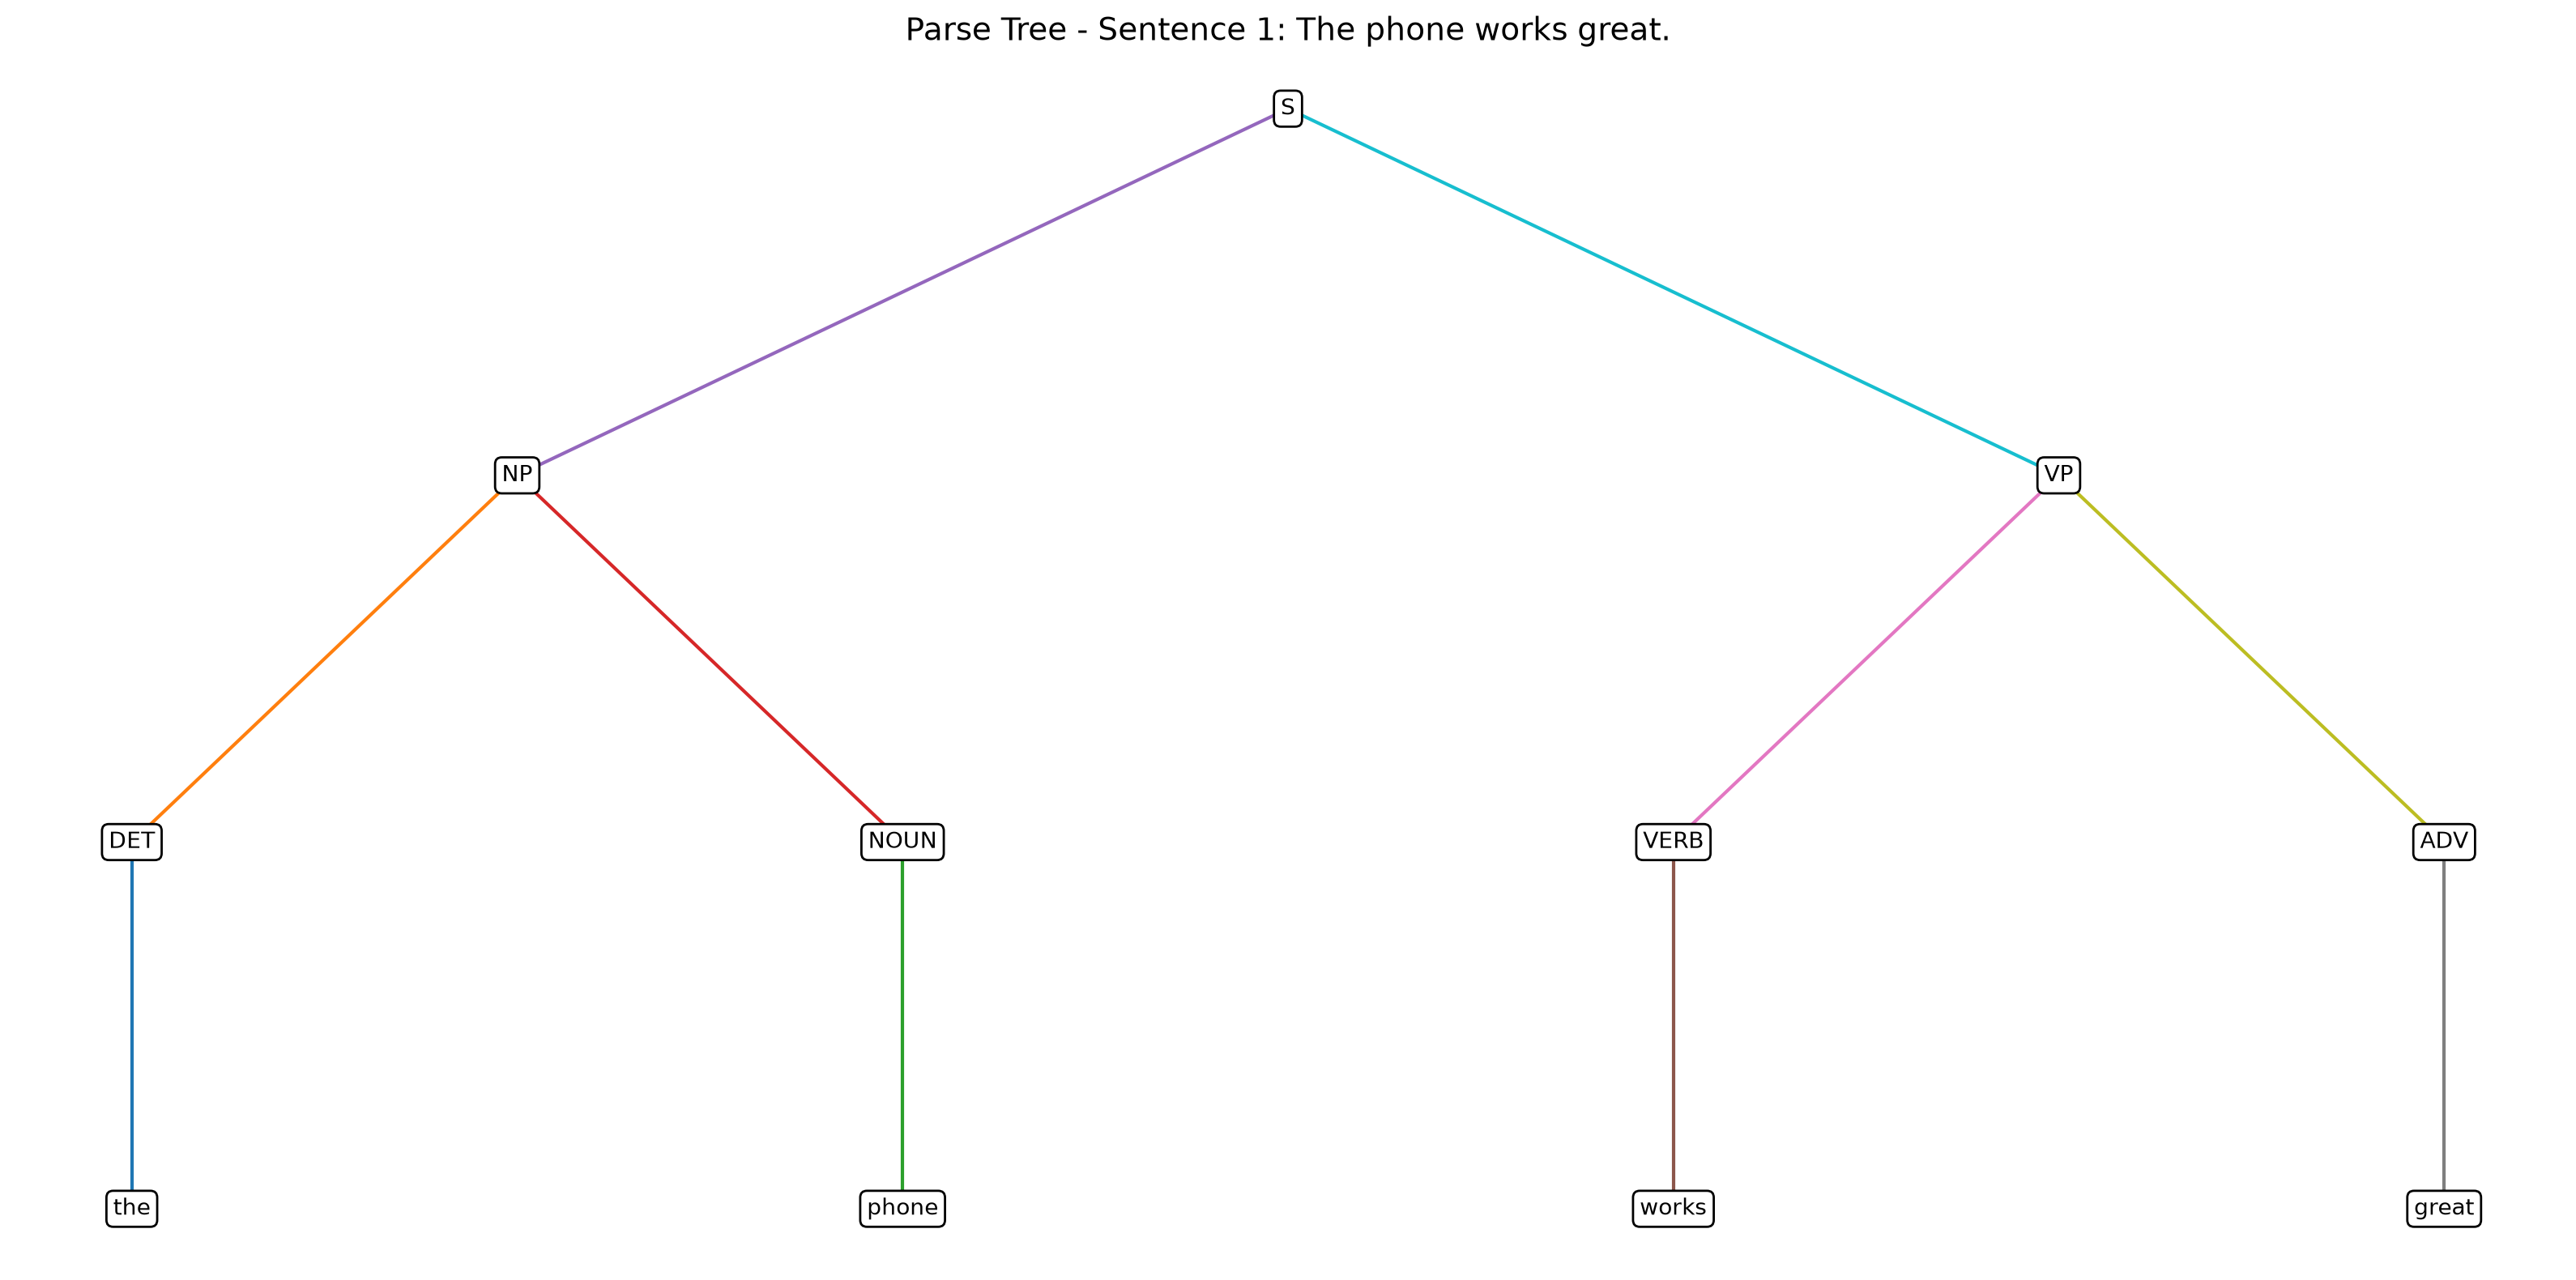


Sentence 2:
The memory card works perfectly.


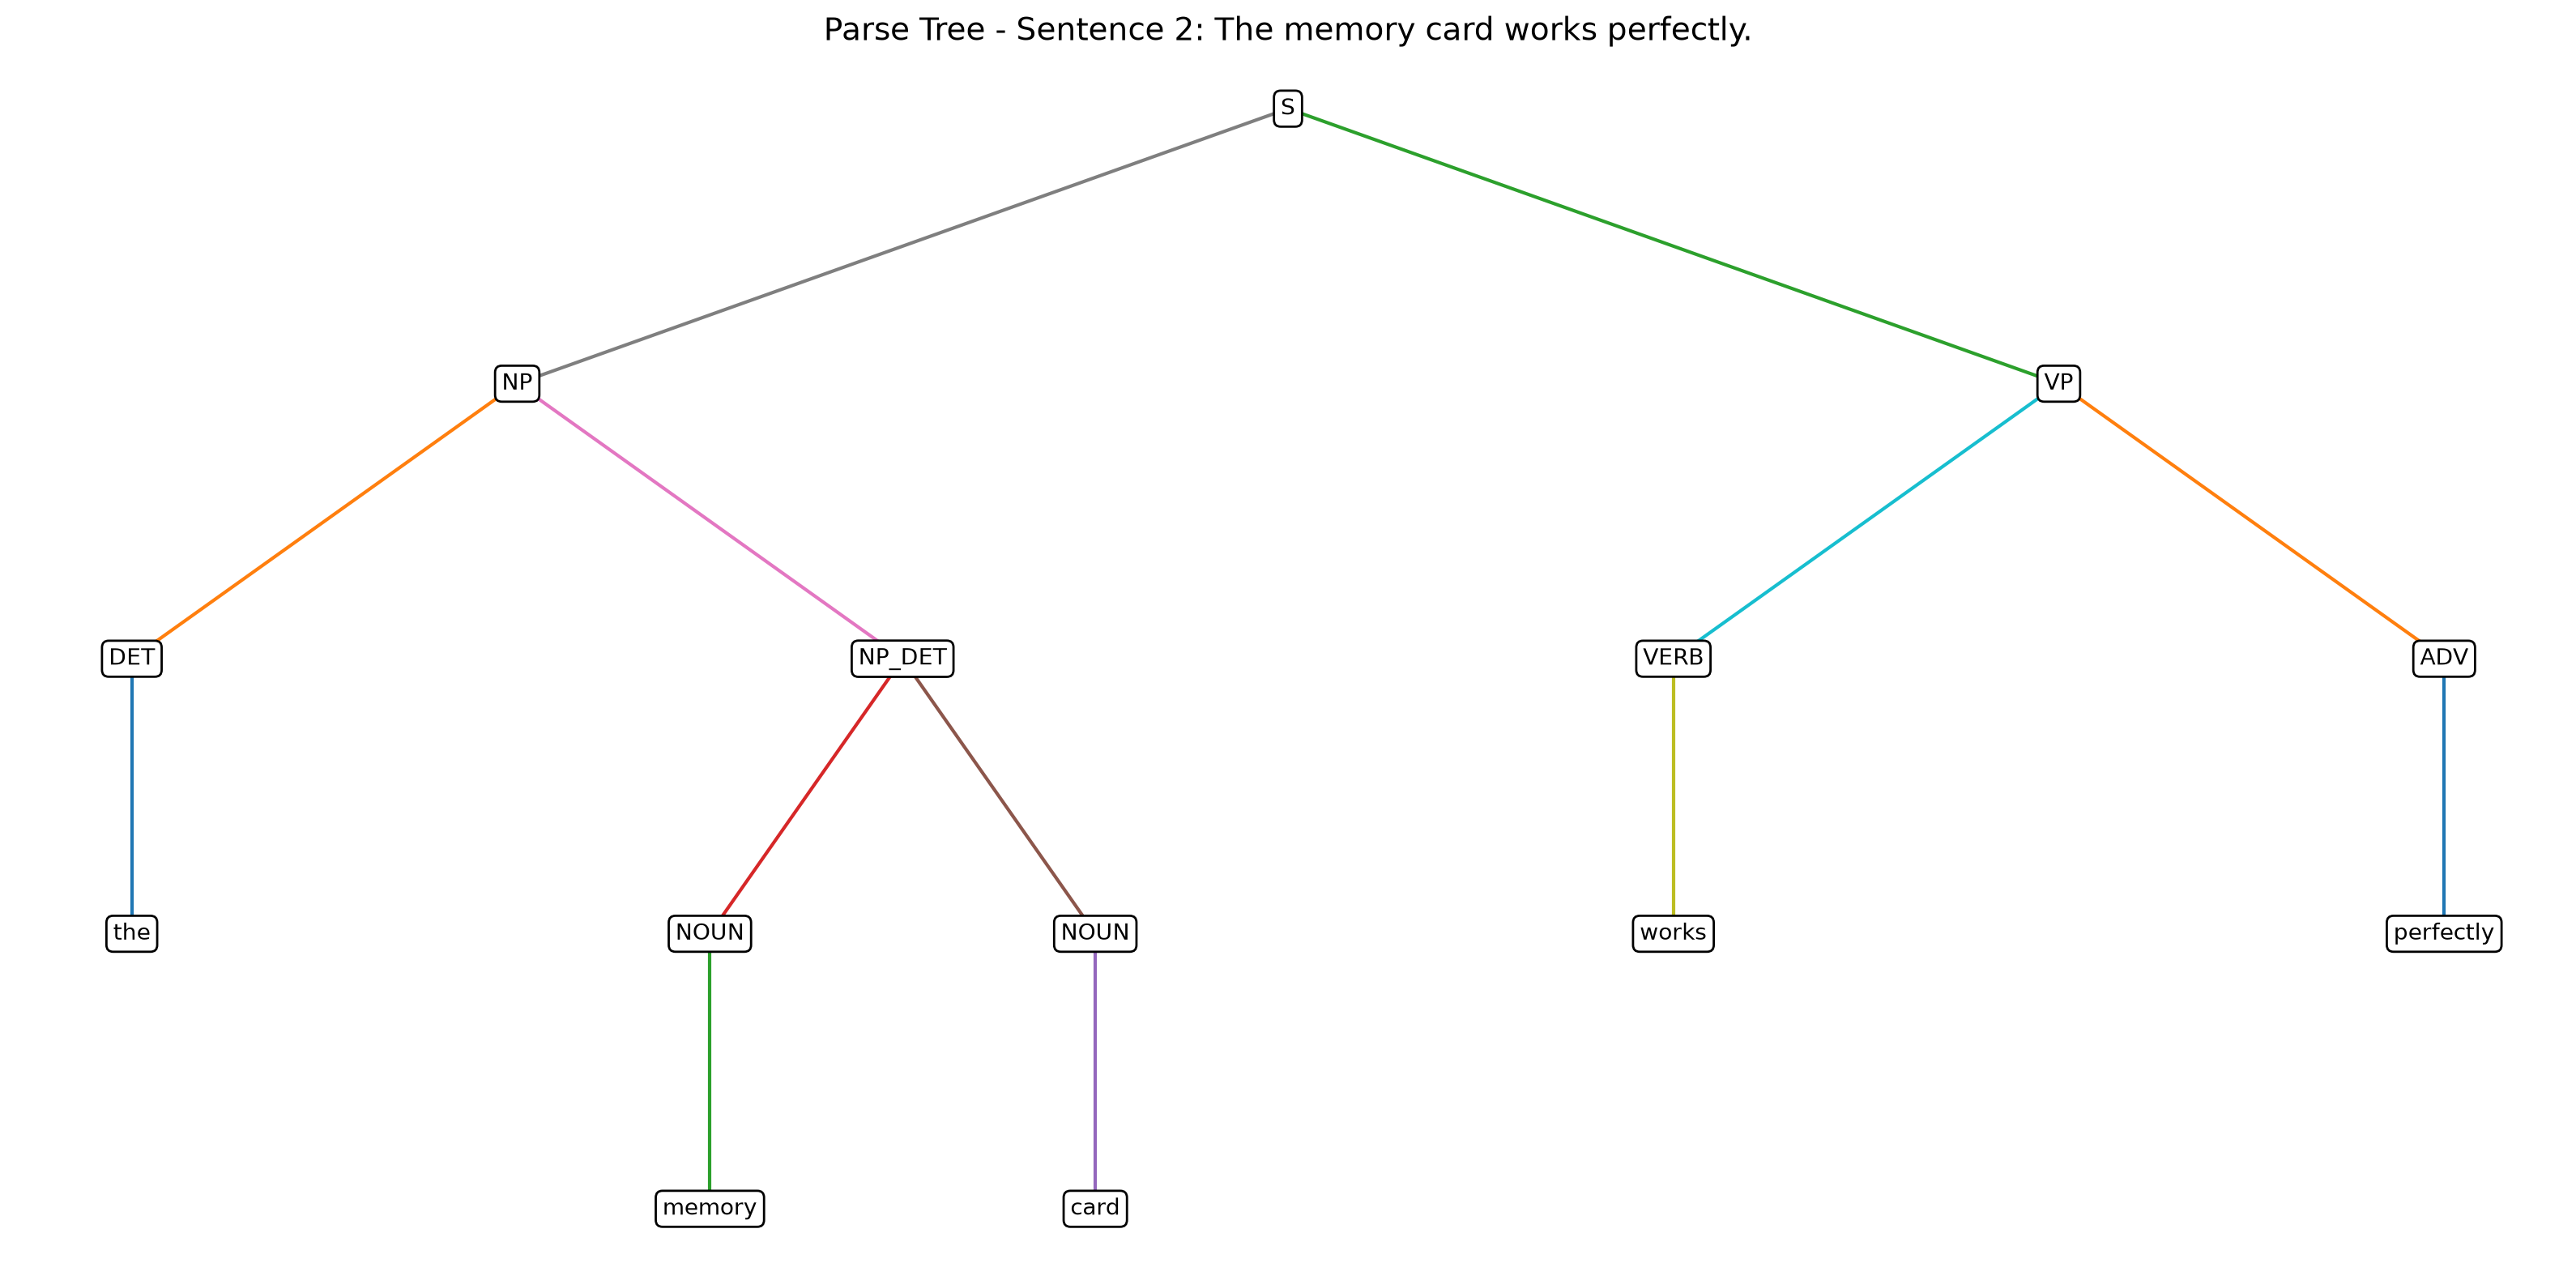


Sentence 3:
I bought a new phone.


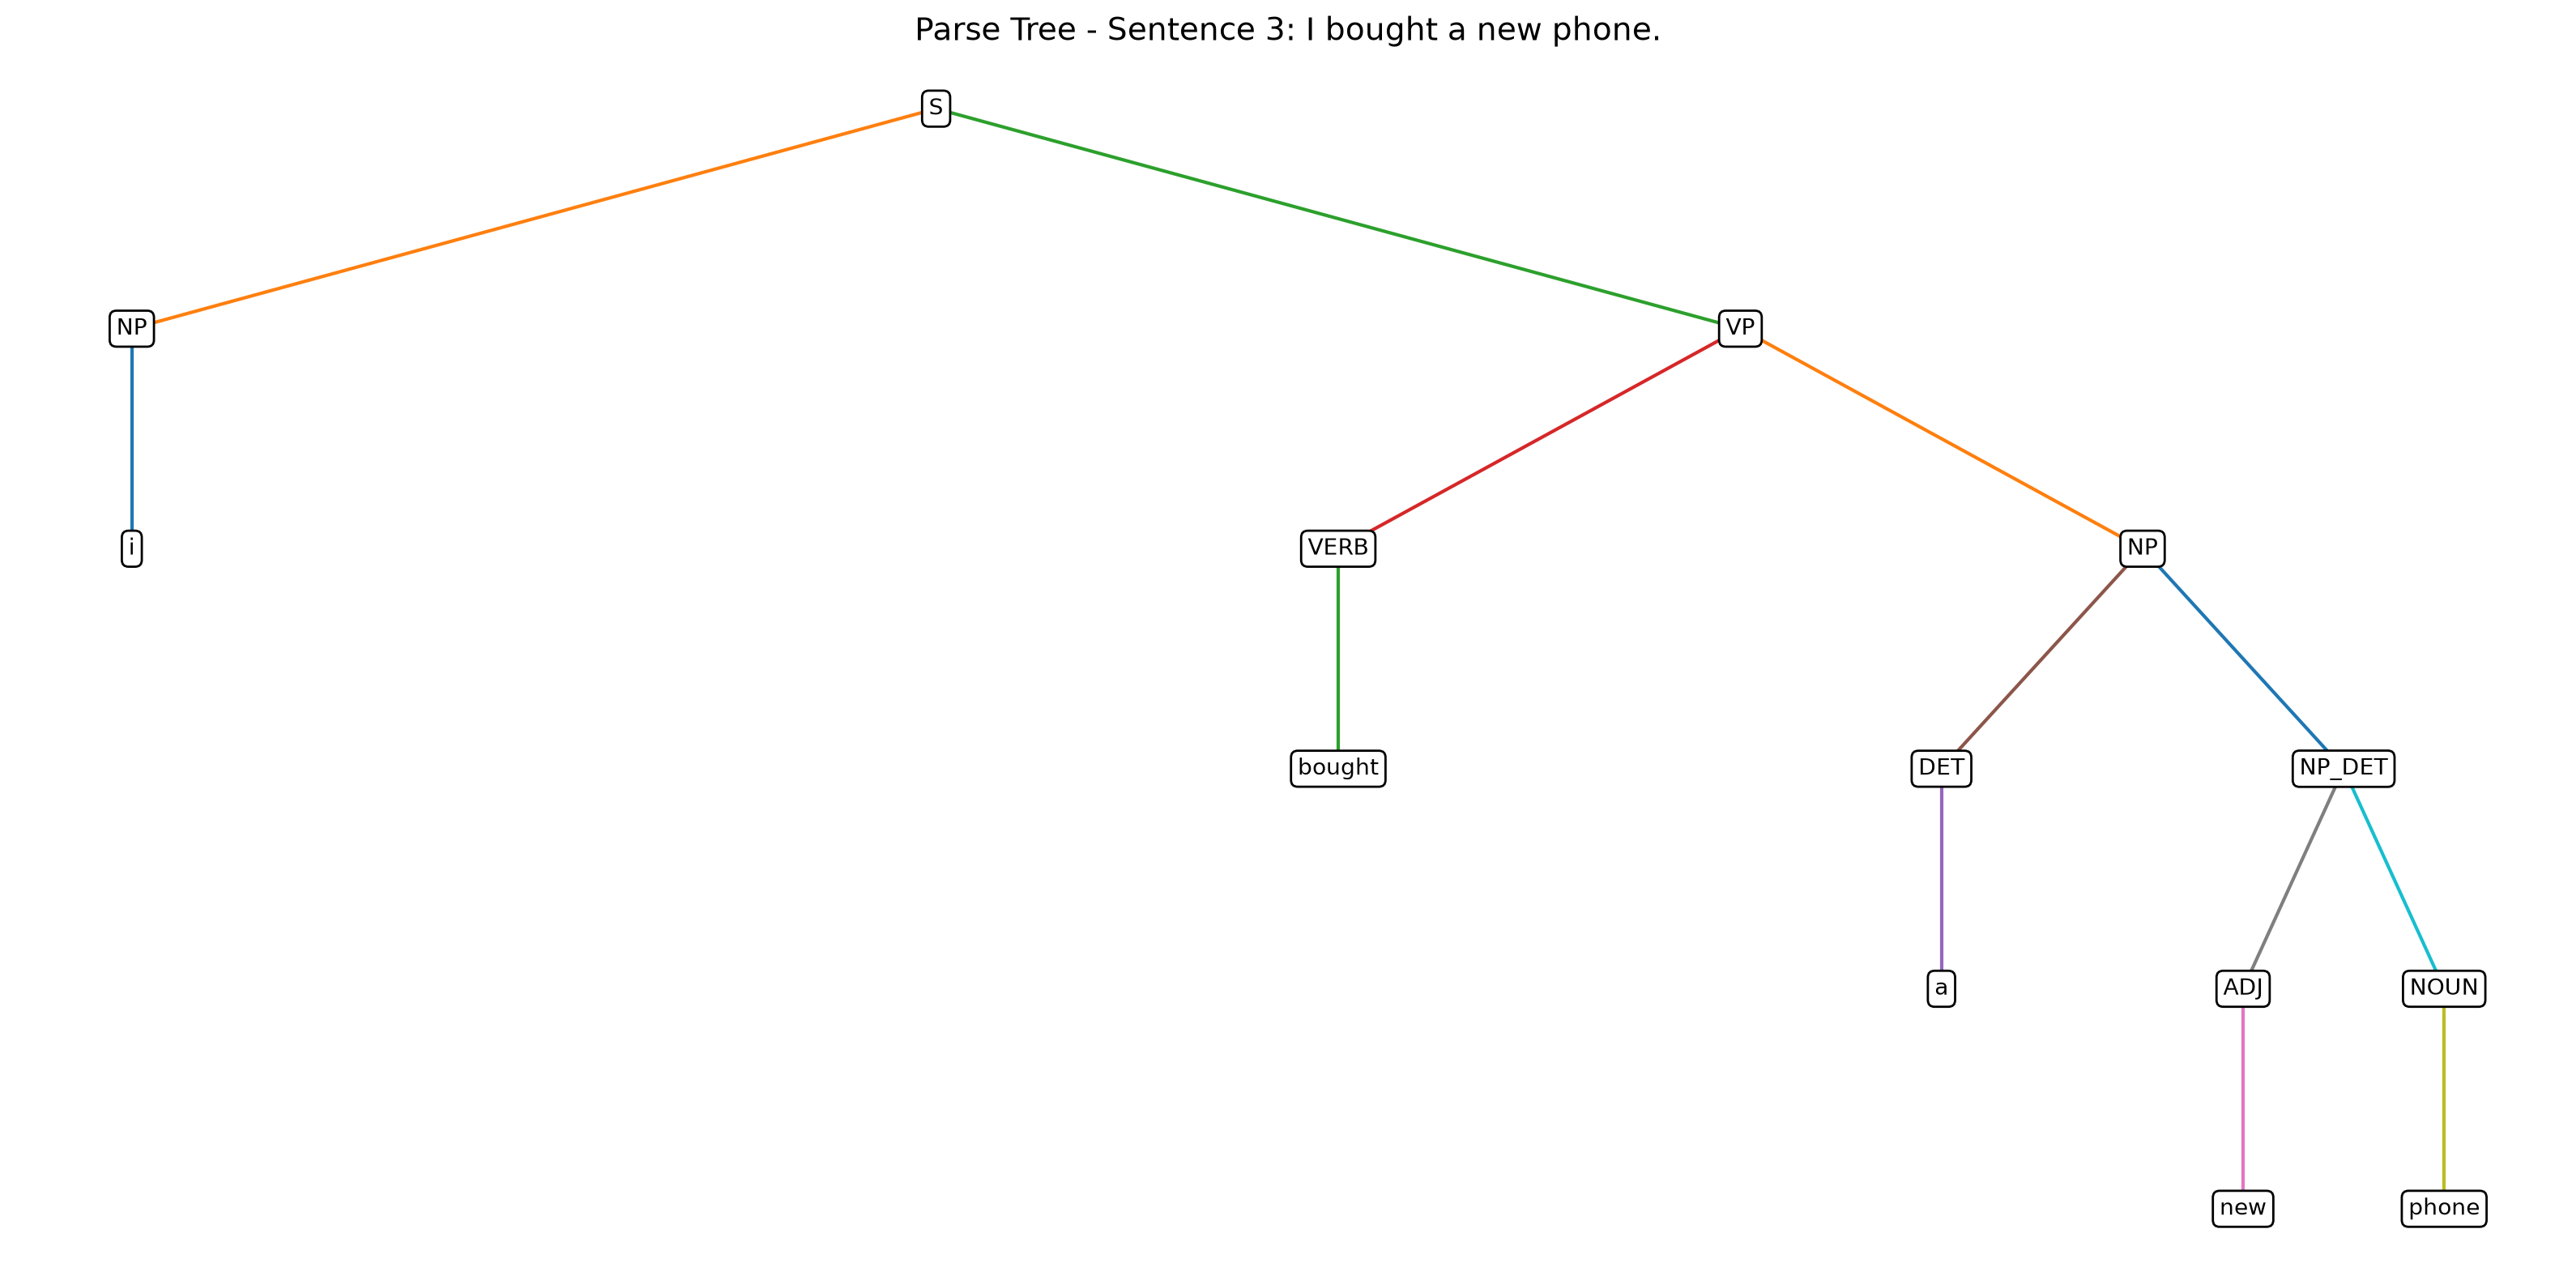


Sentence 4:
The card has good storage.


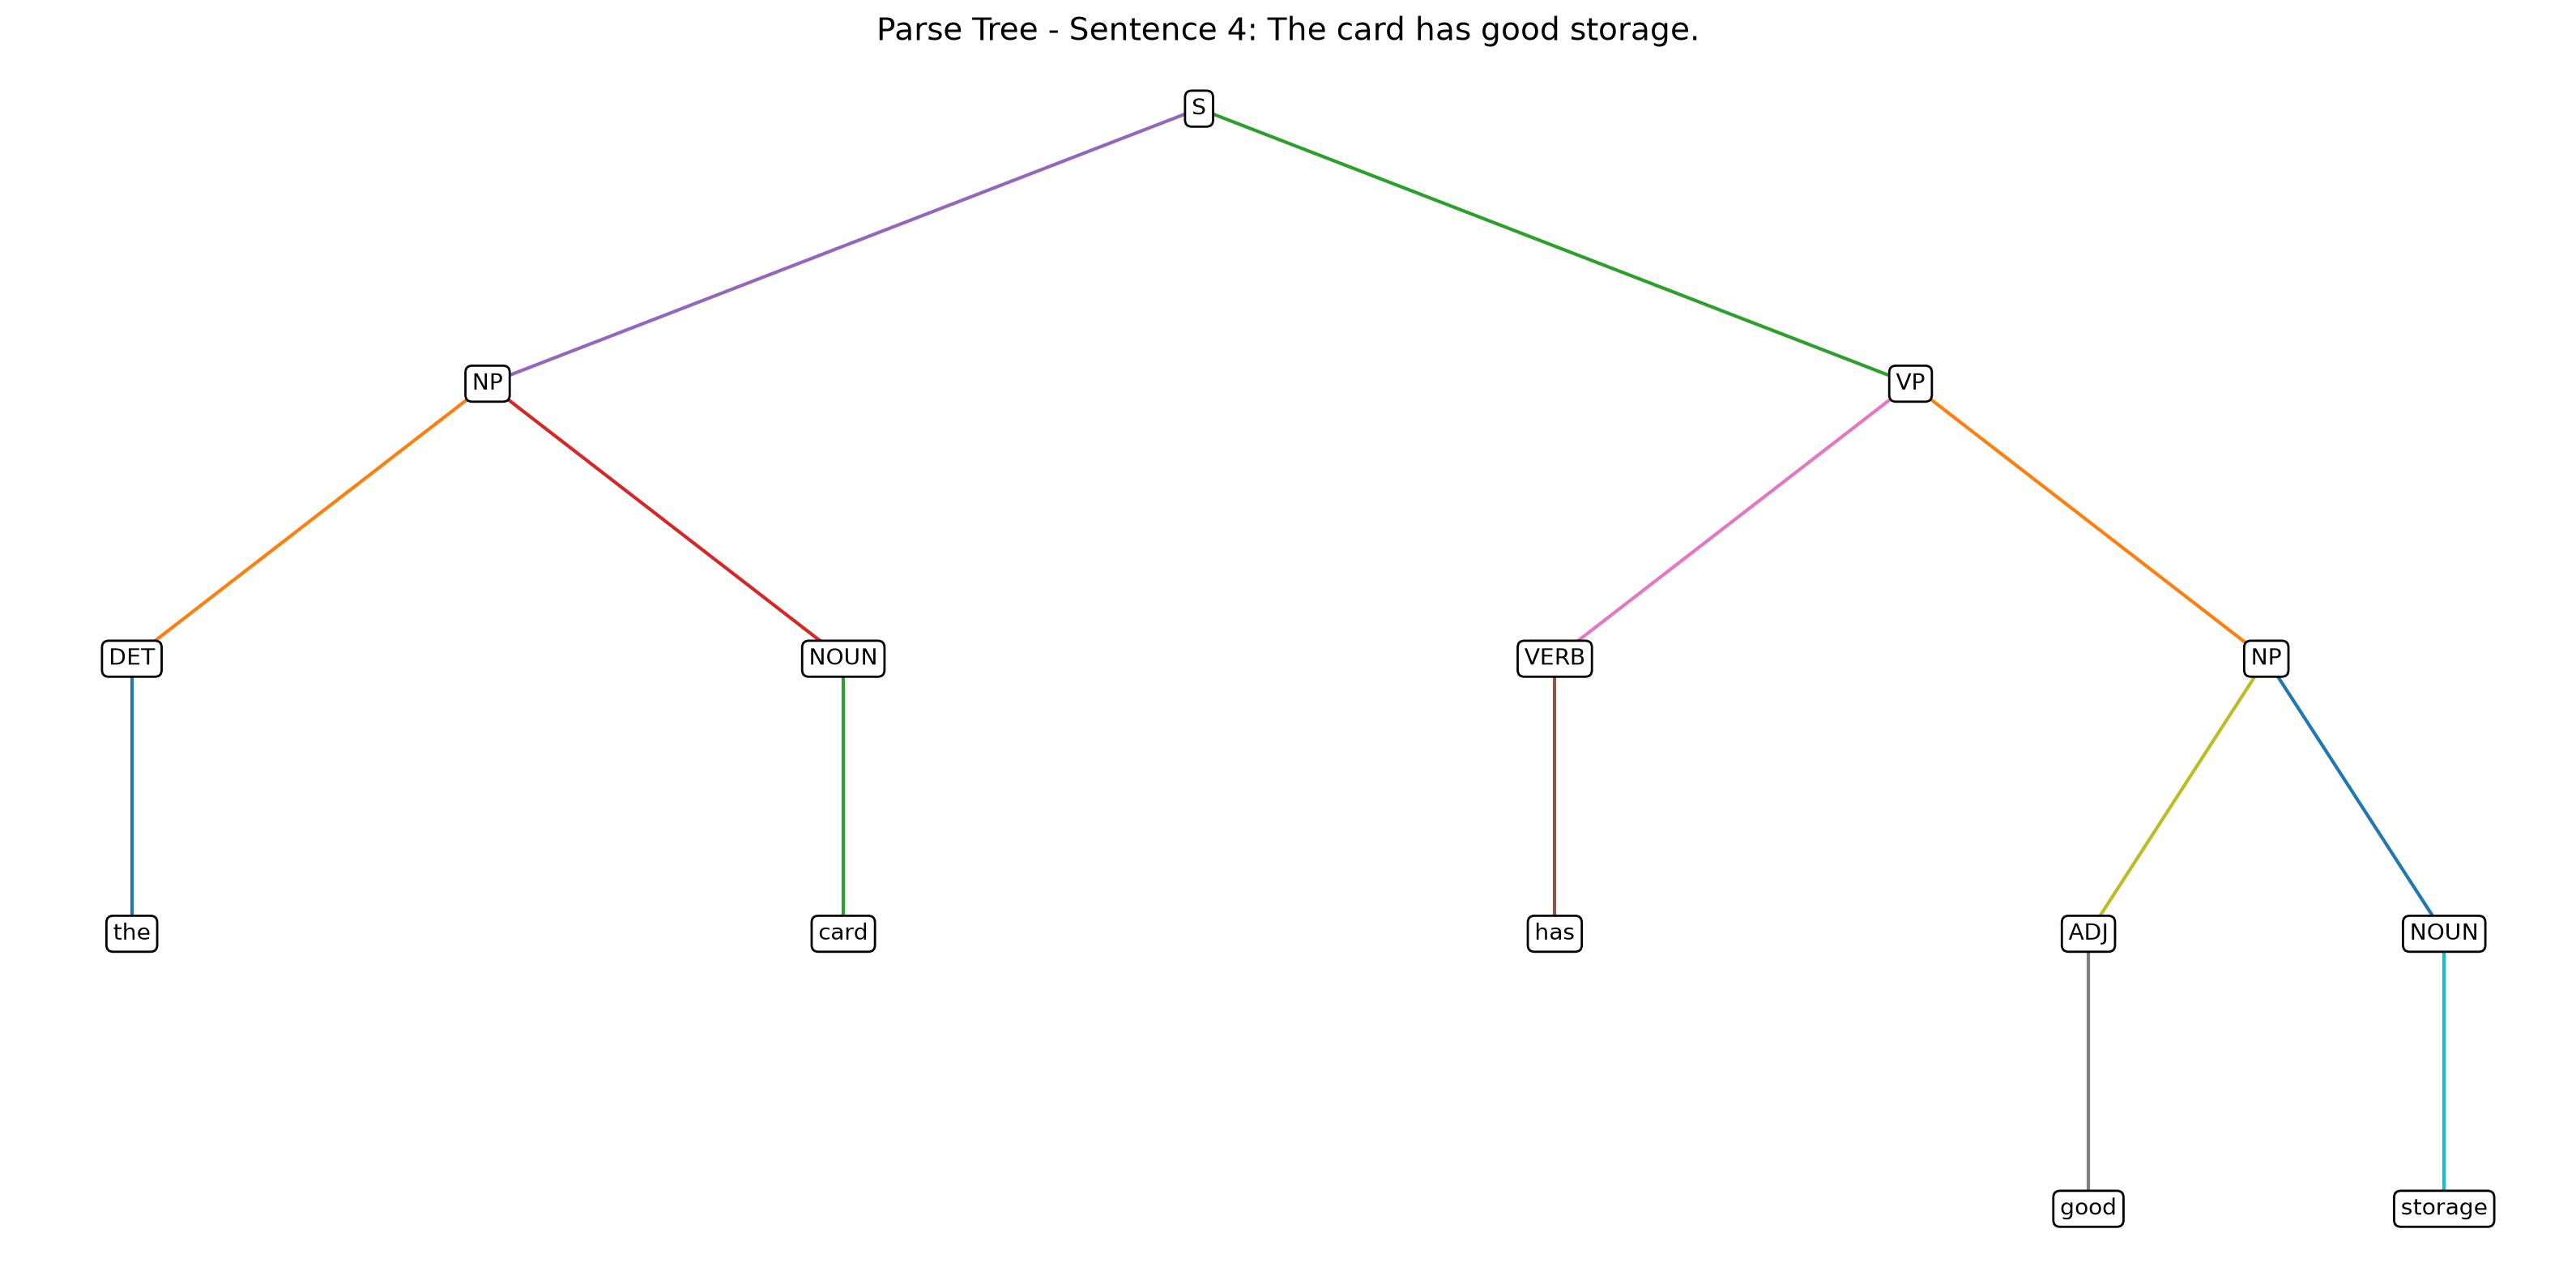


Sentence 5:
The phone takes great pictures.


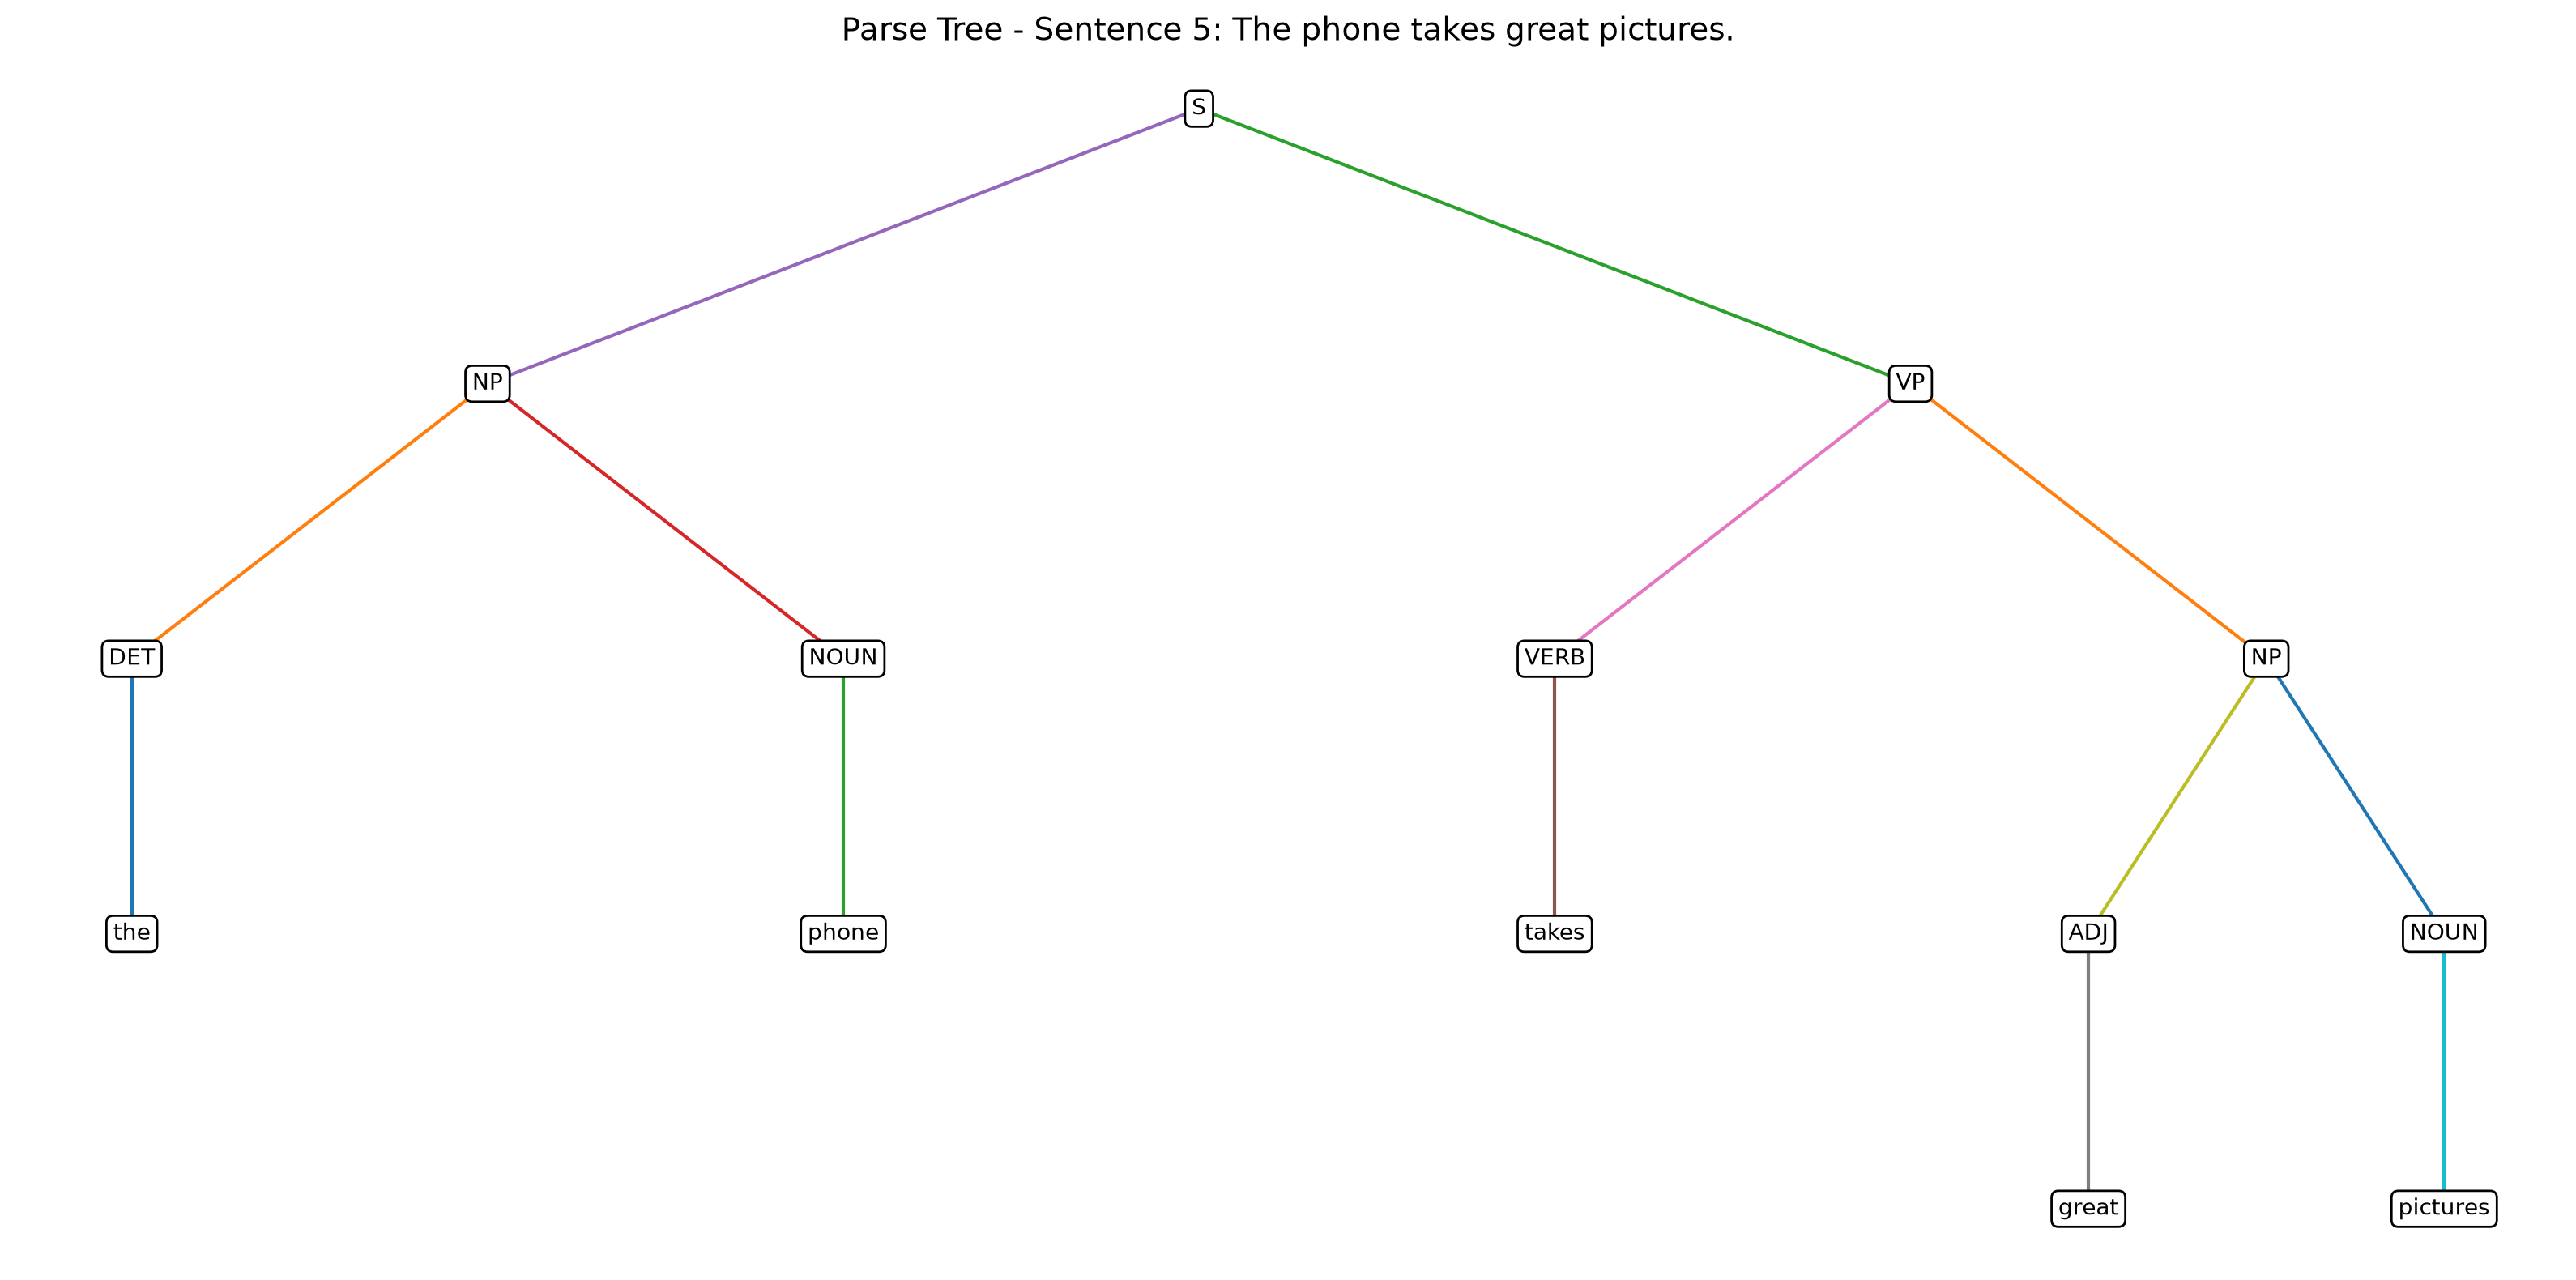


Sentence 6:
The memory card is fast.


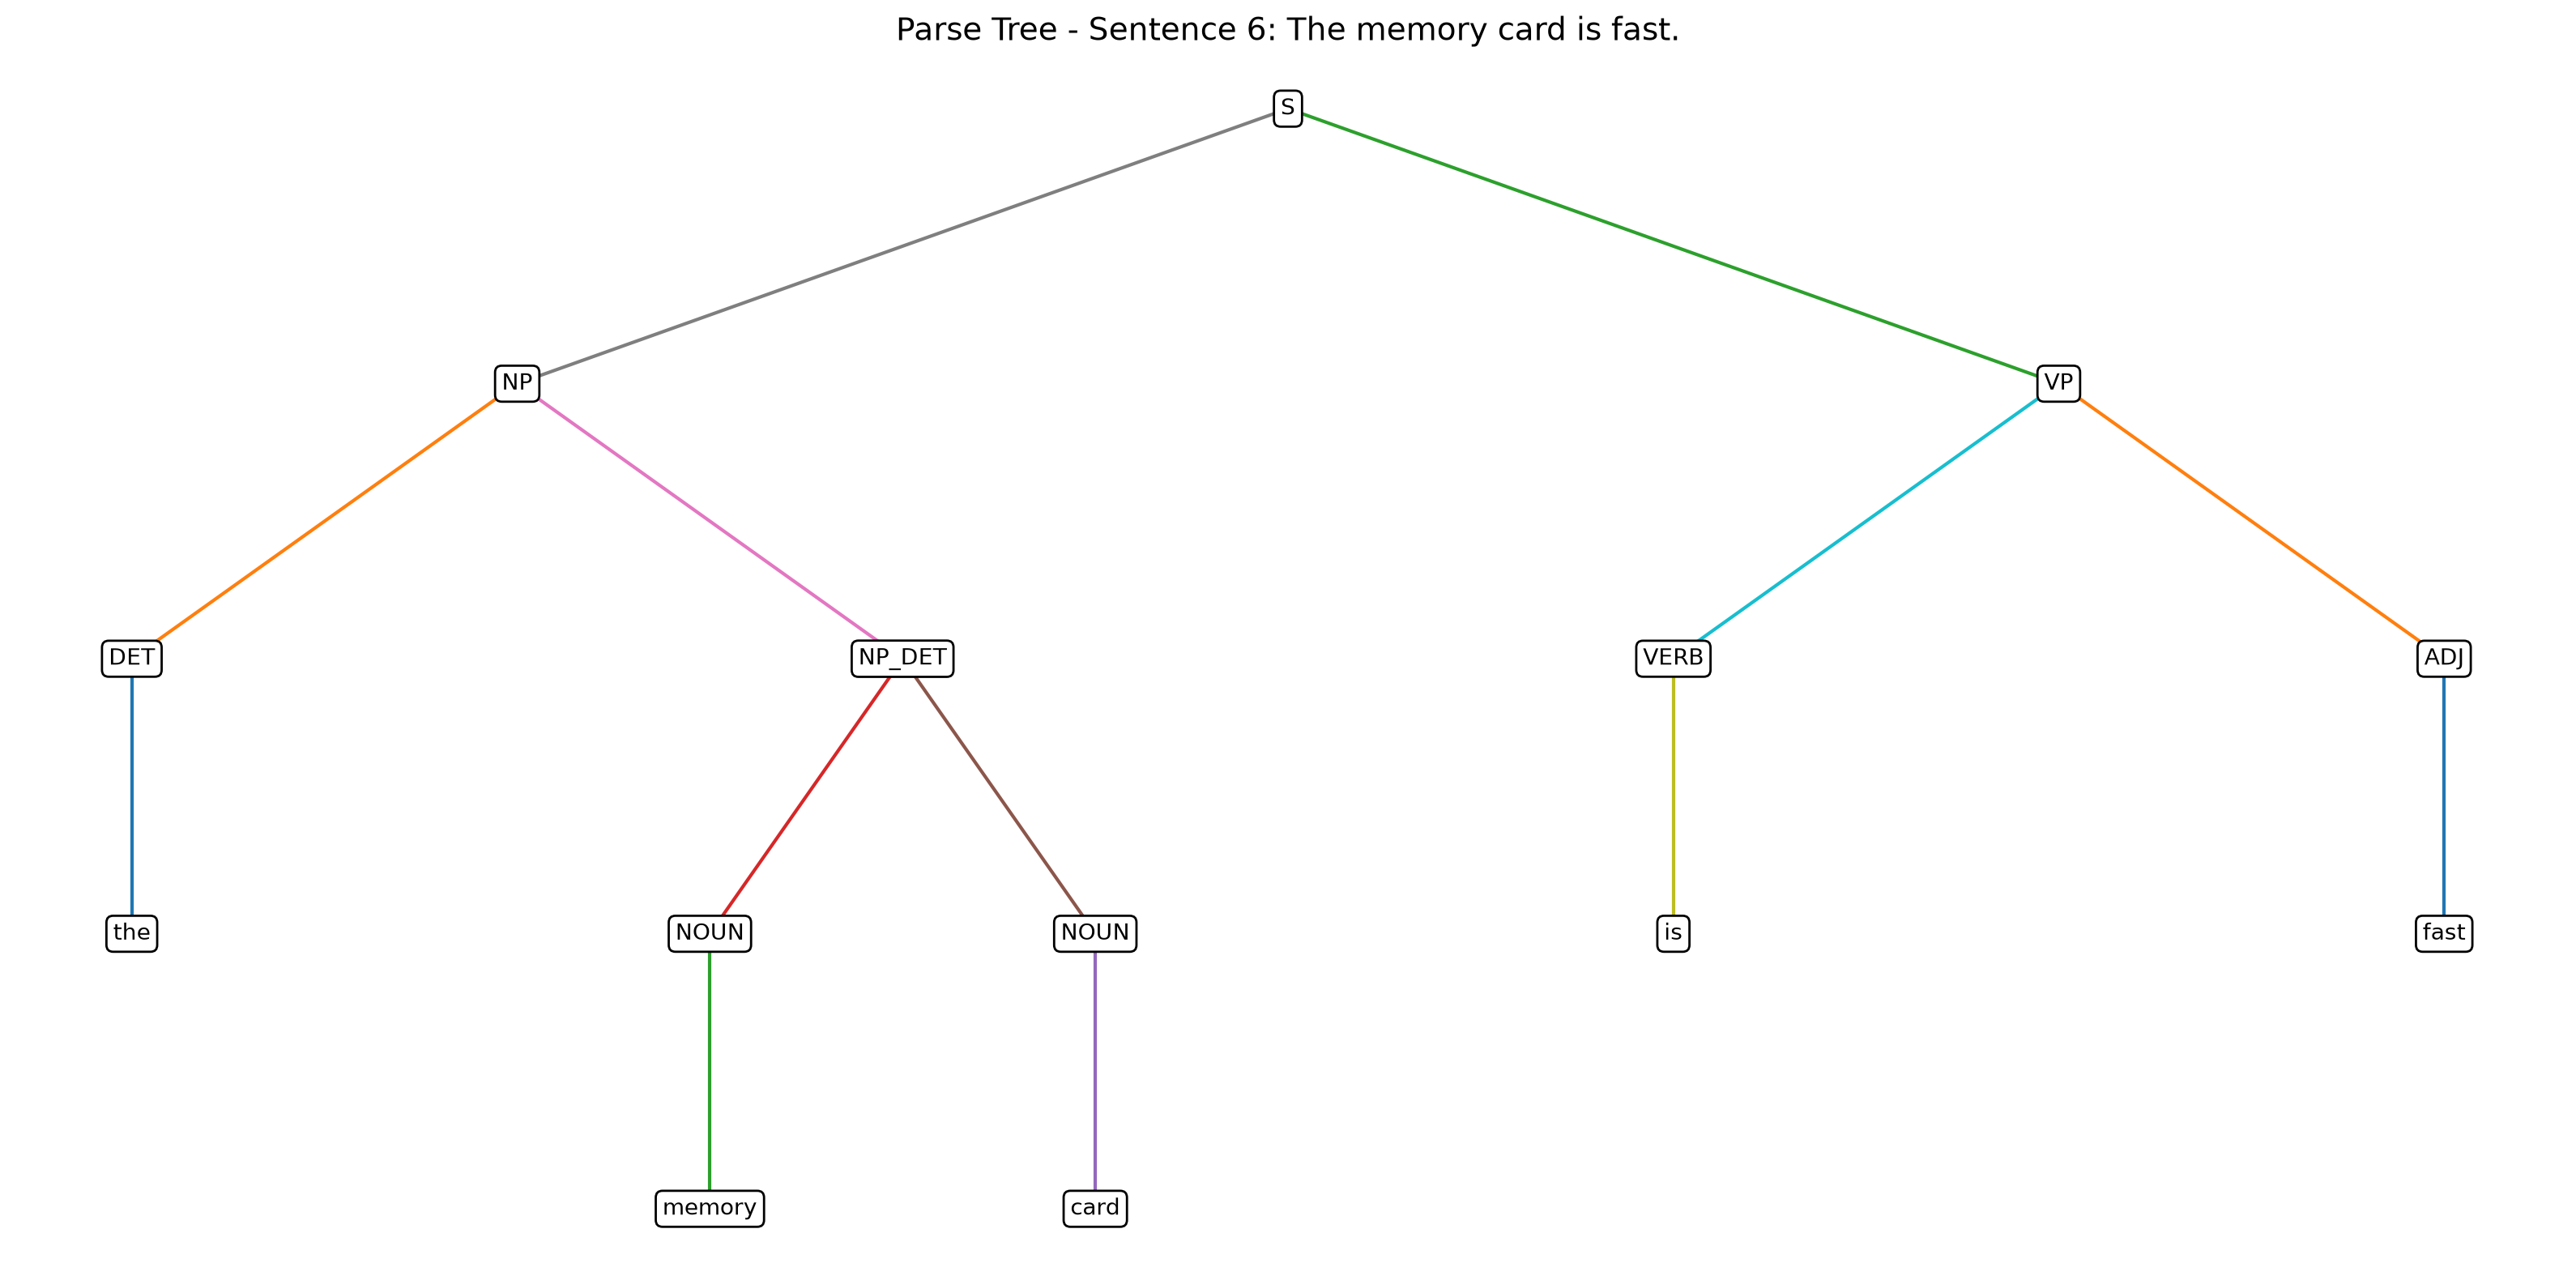


Sentence 7:
I use the card every day.


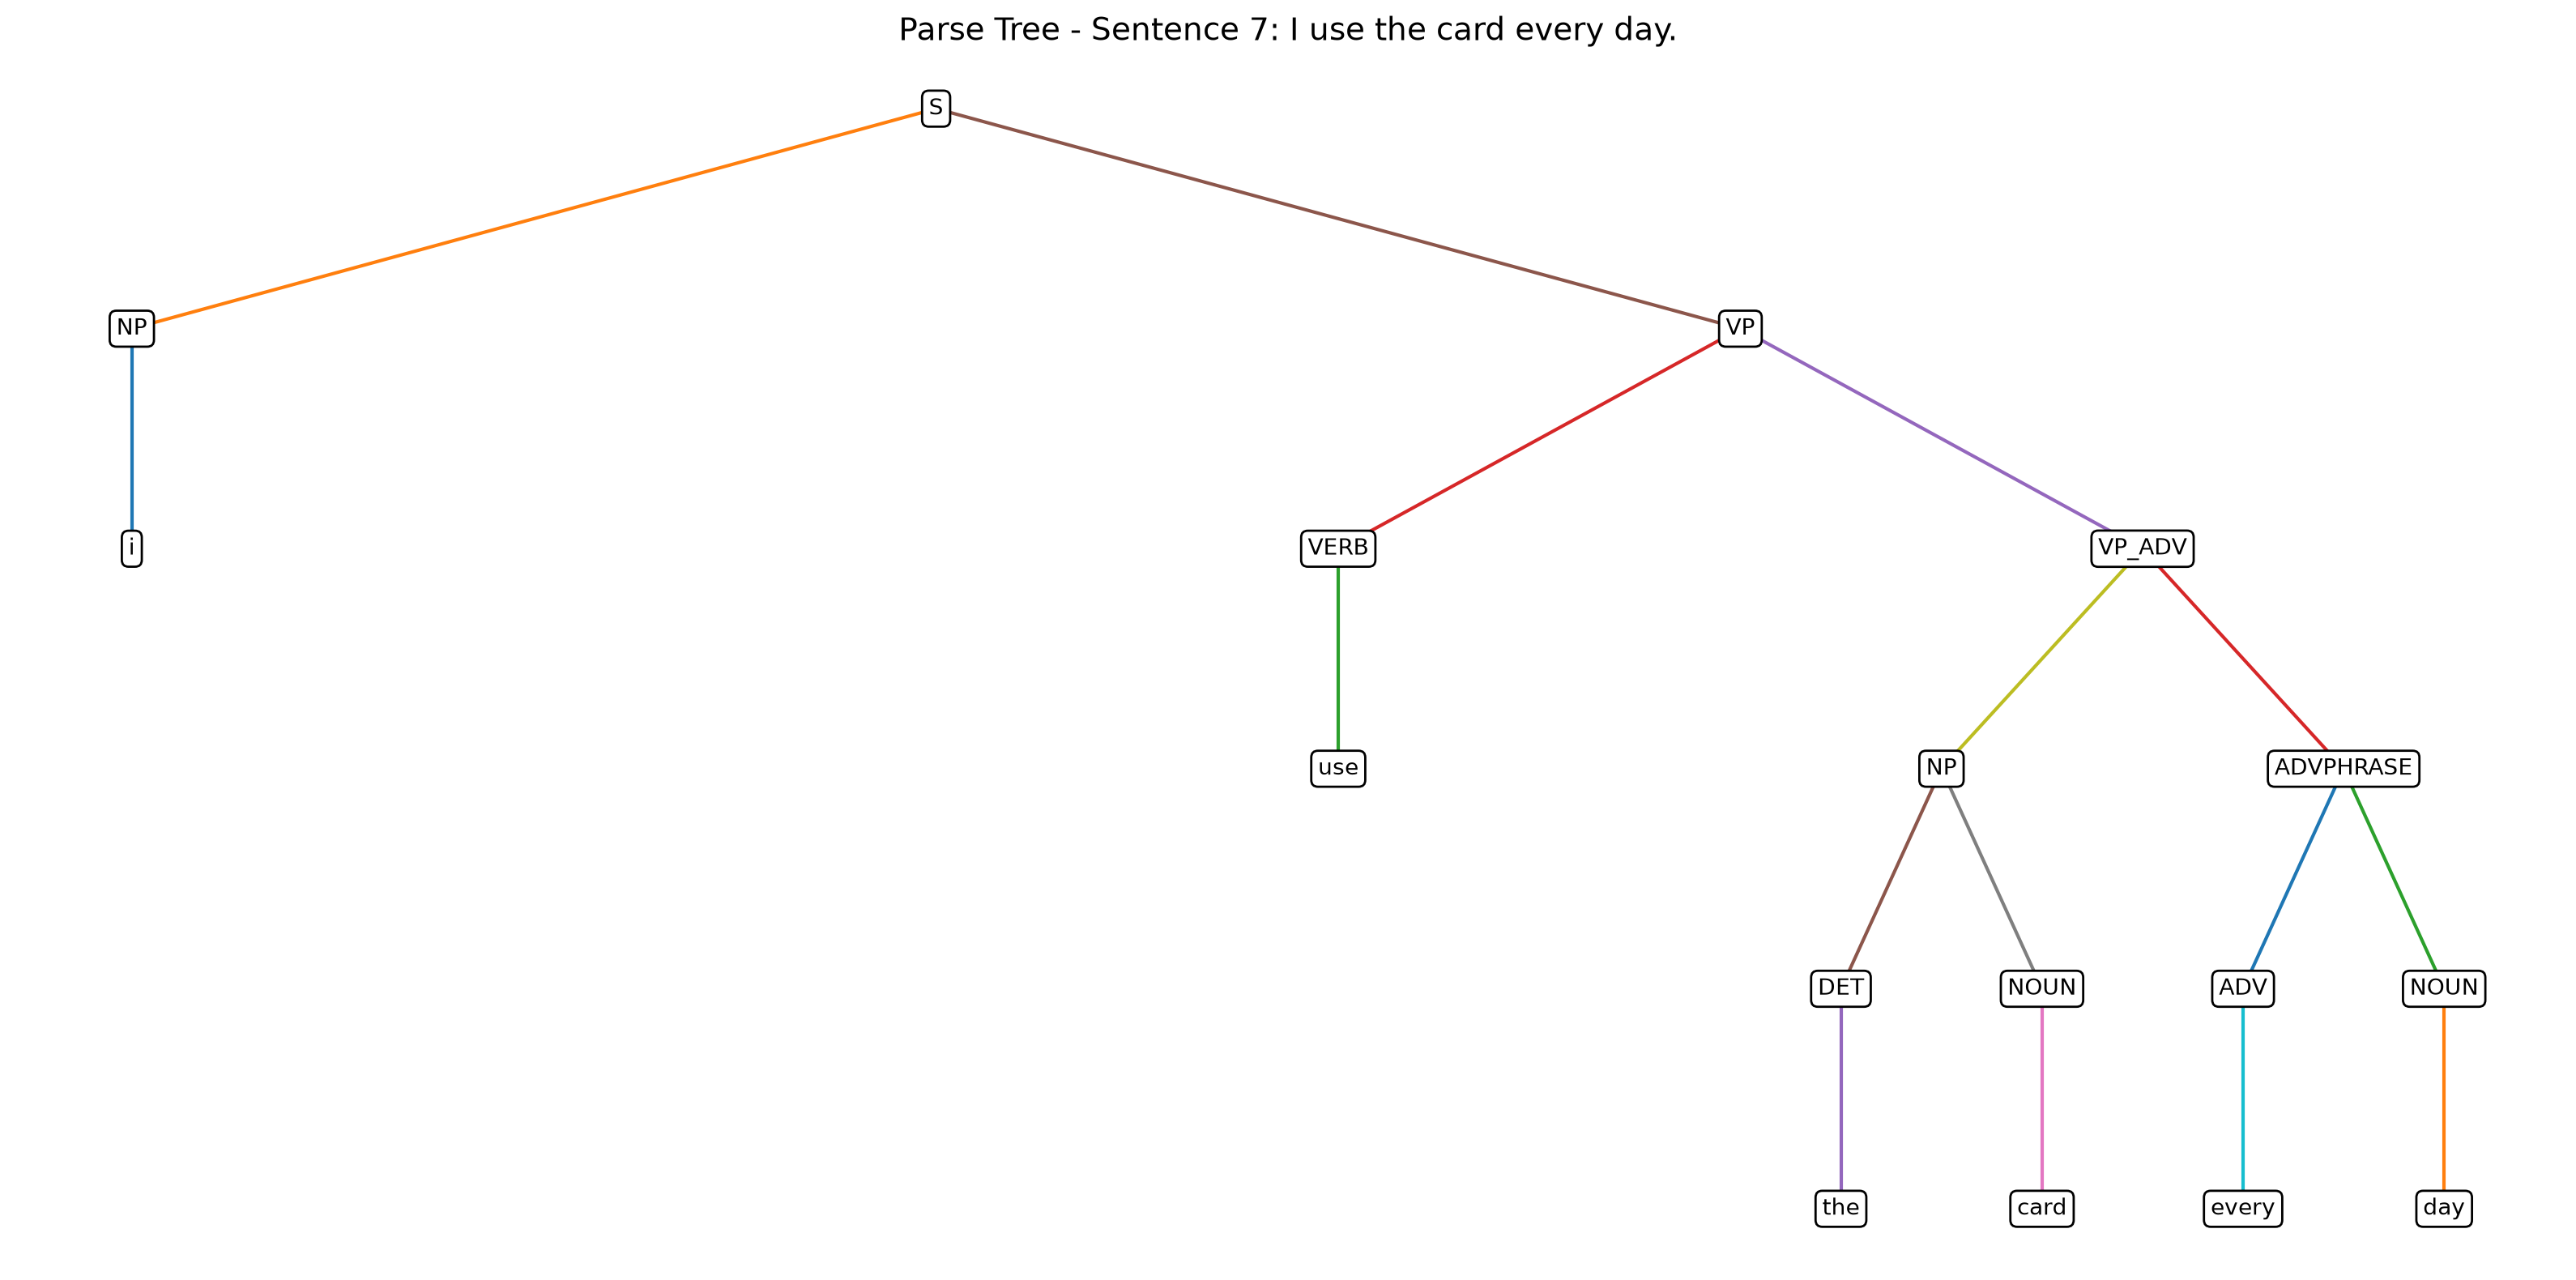


Sentence 8:
The new phone has excellent battery life.


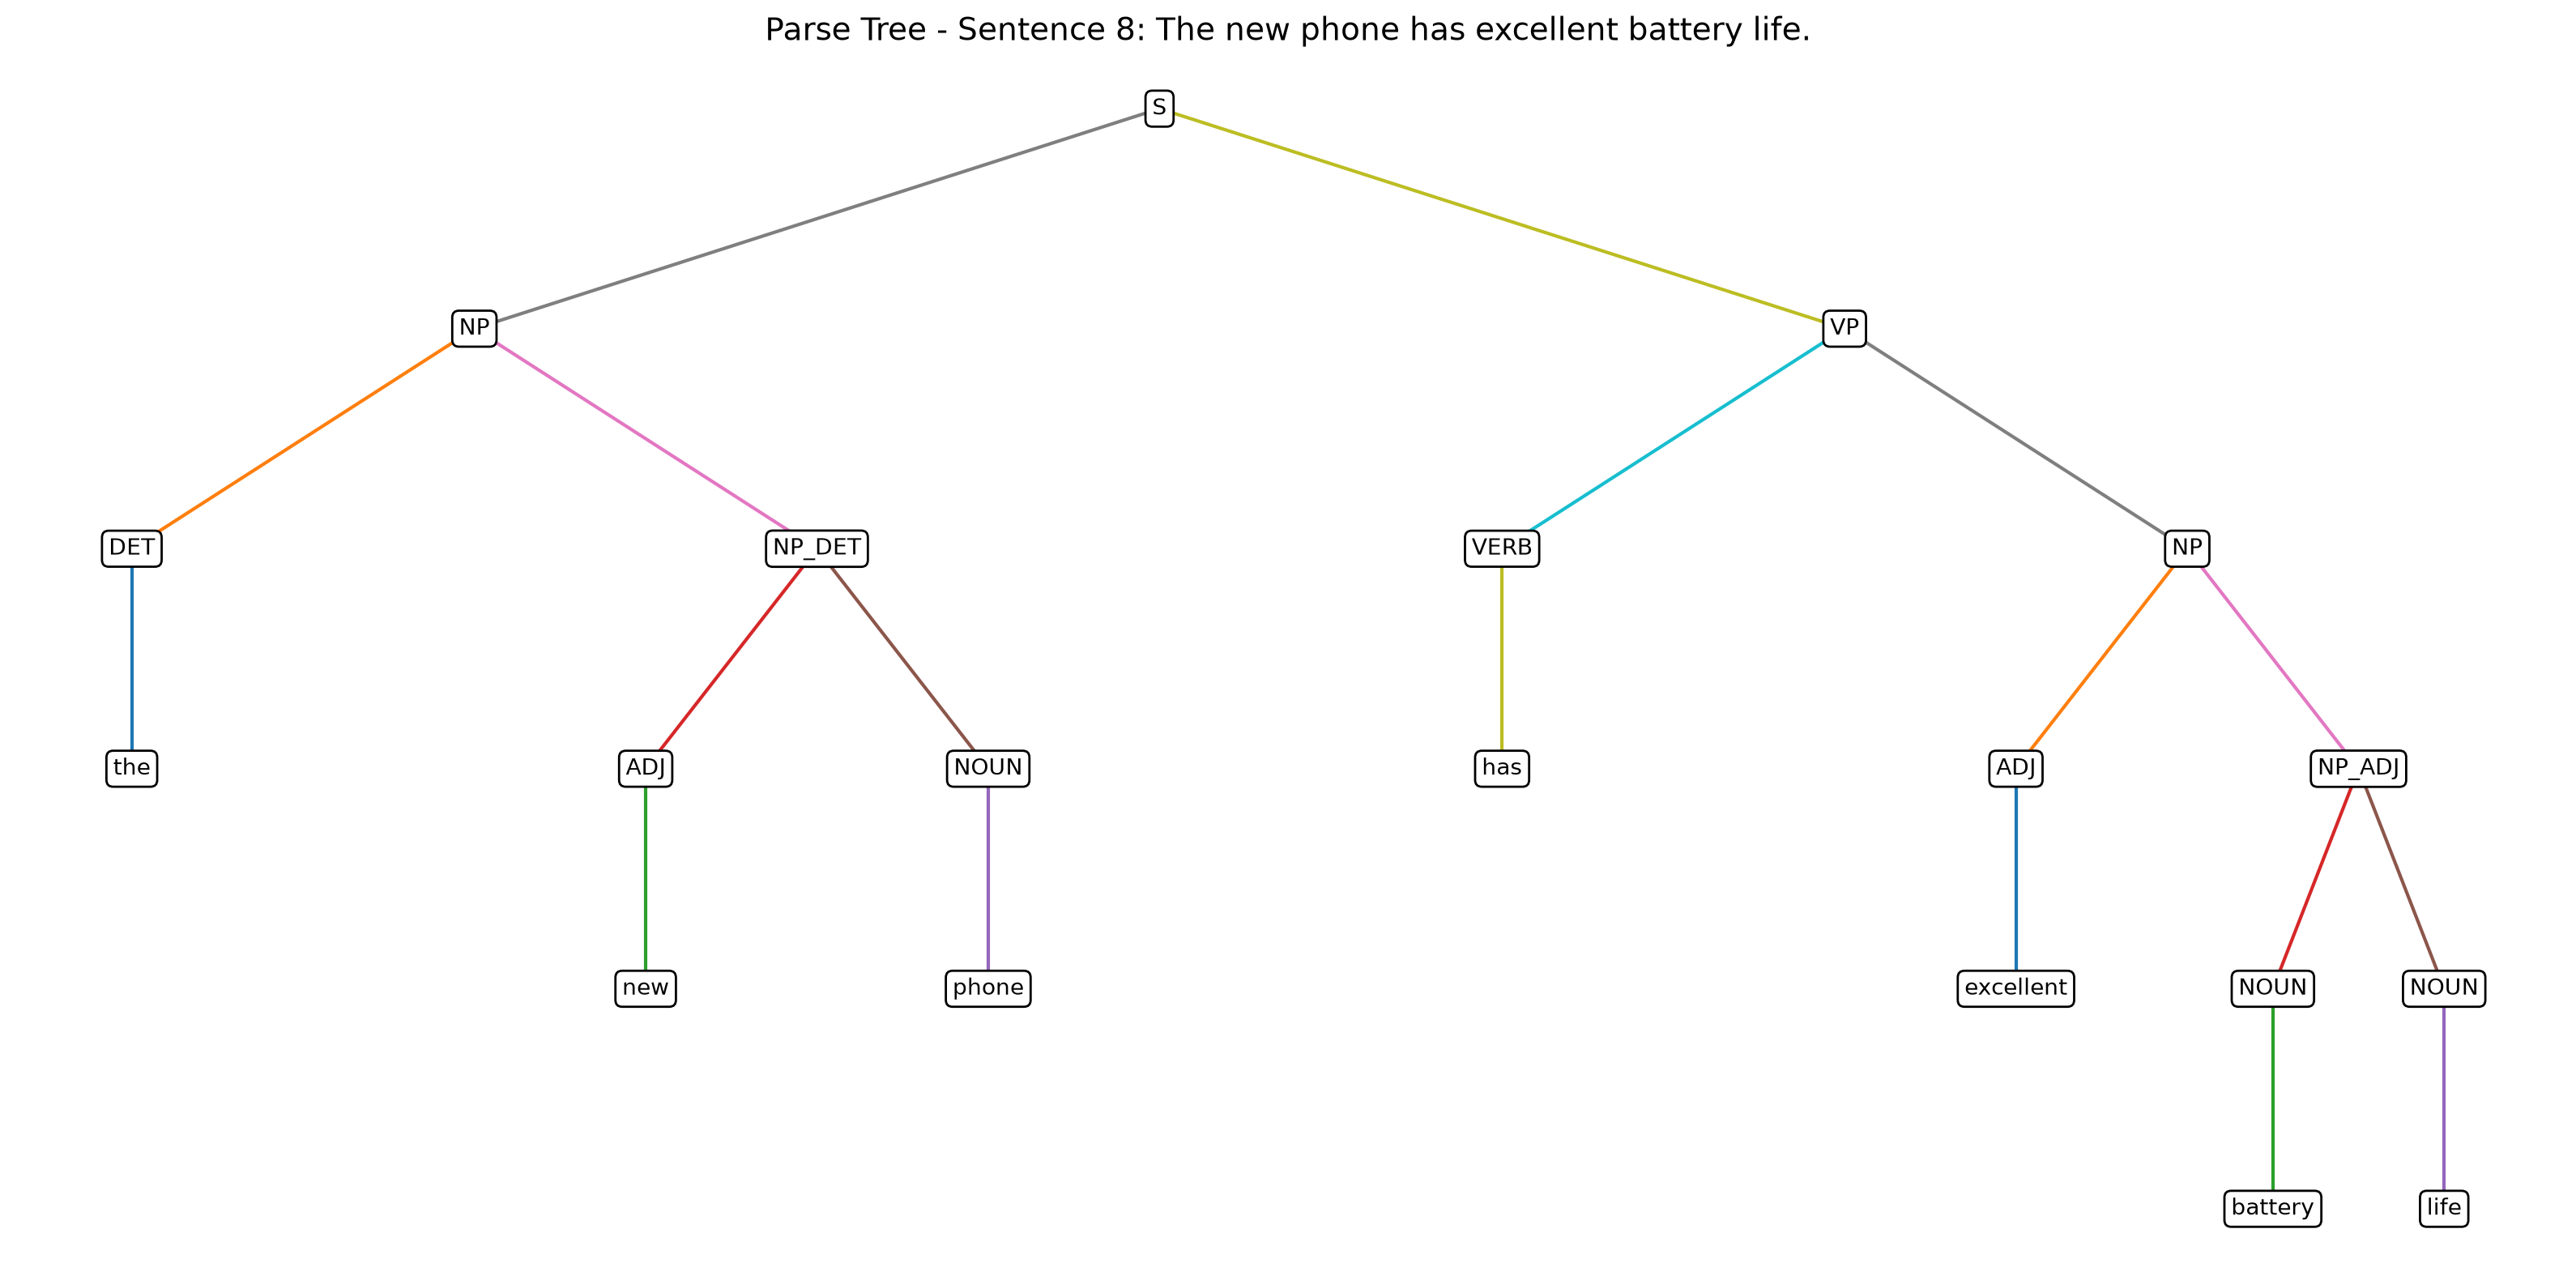


Sentence 9:
The card works with my phone.


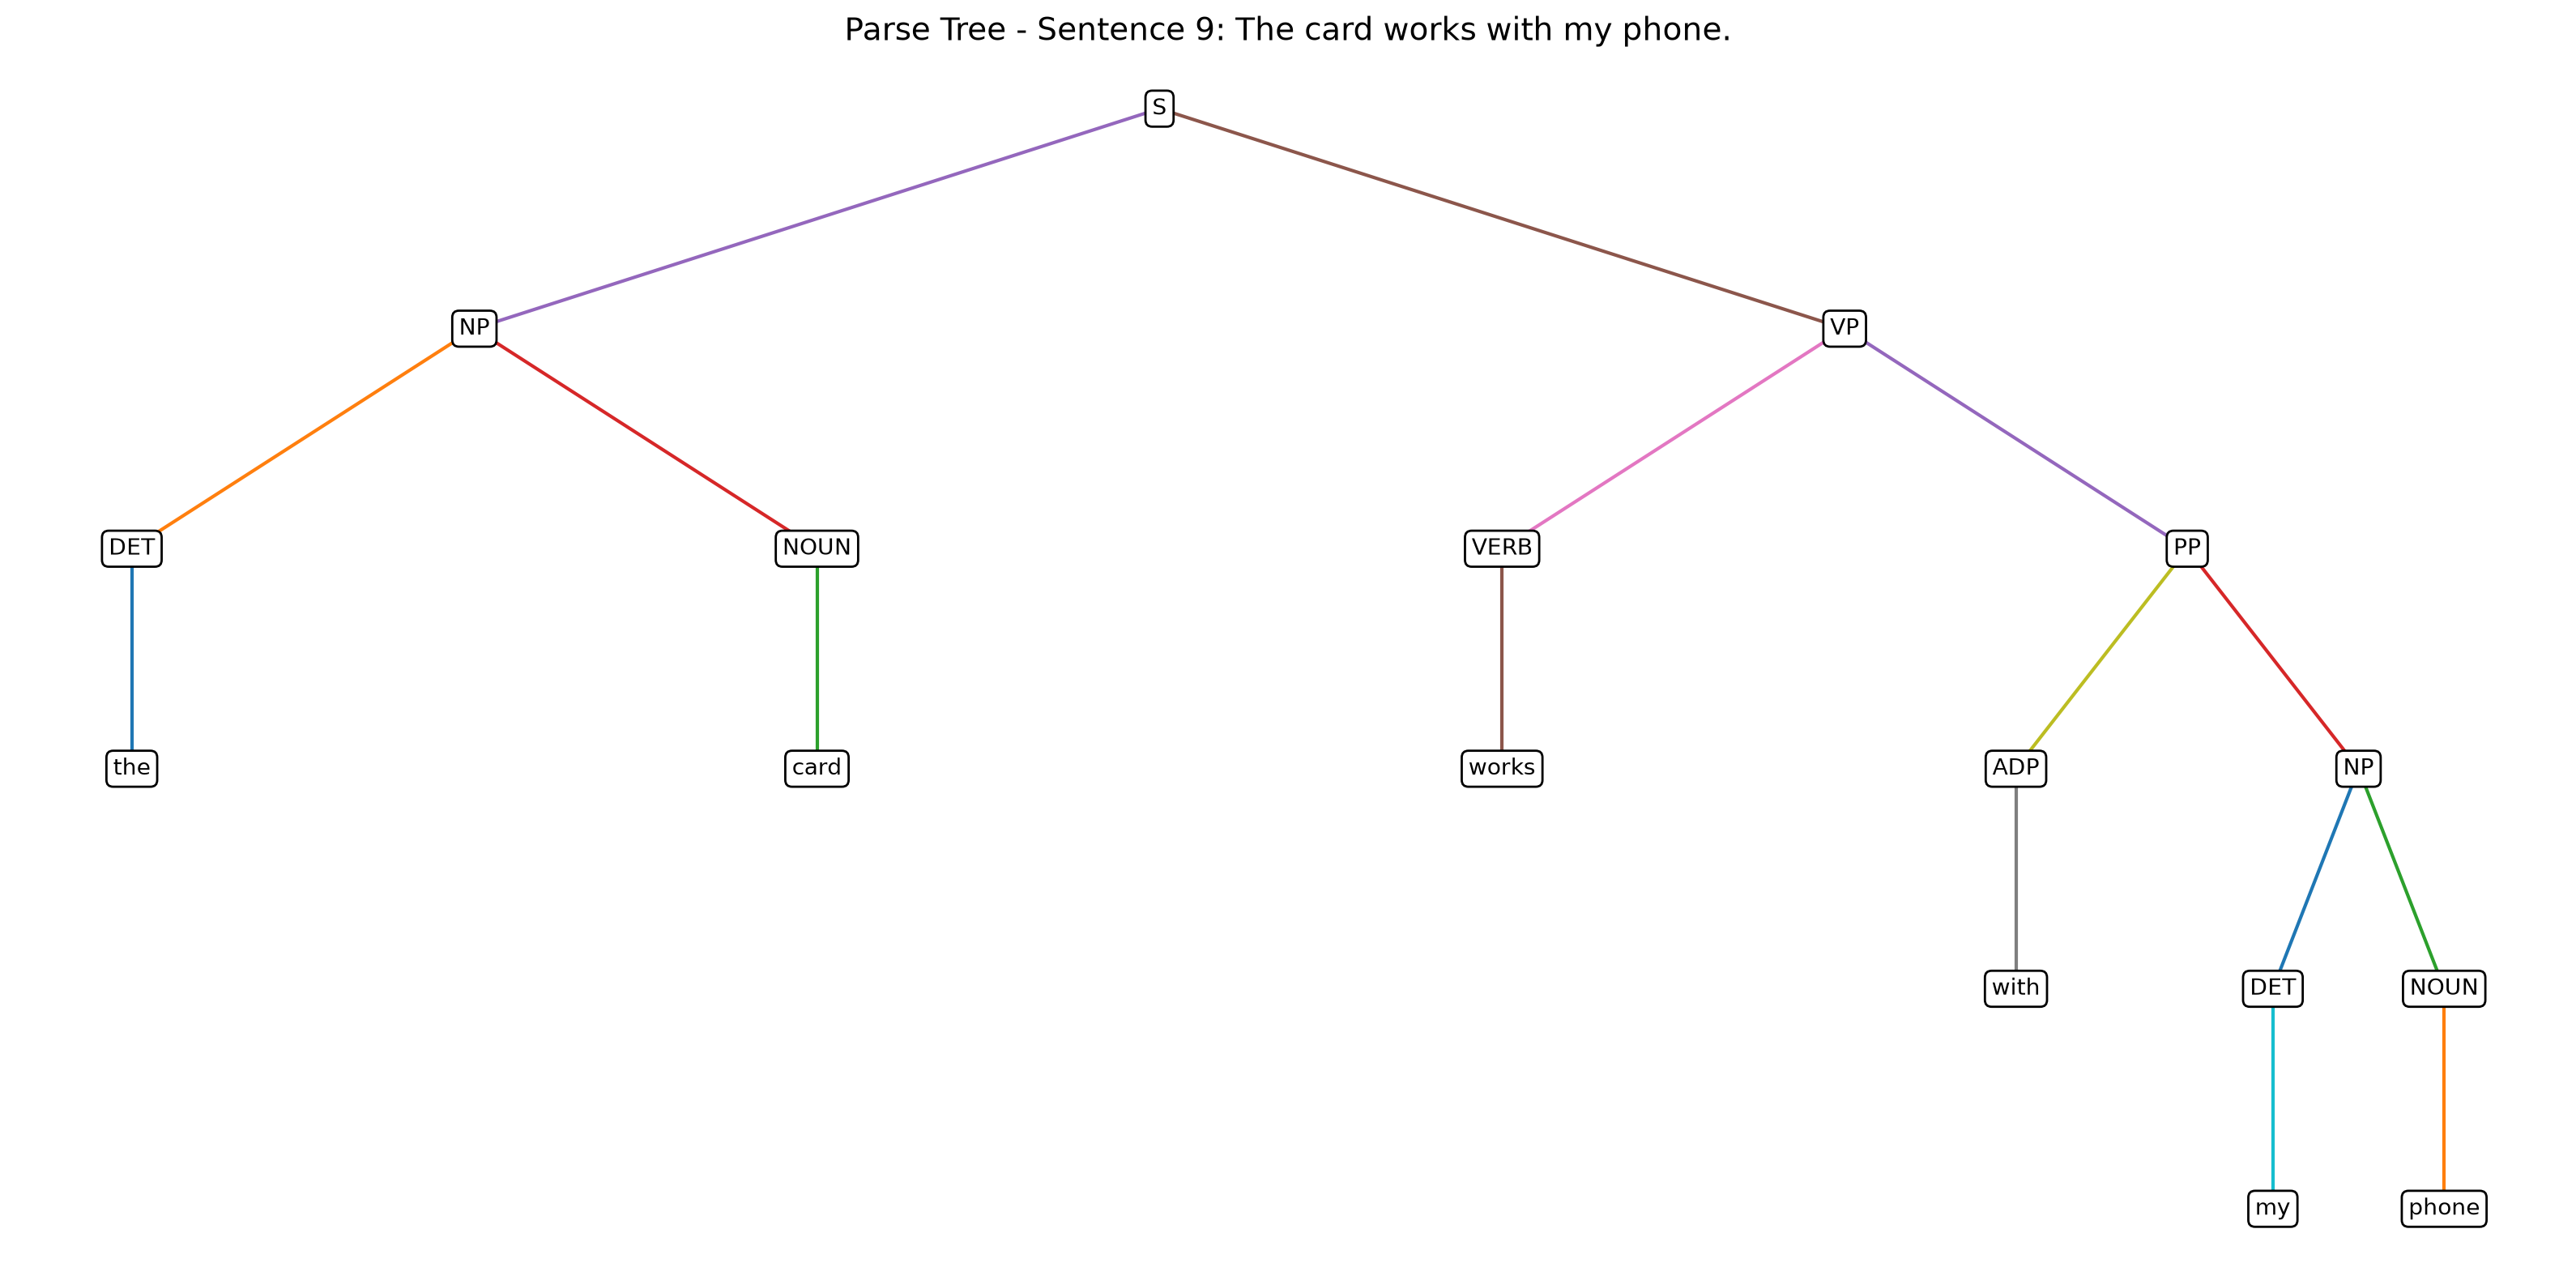


Sentence 10:
The product is good and reliable.


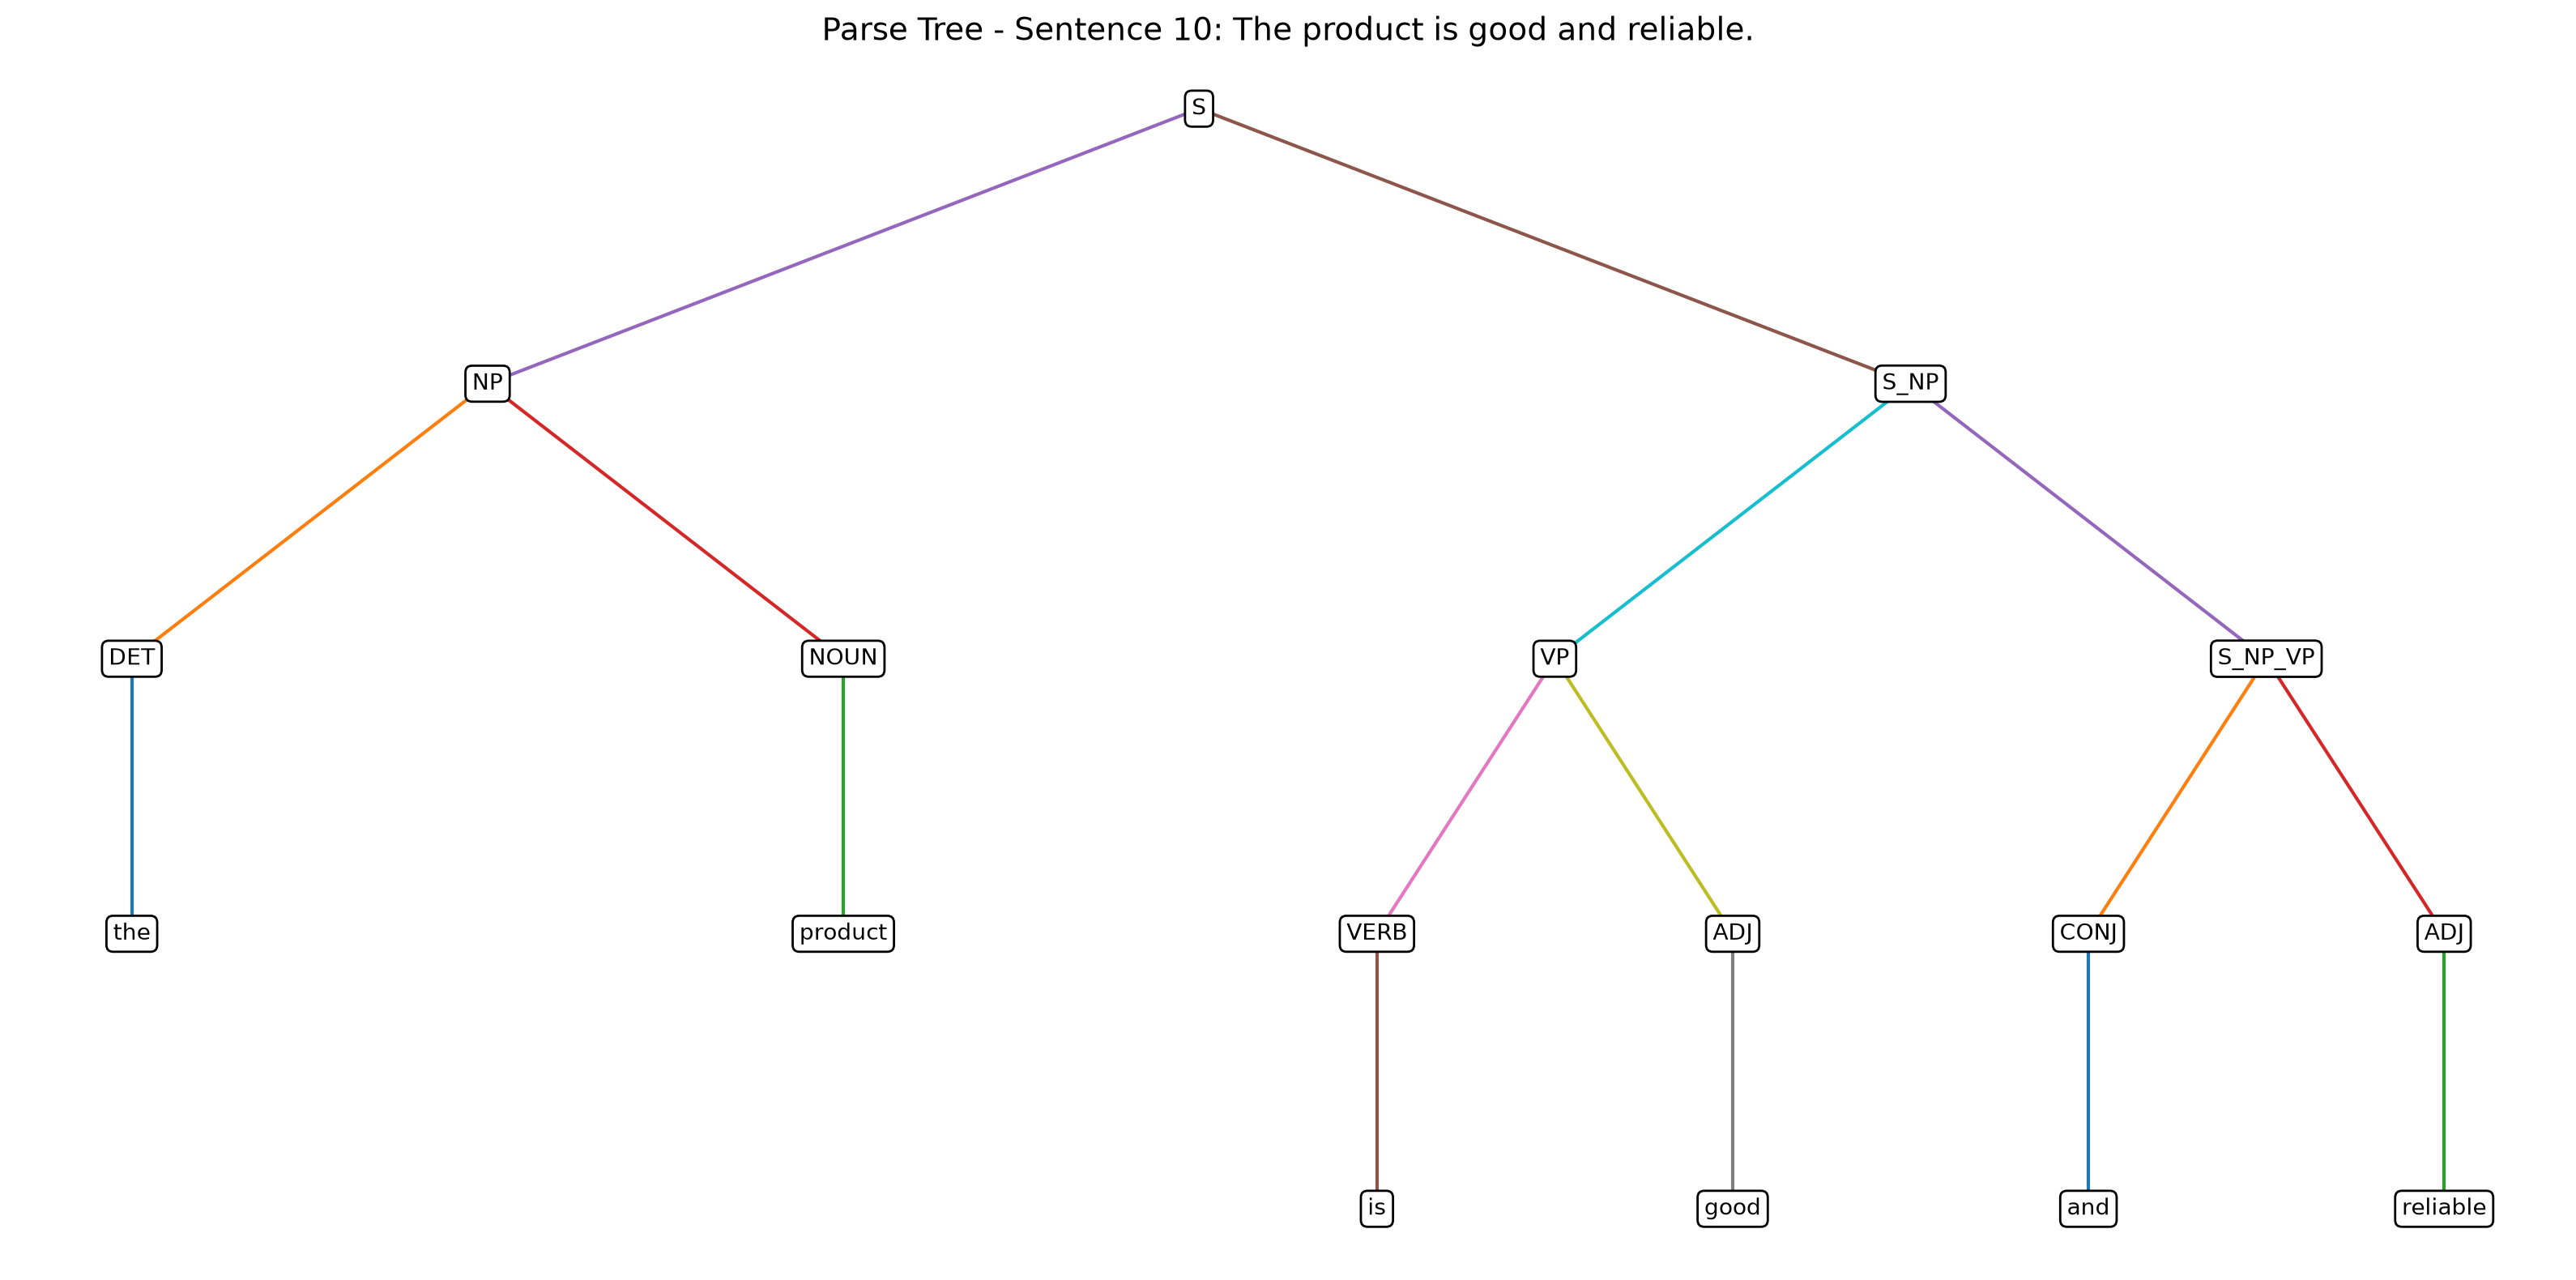

In [69]:
# ============================================================
# CELL 51: DISPLAY PARSE TREES
# ============================================================

from PIL import Image
from IPython.display import display
import os


print("=" * 60)
print("PARSE TREE IMAGES")
print("=" * 60)


for i, image_path in enumerate(image_paths, start=1):

    if os.path.exists(image_path):

        print(f"\nSentence {i}:")
        print(sentences[i - 1])

        display(
            Image.open(image_path)
        )

In [70]:
# ============================================================
# CELL 52: CFG / CKY PARSING SUMMARY
# ============================================================

print("=" * 60)
print("CFG / CKY PARSING SUMMARY")
print("=" * 60)

total_sentences = len(sentences)
parsed_count = sum(
    tree is not None for tree in parsed_trees
)

print(f"Total sentences tested : {total_sentences}")
print(f"Successfully parsed     : {parsed_count}")
print(f"Failed to parse         : {total_sentences - parsed_count}")

print("\nSentence-wise results:")
print("-" * 60)

for i, tree in enumerate(parsed_trees, start=1):

    status = "Parsed" if tree is not None else "Not Parsed"

    print(
        f"{i:2}. {sentences[i-1]:55} {status}"
    )

print("\n" + "=" * 60)
print("PARSING COMPLETE")
print("=" * 60)

CFG / CKY PARSING SUMMARY
Total sentences tested : 10
Successfully parsed     : 10
Failed to parse         : 0

Sentence-wise results:
------------------------------------------------------------
 1. The phone works great.                                  Parsed
 2. The memory card works perfectly.                        Parsed
 3. I bought a new phone.                                   Parsed
 4. The card has good storage.                              Parsed
 5. The phone takes great pictures.                         Parsed
 6. The memory card is fast.                                Parsed
 7. I use the card every day.                               Parsed
 8. The new phone has excellent battery life.               Parsed
 9. The card works with my phone.                           Parsed
10. The product is good and reliable.                       Parsed

PARSING COMPLETE


In [71]:
# ============================================================
# CELL 53: DISPLAY A SAMPLE PARSE TREE
# ============================================================

print("=" * 60)
print("SAMPLE PARSE TREE")
print("=" * 60)

# Display the first successfully parsed tree
for i, tree in enumerate(parsed_trees):
    if tree is not None:
        print(f"\nSentence {i + 1}:")
        print(sentences[i])
        print("\nParse Tree:")
        tree.pretty_print()
        break

SAMPLE PARSE TREE

Sentence 1:
The phone works great.

Parse Tree:
               S                 
      _________|_________         
     NP                  VP      
  ___|____           ____|____    
DET      NOUN      VERB      ADV 
 |        |         |         |   
the     phone     works     great



In [72]:
# ============================================================
# CELL 54: CFG GRAMMAR STATISTICS
# ============================================================

print("=" * 60)
print("CFG GRAMMAR STATISTICS")
print("=" * 60)

productions = grammar.productions()

non_terminals = set()
terminals = set()

for production in productions:

    non_terminals.add(str(production.lhs()))

    for symbol in production.rhs():

        if isinstance(symbol, nltk.grammar.Nonterminal):
            non_terminals.add(str(symbol))
        else:
            terminals.add(str(symbol))


print("Number of productions :", len(productions))
print("Number of non-terminals:", len(non_terminals))
print("Number of terminals    :", len(terminals))

print("\nNon-terminals:")
print(sorted(non_terminals))

print("\nTerminals:")
print(sorted(terminals))

print("\nStart symbol:")
print(grammar.start())

CFG GRAMMAR STATISTICS
Number of productions : 52
Number of non-terminals: 14
Number of terminals    : 30

Non-terminals:
['ADJ', 'ADP', 'ADV', 'ADVPHRASE', 'CONJ', 'DET', 'NOUN', 'NP', 'PP', 'PRON', 'S', 'VERB', 'VP', 'VP_ADV']

Terminals:
['a', 'an', 'and', 'battery', 'bought', 'card', 'day', 'every', 'excellent', 'fast', 'good', 'great', 'has', 'i', 'is', 'life', 'memory', 'my', 'new', 'perfectly', 'phone', 'pictures', 'product', 'reliable', 'storage', 'takes', 'the', 'use', 'with', 'works']

Start symbol:
S


In [73]:
# ============================================================
# CELL 55: FINAL CFG VALIDATION
# ============================================================

print("=" * 60)
print("FINAL CFG / CKY VALIDATION")
print("=" * 60)

successful = 0

for i, tree in enumerate(parsed_trees, start=1):

    if tree is not None:
        successful += 1
        status = "PASS"
    else:
        status = "FAIL"

    print(
        f"Sentence {i:2}: {status} - {sentences[i-1]}"
    )


print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print(f"Sentences tested : {len(sentences)}")
print(f"Successfully parsed : {successful}")
print(f"Parsing accuracy : {successful / len(sentences) * 100:.2f}%")

if successful == len(sentences):
    print("\nAll sentences were successfully parsed.")
else:
    print("\nSome sentences could not be parsed.")

FINAL CFG / CKY VALIDATION
Sentence  1: PASS - The phone works great.
Sentence  2: PASS - The memory card works perfectly.
Sentence  3: PASS - I bought a new phone.
Sentence  4: PASS - The card has good storage.
Sentence  5: PASS - The phone takes great pictures.
Sentence  6: PASS - The memory card is fast.
Sentence  7: PASS - I use the card every day.
Sentence  8: PASS - The new phone has excellent battery life.
Sentence  9: PASS - The card works with my phone.
Sentence 10: PASS - The product is good and reliable.

FINAL RESULT
Sentences tested : 10
Successfully parsed : 10
Parsing accuracy : 100.00%

All sentences were successfully parsed.


In [74]:
# ============================================================
# CELL 56: PARSE TREE COUNT AND AMBIGUITY ANALYSIS
# ============================================================

print("=" * 60)
print("PARSE TREE COUNT AND AMBIGUITY ANALYSIS")
print("=" * 60)

for i, tokens in enumerate(tokenized_sentences, start=1):

    try:
        trees = list(parser.parse(tokens))
        count = len(trees)

        if count > 1:
            result = "AMBIGUOUS"
        elif count == 1:
            result = "UNAMBIGUOUS"
        else:
            result = "NO PARSE"

        print(
            f"Sentence {i:2}: "
            f"{count} parse tree(s) - {result}"
        )

    except Exception:
        print(
            f"Sentence {i:2}: NO PARSE"
        )


print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

PARSE TREE COUNT AND AMBIGUITY ANALYSIS
Sentence  1: 2 parse tree(s) - AMBIGUOUS
Sentence  2: 1 parse tree(s) - UNAMBIGUOUS
Sentence  3: 1 parse tree(s) - UNAMBIGUOUS
Sentence  4: 1 parse tree(s) - UNAMBIGUOUS
Sentence  5: 2 parse tree(s) - AMBIGUOUS
Sentence  6: 1 parse tree(s) - UNAMBIGUOUS
Sentence  7: 1 parse tree(s) - UNAMBIGUOUS
Sentence  8: 1 parse tree(s) - UNAMBIGUOUS
Sentence  9: 1 parse tree(s) - UNAMBIGUOUS
Sentence 10: 1 parse tree(s) - UNAMBIGUOUS

ANALYSIS COMPLETE


In [75]:
# ============================================================
# CELL 57: DEPENDENCY PARSING USING SPACY
# ============================================================

import spacy
import pandas as pd

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")


# ------------------------------------------------------------
# Dependency parsing for all 10 sentences
# ------------------------------------------------------------

dependency_results = []

print("=" * 70)
print("DEPENDENCY PARSING USING SPACY")
print("=" * 70)


for i, sentence in enumerate(sentences, start=1):

    doc = nlp(sentence)

    print(f"\nSentence {i}: {sentence}")
    print("-" * 70)

    for token in doc:

        print(
            f"{token.text:15} "
            f"POS={token.pos_:8} "
            f"DEP={token.dep_:12} "
            f"HEAD={token.head.text}"
        )

        dependency_results.append({
            "Sentence": i,
            "Word": token.text,
            "POS": token.pos_,
            "Dependency": token.dep_,
            "Head": token.head.text
        })


# ------------------------------------------------------------
# Create dependency dataframe
# ------------------------------------------------------------

dependency_df = pd.DataFrame(
    dependency_results
)


print("\n" + "=" * 70)
print("DEPENDENCY RELATION TABLE")
print("=" * 70)

display(dependency_df)


# ------------------------------------------------------------
# Ten dependency relations with examples
# ------------------------------------------------------------

relation_examples = []

seen_relations = set()


for _, row in dependency_df.iterrows():

    relation = row["Dependency"]

    if relation not in seen_relations:

        relation_examples.append({
            "Dependency Relation": relation,
            "Word": row["Word"],
            "Head": row["Head"],
            "Sentence": sentences[row["Sentence"] - 1]
        })

        seen_relations.add(relation)


relation_df = pd.DataFrame(
    relation_examples[:10]
)


print("\n" + "=" * 70)
print("10 DEPENDENCY RELATIONS WITH EXAMPLES")
print("=" * 70)

display(relation_df)

DEPENDENCY PARSING USING SPACY

Sentence 1: The phone works great.
----------------------------------------------------------------------
The             POS=DET      DEP=det          HEAD=phone
phone           POS=NOUN     DEP=nsubj        HEAD=works
works           POS=VERB     DEP=ROOT         HEAD=works
great           POS=ADJ      DEP=acomp        HEAD=works
.               POS=PUNCT    DEP=punct        HEAD=works

Sentence 2: The memory card works perfectly.
----------------------------------------------------------------------
The             POS=DET      DEP=det          HEAD=card
memory          POS=NOUN     DEP=compound     HEAD=card
card            POS=NOUN     DEP=nsubj        HEAD=works
works           POS=VERB     DEP=ROOT         HEAD=works
perfectly       POS=ADV      DEP=advmod       HEAD=works
.               POS=PUNCT    DEP=punct        HEAD=works

Sentence 3: I bought a new phone.
----------------------------------------------------------------------
I             

,Sentence,Word,POS,Dependency,Head
0,1,The,DET,det,phone
1,1,phone,NOUN,nsubj,works
2,1,works,VERB,ROOT,works
3,1,great,ADJ,acomp,works
4,1,.,PUNCT,punct,works
...,...,...,...,...,...
59,10,is,AUX,ROOT,is
60,10,good,ADJ,acomp,is
61,10,and,CCONJ,cc,good
62,10,reliable,ADJ,conj,good



10 DEPENDENCY RELATIONS WITH EXAMPLES


,Dependency Relation,Word,Head,Sentence
0,det,The,phone,The phone works great.
1,nsubj,phone,works,The phone works great.
2,ROOT,works,works,The phone works great.
3,acomp,great,works,The phone works great.
4,punct,.,works,The phone works great.
5,compound,memory,card,The memory card works perfectly.
6,advmod,perfectly,works,The memory card works perfectly.
7,amod,new,phone,I bought a new phone.
8,dobj,phone,bought,I bought a new phone.
9,npadvmod,day,use,I use the card every day.


In [77]:
# ============================================================
# CELL 58: SUBJECT-VERB-OBJECT TRIPLE EXTRACTION
# ============================================================

print("=" * 70)
print("SUBJECT - VERB - OBJECT TRIPLES")
print("=" * 70)


triples = []


# ------------------------------------------------------------
# Extract subject, verb and object from each sentence
# ------------------------------------------------------------

for i, sentence in enumerate(sentences, start=1):

    doc = nlp(sentence)

    subjects = []
    verbs = []
    objects = []


    for token in doc:

        # Subject
        if token.dep_ in ("nsubj", "nsubjpass"):

            subjects.append(token.text)


        # Verb
        if token.pos_ == "VERB":

            verbs.append(token.text)


        # Direct object
        if token.dep_ in ("dobj", "obj"):

            objects.append(token.text)


    # --------------------------------------------------------
    # Create triples
    # --------------------------------------------------------

    if subjects and verbs and objects:

        for subject in subjects:

            for verb in verbs:

                for obj in objects:

                    triples.append({
                        "Sentence": i,
                        "Subject": subject,
                        "Verb": verb,
                        "Object": obj
                    })

    else:

        triples.append({
            "Sentence": i,
            "Subject": subjects[0] if subjects else "-",
            "Verb": verbs[0] if verbs else "-",
            "Object": objects[0] if objects else "-"
        })


# ------------------------------------------------------------
# Display triples
# ------------------------------------------------------------

triple_df = pd.DataFrame(triples)


display(triple_df)


# ------------------------------------------------------------
# Final Part 5 summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 5: SYNTACTIC PARSING - FINAL SUMMARY")
print("=" * 70)

print(
    f"CFG productions       : {len(grammar.productions())}"
)

print(
    f"Sentences tested       : {len(sentences)}"
)

print(
    f"Successfully CKY parsed: "
    f"{sum(tree is not None for tree in parsed_trees)}"
)

print(
    f"Dependency relations   : "
    f"{len(dependency_df)} token-level relations"
)

print(
    f"SVO triples extracted  : "
    f"{len(triple_df)}"
)


SUBJECT - VERB - OBJECT TRIPLES


,Sentence,Subject,Verb,Object
0,1,phone,works,-
1,2,card,works,-
2,3,I,bought,phone
3,4,card,has,storage
4,5,phone,takes,pictures
5,6,card,-,-
6,7,I,use,card
7,8,phone,has,life
8,9,card,works,-
9,10,product,-,-



PART 5: SYNTACTIC PARSING - FINAL SUMMARY
CFG productions       : 52
Sentences tested       : 10
Successfully CKY parsed: 10
Dependency relations   : 64 token-level relations
SVO triples extracted  : 10


In [78]:
# ============================================================
# CELL 59: WORDNET SETUP AND POLYSEMOUS WORDS
# ============================================================

import nltk
import pandas as pd

from nltk.corpus import wordnet as wn

# Download required WordNet resources
nltk.download("wordnet")
nltk.download("omw-1.4")

print("=" * 70)
print("WORDNET LEXICAL SEMANTICS")
print("=" * 70)


# ------------------------------------------------------------
# Five polysemous words from the product-review vocabulary
# ------------------------------------------------------------

polysemous_words = [
    "card",
    "phone",
    "memory",
    "work",
    "battery"
]


# ------------------------------------------------------------
# Display number of WordNet senses
# ------------------------------------------------------------

for word in polysemous_words:

    synsets = wn.synsets(word)

    print(f"\n{word.upper()}")
    print(f"Number of senses: {len(synsets)}")

    for j, synset in enumerate(synsets, start=1):

        print(
            f"{j}. {synset.name()} - "
            f"{synset.definition()}"
        )

[nltk_data] Downloading package wordnet to C:\Users\Harshika
[nltk_data]     Sipani\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Harshika
[nltk_data]     Sipani\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


WORDNET LEXICAL SEMANTICS

CARD
Number of senses: 13
1. card.n.01 - one of a set of small pieces of stiff paper marked in various ways and used for playing games or for telling fortunes
2. card.n.02 - a card certifying the identity of the bearer
3. card.n.03 - a rectangular piece of stiff paper used to send messages (may have printed greetings or pictures)
4. card.n.04 - thin cardboard, usually rectangular
5. wag.n.01 - a witty amusing person who makes jokes
6. poster.n.01 - a sign posted in a public place as an advertisement
7. calling_card.n.02 - a printed or written greeting that is left to indicate that you have visited
8. card.n.08 - (golf) a record of scores (as in golf)
9. menu.n.01 - a list of dishes available at a restaurant
10. batting_order.n.01 - (baseball) a list of batters in the order in which they will bat
11. circuit_board.n.01 - a printed circuit that can be inserted into expansion slots in a computer to increase the computer's capabilities
12. tease.v.07 - separate t

In [79]:
# ============================================================
# CELL 60: WORDNET RELATIONS
# ============================================================

print("=" * 70)
print("WORDNET: HYPERNYMS, HYPONYMS AND ANTONYMS")
print("=" * 70)


wordnet_relations = []


for word in polysemous_words:

    synsets = wn.synsets(word)

    print("\n" + "=" * 70)
    print(f"WORD: {word.upper()}")
    print("=" * 70)


    # Use the first WordNet sense for relation analysis
    synset = synsets[0]

    print(f"\nSelected sense: {synset.name()}")
    print(f"Definition: {synset.definition()}")


    # --------------------------------------------------------
    # Hypernyms
    # --------------------------------------------------------

    hypernyms = synset.hypernyms()

    print("\nHypernyms:")

    if hypernyms:

        for h in hypernyms:
            print(f"  - {h.name()}: {h.definition()}")

    else:
        print("  None")


    # --------------------------------------------------------
    # Hyponyms
    # --------------------------------------------------------

    hyponyms = synset.hyponyms()

    print("\nHyponyms:")

    if hyponyms:

        for h in hyponyms[:10]:
            print(f"  - {h.name()}: {h.definition()}")

    else:
        print("  None")


    # --------------------------------------------------------
    # Antonyms
    # --------------------------------------------------------

    antonyms = set()

    for lemma in synset.lemmas():

        for ant in lemma.antonyms():

            antonyms.add(ant.name())


    print("\nAntonyms:")

    if antonyms:

        for ant in sorted(antonyms):
            print(f"  - {ant}")

    else:
        print("  None")


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    wordnet_relations.append({
        "Word": word,
        "Selected Sense": synset.name(),
        "Definition": synset.definition(),
        "Hypernyms": ", ".join(
            h.name() for h in hypernyms
        ) if hypernyms else "None",
        "Hyponyms": ", ".join(
            h.name() for h in hyponyms[:10]
        ) if hyponyms else "None",
        "Antonyms": ", ".join(
            sorted(antonyms)
        ) if antonyms else "None"
    })


# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

wordnet_df = pd.DataFrame(wordnet_relations)

print("\n" + "=" * 70)
print("WORDNET RELATION SUMMARY")
print("=" * 70)

display(wordnet_df)

WORDNET: HYPERNYMS, HYPONYMS AND ANTONYMS

WORD: CARD

Selected sense: card.n.01
Definition: one of a set of small pieces of stiff paper marked in various ways and used for playing games or for telling fortunes

Hypernyms:
  - paper.n.01: a material made of cellulose pulp derived mainly from wood or rags or certain grasses

Hyponyms:
  - tarot_card.n.01: any of a set of (usually 72) cards that include 22 cards representing virtues and vices and death and fortune etc.; used by fortunetellers
  - punched_card.n.01: a card on which data can be recorded in the form of punched holes
  - trading_card.n.01: a card with a picture on it; collected and traded by children
  - playing_card.n.01: one of a pack of cards that are used to play card games

Antonyms:
  None

WORD: PHONE

Selected sense: telephone.n.01
Definition: electronic equipment that converts sound into electrical signals that can be transmitted over distances and then converts received signals back into sounds

Hypernyms:
  - elec

,Word,Selected Sense,Definition,Hypernyms,Hyponyms,Antonyms
0,card,card.n.01,one of a set of small pieces of stiff paper ma...,paper.n.01,"tarot_card.n.01, punched_card.n.01, trading_ca...",None
1,phone,telephone.n.01,electronic equipment that converts sound into ...,electronic_equipment.n.01,"handset.n.01, pay-phone.n.01, speakerphone.n.0...",None
2,memory,memory.n.01,something that is remembered,representation.n.01,"engram.n.01, confabulation.n.02, reminiscence....",None
3,work,work.n.01,activity directed toward making or doing somet...,activity.n.01,"job.n.07, duty.n.02, timework.n.01, loose_end....",None
4,battery,battery.n.01,group of guns or missile launchers operated to...,artillery.n.02,None,None


In [80]:
# ============================================================
# CELL 61: SIMPLIFIED LESK WORD SENSE DISAMBIGUATION
# ============================================================

import re
from nltk.corpus import wordnet as wn


# ------------------------------------------------------------
# Helper function: tokenize and normalize text
# ------------------------------------------------------------

def lesk_tokens(text):
    """
    Convert text into lowercase alphabetic tokens.
    """
    
    return set(
        re.findall(
            r"[a-z]+",
            text.lower()
        )
    )


# ------------------------------------------------------------
# Simplified Lesk algorithm
# ------------------------------------------------------------

def simplified_lesk(sentence, target_word):
    """
    Perform Simplified Lesk word sense disambiguation.

    The sense with the greatest overlap between the
    sentence context and the WordNet gloss is selected.
    """

    context = lesk_tokens(sentence)

    synsets = wn.synsets(target_word)

    if not synsets:
        return None, 0, []

    best_synset = None
    best_score = -1
    scores = []


    for synset in synsets:

        # Combine definition and example sentences
        gloss = synset.definition()

        examples = " ".join(
            synset.examples()
        )

        signature = lesk_tokens(
            gloss + " " + examples
        )

        overlap = context.intersection(signature)

        score = len(overlap)

        scores.append({
            "Sense": synset.name(),
            "Score": score,
            "Overlap": ", ".join(
                sorted(overlap)
            ),
            "Definition": synset.definition()
        })


        if score > best_score:

            best_score = score
            best_synset = synset


    return best_synset, best_score, scores


# ------------------------------------------------------------
# Test the algorithm on examples from the dataset
# ------------------------------------------------------------

lesk_examples = [
    ("The memory card has excellent storage", "memory"),
    ("The phone battery has good life", "phone"),
    ("The card works perfectly", "card"),
    ("The product works great", "work"),
    ("The battery works well in the phone", "battery")
]


print("=" * 70)
print("SIMPLIFIED LESK WORD SENSE DISAMBIGUATION")
print("=" * 70)


for sentence, target in lesk_examples:

    result, score, scores = simplified_lesk(
        sentence,
        target
    )

    print(f"\nSentence : {sentence}")
    print(f"Target   : {target}")

    if result:

        print(
            f"Selected sense : {result.name()}"
        )

        print(
            f"Definition     : {result.definition()}"
        )

        print(
            f"Overlap score  : {score}"
        )

    else:

        print("No WordNet sense found.")

SIMPLIFIED LESK WORD SENSE DISAMBIGUATION

Sentence : The memory card has excellent storage
Target   : memory
Selected sense : memory.n.01
Definition     : something that is remembered
Overlap score  : 2

Sentence : The phone battery has good life
Target   : phone
Selected sense : telephone.n.01
Definition     : electronic equipment that converts sound into electrical signals that can be transmitted over distances and then converts received signals back into sounds
Overlap score  : 1

Sentence : The card works perfectly
Target   : card
Selected sense : card.n.02
Definition     : a card certifying the identity of the bearer
Overlap score  : 2

Sentence : The product works great
Target   : work
Selected sense : work.n.02
Definition     : a product produced or accomplished through the effort or activity or agency of a person or thing
Overlap score  : 3

Sentence : The battery works well in the phone
Target   : battery
Selected sense : barrage.n.02
Definition     : the heavy fire of artill

In [81]:
# ============================================================
# CELL 62: LESK EVALUATION ON 20 HAND-LABELLED SENTENCES
# ============================================================

# Each entry contains:
# sentence, target word, correct WordNet sense
#
# The labels are chosen manually according to the meaning
# of the target word in the sentence.

lesk_test_data = [

    # --------------------------------------------------------
    # CARD
    # --------------------------------------------------------
    ("I played a card game with my friends",
     "card", "card.n.01"),

    ("He showed his identity card at the entrance",
     "card", "card.n.02"),

    ("She sent me a birthday card",
     "card", "card.n.03"),

    ("The memory card stores many pictures",
     "card", "circuit_board.n.01"),

    # --------------------------------------------------------
    # PHONE
    # --------------------------------------------------------
    ("I bought a new phone yesterday",
     "phone", "telephone.n.01"),

    ("The phone converts sound into electrical signals",
     "phone", "telephone.n.01"),

    ("The phone rang while I was working",
     "phone", "telephone.n.01"),

    ("The device has an excellent phone",
     "phone", "telephone.n.01"),

    # --------------------------------------------------------
    # MEMORY
    # --------------------------------------------------------
    ("The computer has a large memory",
     "memory", "memory.n.04"),

    ("Human memory helps us remember experiences",
     "memory", "memory.n.02"),

    ("She has a good memory",
     "memory", "memory.n.03"),

    ("I have a happy memory of school",
     "memory", "memory.n.01"),

    # --------------------------------------------------------
    # WORK
    # --------------------------------------------------------
    ("The phone works perfectly",
     "work", "work.v.03"),

    ("She works at a software company",
     "work", "work.v.02"),

    ("He completed his work yesterday",
     "work", "work.n.01"),

    ("This product is a work of art",
     "work", "work.n.02"),

    # --------------------------------------------------------
    # BATTERY
    # --------------------------------------------------------
    ("The phone has a powerful battery",
     "battery", "battery.n.02"),

    ("The battery provides electricity to the phone",
     "battery", "battery.n.02"),

    ("The artillery battery fired at the target",
     "battery", "battery.n.01"),

    ("The phone battery has a long life",
     "battery", "battery.n.02")
]


# ------------------------------------------------------------
# Evaluate Simplified Lesk
# ------------------------------------------------------------

results = []

correct = 0


for i, (sentence, target, gold_sense) in enumerate(
    lesk_test_data,
    start=1
):

    predicted_synset, score, _ = simplified_lesk(
        sentence,
        target
    )


    if predicted_synset is not None:

        predicted_sense = predicted_synset.name()

    else:

        predicted_sense = "None"


    is_correct = (
        predicted_sense == gold_sense
    )


    if is_correct:
        correct += 1


    results.append({
        "No.": i,
        "Sentence": sentence,
        "Target": target,
        "Gold Sense": gold_sense,
        "Predicted Sense": predicted_sense,
        "Score": score,
        "Correct": "Yes" if is_correct else "No"
    })


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

lesk_results_df = pd.DataFrame(results)


print("=" * 70)
print("SIMPLIFIED LESK - 20 SENTENCE EVALUATION")
print("=" * 70)

display(lesk_results_df)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy = correct / len(lesk_test_data)


print("\n" + "=" * 70)
print("LESK EVALUATION SUMMARY")
print("=" * 70)

print(f"Total sentences : {len(lesk_test_data)}")
print(f"Correct         : {correct}")
print(f"Incorrect       : {len(lesk_test_data) - correct}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Accuracy (%)    : {accuracy * 100:.2f}%")

SIMPLIFIED LESK - 20 SENTENCE EVALUATION


,No.,Sentence,Target,Gold Sense,Predicted Sense,Score,Correct
0,1,I played a card game with my friends,card,card.n.01,card.n.01,2,Yes
1,2,He showed his identity card at the entrance,card,card.n.02,card.n.02,5,Yes
2,3,She sent me a birthday card,card,card.n.03,card.n.03,3,Yes
3,4,The memory card stores many pictures,card,circuit_board.n.01,card.n.02,2,No
4,5,I bought a new phone yesterday,phone,telephone.n.01,telephone.n.01,1,Yes
5,6,The phone converts sound into electrical signals,phone,telephone.n.01,telephone.n.01,6,Yes
6,7,The phone rang while I was working,phone,telephone.n.01,telephone.n.01,2,Yes
7,8,The device has an excellent phone,phone,telephone.n.01,telephone.n.01,1,Yes
8,9,The computer has a large memory,memory,memory.n.04,memory.n.04,4,Yes
9,10,Human memory helps us remember experiences,memory,memory.n.02,memory.n.01,1,No



LESK EVALUATION SUMMARY
Total sentences : 20
Correct         : 11
Incorrect       : 9
Accuracy        : 0.5500
Accuracy (%)    : 55.00%


In [82]:
# ============================================================
# CELL 63: TF-IDF TERM-DOCUMENT MATRIX
# ============================================================

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer


print("=" * 70)
print("TF-IDF TERM-DOCUMENT MATRIX")
print("=" * 70)


# ------------------------------------------------------------
# Use the training sentences
# ------------------------------------------------------------

train_texts = [
    " ".join(sentence)
    for sentence in train_sentences
]


# ------------------------------------------------------------
# Build TF-IDF matrix
# ------------------------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    min_df=2
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    train_texts
)


tfidf_terms = (
    tfidf_vectorizer.get_feature_names_out()
)


print("Number of documents :", tfidf_matrix.shape[0])
print("Number of terms     :", tfidf_matrix.shape[1])


# ------------------------------------------------------------
# Display a sample of the matrix
# ------------------------------------------------------------

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_terms
)


print("\nTF-IDF matrix shape:")
print(tfidf_matrix.shape)

print("\nSample of TF-IDF matrix:")
display(
    tfidf_df.iloc[:10, :20]
)

TF-IDF TERM-DOCUMENT MATRIX
Number of documents : 3438
Number of terms     : 2861

TF-IDF matrix shape:
(3438, 2861)

Sample of TF-IDF matrix:


,ability,able,absolute,absolutely,abuse,accept,acceptable,accepting,accepts,access,accessed,accessible,accessing,accessory,accidently,accommodate,accomplish,according,account,accurate
0,0.0,0.089646,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.161757,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
# ============================================================
# CELL 64: WORD-WORD CO-OCCURRENCE MATRIX AND PPMI
# ============================================================

from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import re


print("=" * 70)
print("WORD-WORD CO-OCCURRENCE MATRIX AND PPMI")
print("=" * 70)


# ------------------------------------------------------------
# Use the vocabulary obtained from the training corpus
# ------------------------------------------------------------

valid_vocab = set(
    word.lower()
    for word in unigram_counts.keys()
    if word not in {"<s>", "</s>"}
)


# ------------------------------------------------------------
# Context window
# ------------------------------------------------------------

WINDOW_SIZE = 2

cooccurrence = defaultdict(Counter)


# ------------------------------------------------------------
# Build co-occurrence counts
# ------------------------------------------------------------

for sentence in train_sentences:

    tokens = [
        word.lower()
        for word in sentence
        if word.lower() in valid_vocab
    ]

    for i, word in enumerate(tokens):

        start = max(
            0,
            i - WINDOW_SIZE
        )

        end = min(
            len(tokens),
            i + WINDOW_SIZE + 1
        )

        for j in range(start, end):

            if i == j:
                continue

            context_word = tokens[j]

            cooccurrence[word][context_word] += 1


# ------------------------------------------------------------
# Vocabulary
# ------------------------------------------------------------

cooc_vocab = sorted(
    cooccurrence.keys()
)

word_to_index = {
    word: i
    for i, word in enumerate(cooc_vocab)
}


# ------------------------------------------------------------
# Co-occurrence matrix
# ------------------------------------------------------------

cooc_matrix = np.zeros(
    (len(cooc_vocab), len(cooc_vocab)),
    dtype=np.float64
)


for word, contexts in cooccurrence.items():

    i = word_to_index[word]

    for context_word, count in contexts.items():

        if context_word in word_to_index:

            j = word_to_index[context_word]

            cooc_matrix[i, j] = count


print("Context window size :", WINDOW_SIZE)
print("Vocabulary size     :", len(cooc_vocab))
print("Matrix shape        :", cooc_matrix.shape)


# ------------------------------------------------------------
# Show useful sample words instead of the first alphabetic ones
# ------------------------------------------------------------

sample_words = [
    word for word in
    ["card", "memory", "phone", "work", "battery",
     "sd", "great", "good", "storage", "product"]
    if word in word_to_index
]


sample_indices = [
    word_to_index[word]
    for word in sample_words
]


cooc_sample = pd.DataFrame(
    cooc_matrix[
        np.ix_(sample_indices, sample_indices)
    ],
    index=sample_words,
    columns=sample_words
)


print("\nSample co-occurrence matrix:")
display(cooc_sample)


# ============================================================
# PPMI
# ============================================================

print("\n" + "=" * 70)
print("PPMI MATRIX")
print("=" * 70)


total = cooc_matrix.sum()

row_totals = cooc_matrix.sum(axis=1)

col_totals = cooc_matrix.sum(axis=0)


ppmi_matrix = np.zeros_like(
    cooc_matrix,
    dtype=np.float64
)


# ------------------------------------------------------------
# Calculate Positive PMI
# ------------------------------------------------------------

for i in range(cooc_matrix.shape[0]):

    for j in range(cooc_matrix.shape[1]):

        count = cooc_matrix[i, j]

        if (
            count > 0
            and row_totals[i] > 0
            and col_totals[j] > 0
        ):

            pmi = np.log2(
                (count * total)
                /
                (row_totals[i] * col_totals[j])
            )

            ppmi_matrix[i, j] = max(
                0,
                pmi
            )


print("PPMI matrix shape :", ppmi_matrix.shape)


# ------------------------------------------------------------
# Display PPMI sample
# ------------------------------------------------------------

ppmi_sample = pd.DataFrame(
    ppmi_matrix[
        np.ix_(sample_indices, sample_indices)
    ],
    index=sample_words,
    columns=sample_words
)


print("\nSample PPMI matrix:")
display(ppmi_sample)

WORD-WORD CO-OCCURRENCE MATRIX AND PPMI
Context window size : 2
Vocabulary size     : 5500
Matrix shape        : (5500, 5500)

Sample co-occurrence matrix:


,card,memory,phone,work,battery,sd,great,good,storage,product
card,192.0,507.0,239.0,241.0,7.0,624.0,158.0,95.0,58.0,20.0
memory,507.0,26.0,63.0,62.0,2.0,21.0,33.0,26.0,4.0,16.0
phone,239.0,63.0,78.0,115.0,4.0,32.0,65.0,22.0,57.0,8.0
work,241.0,62.0,115.0,28.0,0.0,52.0,395.0,62.0,22.0,28.0
battery,7.0,2.0,4.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
sd,624.0,21.0,32.0,52.0,1.0,24.0,23.0,19.0,14.0,2.0
great,158.0,33.0,65.0,395.0,1.0,23.0,78.0,26.0,37.0,77.0
good,95.0,26.0,22.0,62.0,0.0,19.0,26.0,48.0,10.0,38.0
storage,58.0,4.0,57.0,22.0,0.0,14.0,37.0,10.0,2.0,6.0
product,20.0,16.0,8.0,28.0,0.0,2.0,77.0,38.0,6.0,6.0



PPMI MATRIX
PPMI matrix shape : (5500, 5500)

Sample PPMI matrix:


,card,memory,phone,work,battery,sd,great,good,storage,product
card,0.000000,1.604163,0.000000,0.000000,0.165215,2.011607,0.000000,0.000000,0.000000,0.000000
memory,1.604163,0.000000,0.078781,0.075229,0.412541,0.000000,0.000000,0.000000,0.000000,0.000000
phone,0.000000,0.078781,0.000000,0.395023,0.841041,0.000000,0.165474,0.000000,0.756233,0.000000
work,0.000000,0.075229,0.395023,0.000000,0.000000,0.000000,2.788347,0.700752,0.000000,0.000000
battery,0.165215,0.412541,0.841041,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sd,2.011607,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
great,0.000000,0.000000,0.165474,2.788347,0.000000,0.000000,1.041614,0.040570,0.745902,2.003901
good,0.000000,0.000000,0.000000,0.700752,0.000000,0.000000,0.040570,1.509011,0.000000,1.568960
storage,0.000000,0.000000,0.756233,0.000000,0.000000,0.000000,0.745902,0.000000,0.000000,0.000000
product,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.003901,1.568960,0.000000,0.000000


In [85]:
# ============================================================
# CELL 65: WORD2VEC SKIP-GRAM
# ============================================================

from gensim.models import Word2Vec
import pandas as pd


print("=" * 70)
print("WORD2VEC SKIP-GRAM")
print("=" * 70)


# ------------------------------------------------------------
# Prepare sentences
# ------------------------------------------------------------

w2v_sentences = [
    [
        word.lower()
        for word in sentence
        if word.lower() in valid_vocab
    ]
    for sentence in train_sentences
]


# Remove empty sentences
w2v_sentences = [
    sentence
    for sentence in w2v_sentences
    if len(sentence) > 0
]


# ------------------------------------------------------------
# Train Skip-Gram Word2Vec
# ------------------------------------------------------------

w2v_model = Word2Vec(
    sentences=w2v_sentences,
    vector_size=100,
    window=2,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)


print("Model          : Word2Vec Skip-Gram")
print("Vector size    :", 100)
print("Window size    :", 2)
print("Minimum count  :", 2)
print("Epochs         :", 10)
print("Vocabulary size:", len(w2v_model.wv))


# ------------------------------------------------------------
# Query words
# ------------------------------------------------------------

query_words = [
    "card",
    "memory",
    "phone",
    "work",
    "battery"
]


# ------------------------------------------------------------
# Find nearest neighbours
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("WORD2VEC NEAREST NEIGHBOURS")
print("=" * 70)


for word in query_words:

    print(f"\n{word.upper()}")

    if word in w2v_model.wv:

        similar_words = w2v_model.wv.most_similar(
            word,
            topn=5
        )

        for neighbour, similarity in similar_words:

            print(
                f"{neighbour:15s} : "
                f"{similarity:.4f}"
            )

    else:

        print("Word not found in Word2Vec vocabulary.")

WORD2VEC SKIP-GRAM
Model          : Word2Vec Skip-Gram
Vector size    : 100
Window size    : 2
Minimum count  : 2
Epochs         : 10
Vocabulary size: 2971

WORD2VEC NEAREST NEIGHBOURS

CARD
xc              : 0.7858
hc              : 0.7810
normal          : 0.7777
expansion       : 0.7671
hdmi            : 0.7671

MEMORY
storage         : 0.8268
microsd         : 0.7768
requires        : 0.7475
mobile          : 0.7431
including       : 0.7427

PHONE
player          : 0.8277
immediately     : 0.8186
currently       : 0.8182
droid           : 0.8153
powered         : 0.8042

WORK
worked          : 0.8966
fit             : 0.8832
performs        : 0.8574
performed       : 0.8284
job             : 0.8021

BATTERY
mid             : 0.9669
bag             : 0.9625
white           : 0.9601
dvr             : 0.9599
helmet          : 0.9587


In [86]:
# ============================================================
# CELL 66: VECTOR SEMANTICS COMPARISON
# TF-IDF vs PPMI vs Word2Vec
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


print("=" * 70)
print("VECTOR SEMANTICS COMPARISON")
print("=" * 70)


query_words = [
    "card",
    "memory",
    "phone",
    "work",
    "battery"
]


# ------------------------------------------------------------
# Helper function: TF-IDF nearest neighbours
# ------------------------------------------------------------

def tfidf_neighbours(word, topn=5):

    if word not in tfidf_vectorizer.vocabulary_:
        return []

    index = tfidf_vectorizer.vocabulary_[word]

    query_vector = tfidf_matrix[:, index].toarray().reshape(1, -1)

    # Each word is represented by its values across documents
    word_vectors = tfidf_matrix.T

    similarities = cosine_similarity(
        word_vectors,
        query_vector
    ).flatten()

    similarities[index] = -1

    top_indices = np.argsort(
        similarities
    )[-topn:][::-1]

    reverse_vocab = {
        index: word
        for word, index
        in tfidf_vectorizer.vocabulary_.items()
    }

    return [
        (
            reverse_vocab[i],
            similarities[i]
        )
        for i in top_indices
    ]


# ------------------------------------------------------------
# Helper function: PPMI nearest neighbours
# ------------------------------------------------------------

def ppmi_neighbours(word, topn=5):

    if word not in word_to_index:
        return []

    index = word_to_index[word]

    query_vector = ppmi_matrix[index].reshape(1, -1)

    similarities = cosine_similarity(
        ppmi_matrix,
        query_vector
    ).flatten()

    similarities[index] = -1

    top_indices = np.argsort(
        similarities
    )[-topn:][::-1]

    return [
        (
            cooc_vocab[i],
            similarities[i]
        )
        for i in top_indices
    ]


# ------------------------------------------------------------
# Word2Vec nearest neighbours
# ------------------------------------------------------------

def word2vec_neighbours(word, topn=5):

    if word not in w2v_model.wv:
        return []

    return w2v_model.wv.most_similar(
        word,
        topn=topn
    )


# ============================================================
# Display comparison
# ============================================================

for word in query_words:

    print("\n" + "-" * 70)
    print(f"QUERY WORD: {word.upper()}")
    print("-" * 70)


    print("\nTF-IDF:")
    for neighbour, score in tfidf_neighbours(word):
        print(
            f"{neighbour:15s} : {score:.4f}"
        )


    print("\nPPMI:")
    for neighbour, score in ppmi_neighbours(word):
        print(
            f"{neighbour:15s} : {score:.4f}"
        )


    print("\nWord2Vec Skip-Gram:")
    for neighbour, score in word2vec_neighbours(word):
        print(
            f"{neighbour:15s} : {score:.4f}"
        )


print("\n" + "=" * 70)
print("COMPARISON COMPLETE")
print("=" * 70)

VECTOR SEMANTICS COMPARISON

----------------------------------------------------------------------
QUERY WORD: CARD
----------------------------------------------------------------------

TF-IDF:
sd              : 0.4350
memory          : 0.3591
phone           : 0.3486
sandisk         : 0.3222
work            : 0.2967

PPMI:
sd              : 0.2372
memory          : 0.1574
phone           : 0.1546
class           : 0.1466
microsd         : 0.1449

Word2Vec Skip-Gram:
xc              : 0.7858
hc              : 0.7810
normal          : 0.7777
expansion       : 0.7671
hdmi            : 0.7671

----------------------------------------------------------------------
QUERY WORD: MEMORY
----------------------------------------------------------------------

TF-IDF:
card            : 0.3591
sandisk         : 0.2358
phone           : 0.1960
work            : 0.1948
samsung         : 0.1776

PPMI:
card            : 0.1574
internal        : 0.1386
storage         : 0.1203
amazon          : 0.11

In [87]:
# ============================================================
# CELL 67: VECTOR SEMANTICS FINAL ANALYSIS
# ============================================================

print("=" * 70)
print("VECTOR SEMANTICS FINAL ANALYSIS")
print("=" * 70)

print("""
TF-IDF:
Captures word similarity based mainly on document-level occurrence
patterns. It is useful for identifying words that occur in similar
documents, but it does not directly capture semantic relationships.

PPMI:
Captures local word-context relationships using a context window.
It represents how strongly two words are associated compared with
what would be expected by chance.

Word2Vec Skip-Gram:
Learns dense word representations from surrounding context.
Its nearest neighbours generally show stronger semantic and
contextual relationships.

Based on the nearest-neighbour results obtained for the five query
words (card, memory, phone, work, and battery), Word2Vec Skip-Gram
captures semantic meaning better on this dataset.

The Word2Vec neighbours are generally more semantically related to
the query words, while TF-IDF and PPMI are more dependent on
document-level and local co-occurrence patterns.
""")

print("=" * 70)
print("CONCLUSION: Word2Vec Skip-Gram captures meaning better")
print("=" * 70)

VECTOR SEMANTICS FINAL ANALYSIS

TF-IDF:
Captures word similarity based mainly on document-level occurrence
patterns. It is useful for identifying words that occur in similar
documents, but it does not directly capture semantic relationships.

PPMI:
Captures local word-context relationships using a context window.
It represents how strongly two words are associated compared with
what would be expected by chance.

Word2Vec Skip-Gram:
Learns dense word representations from surrounding context.
Its nearest neighbours generally show stronger semantic and
contextual relationships.

Based on the nearest-neighbour results obtained for the five query
words (card, memory, phone, work, and battery), Word2Vec Skip-Gram
captures semantic meaning better on this dataset.

The Word2Vec neighbours are generally more semantically related to
the query words, while TF-IDF and PPMI are more dependent on
document-level and local co-occurrence patterns.

CONCLUSION: Word2Vec Skip-Gram captures meaning bette

In [88]:
# ============================================================
# CELL 68: EDGE CASE HANDLING
# ============================================================

import re
import unicodedata


print("=" * 70)
print("EDGE CASE HANDLING")
print("=" * 70)


def handle_edge_case(text):
    """
    Safely preprocess text while handling common NLP edge cases.

    Handles:
    - Empty input
    - Single-token input
    - Mixed case
    - Punctuation and special characters
    - Duplicate tokens
    - Non-ASCII characters
    - Very long input
    """

    # --------------------------------------------------------
    # Empty input
    # --------------------------------------------------------
    if text is None or not str(text).strip():
        return {
            "status": "Empty input",
            "tokens": []
        }

    text = str(text)

    # --------------------------------------------------------
    # Normalize Unicode characters
    # --------------------------------------------------------
    text = unicodedata.normalize("NFKC", text)

    # --------------------------------------------------------
    # Case folding
    # --------------------------------------------------------
    text = text.lower()

    # --------------------------------------------------------
    # Limit extremely long input
    # --------------------------------------------------------
    MAX_LENGTH = 10000

    if len(text) > MAX_LENGTH:
        text = text[:MAX_LENGTH]
        long_input = True
    else:
        long_input = False

    # --------------------------------------------------------
    # Tokenization
    # --------------------------------------------------------
    tokens = re.findall(r"\b[\w]+\b", text, flags=re.UNICODE)

    # --------------------------------------------------------
    # Remove duplicate tokens while preserving order
    # --------------------------------------------------------
    tokens = list(dict.fromkeys(tokens))

    # --------------------------------------------------------
    # Single-token input
    # --------------------------------------------------------
    if len(tokens) == 1:
        status = "Single token input"
    else:
        status = "Valid input"

    if long_input:
        status += " - truncated long input"

    return {
        "status": status,
        "tokens": tokens
    }


# ============================================================
# Test cases
# ============================================================

edge_cases = {
    "Empty input": "",
    "Single token": "Phone",
    "Mixed case": "The PHONE Battery",
    "Punctuation": "Phone, battery! works.",
    "Special characters": "phone@#$%battery",
    "Duplicates": "phone phone battery battery phone",
    "Non-ASCII": "café téléphone batería",
    "Very long input": "phone " * 3000
}


for name, text in edge_cases.items():

    result = handle_edge_case(text)

    print("\n" + "-" * 60)
    print(name)
    print("Status :", result["status"])
    print("Tokens :", result["tokens"][:10])

print("\n" + "=" * 70)
print("EDGE CASE TESTING COMPLETE")
print("=" * 70)

EDGE CASE HANDLING

------------------------------------------------------------
Empty input
Status : Empty input
Tokens : []

------------------------------------------------------------
Single token
Status : Single token input
Tokens : ['phone']

------------------------------------------------------------
Mixed case
Status : Valid input
Tokens : ['the', 'phone', 'battery']

------------------------------------------------------------
Punctuation
Status : Valid input
Tokens : ['phone', 'battery', 'works']

------------------------------------------------------------
Special characters
Status : Valid input
Tokens : ['phone', 'battery']

------------------------------------------------------------
Duplicates
Status : Valid input
Tokens : ['phone', 'battery']

------------------------------------------------------------
Non-ASCII
Status : Valid input
Tokens : ['café', 'téléphone', 'batería']

------------------------------------------------------------
Very long input
Status : Valid inp

In [89]:
# ============================================================
# CELL 69: OUT-OF-VOCABULARY (OOV) HANDLING
# ============================================================

print("=" * 70)
print("OUT-OF-VOCABULARY HANDLING")
print("=" * 70)


def check_oov(words, vocabulary):
    """
    Identify words that are not present in the vocabulary.
    """

    words = [
        word.lower()
        for word in words
    ]

    known_words = [
        word
        for word in words
        if word in vocabulary
    ]

    oov_words = [
        word
        for word in words
        if word not in vocabulary
    ]

    return known_words, oov_words


test_words = [
    "phone",
    "battery",
    "memory",
    "xyzunknownword"
]


known, oov = check_oov(
    test_words,
    valid_vocab
)

print("Test words :", test_words)
print("Known words:", known)
print("OOV words  :", oov)

print("\nOOV policy:")
print("Unknown words are identified and handled separately")
print("instead of causing the pipeline to fail.")

print("\n" + "=" * 70)
print("OOV TEST COMPLETE")
print("=" * 70)

OUT-OF-VOCABULARY HANDLING
Test words : ['phone', 'battery', 'memory', 'xyzunknownword']
Known words: ['phone', 'battery', 'memory']
OOV words  : ['xyzunknownword']

OOV policy:
Unknown words are identified and handled separately
instead of causing the pipeline to fail.

OOV TEST COMPLETE


In [90]:
# ============================================================
# CELL 70: POS AND TOKEN EDGE CASES
# ============================================================

print("=" * 70)
print("POS AND TOKEN EDGE CASES")
print("=" * 70)


# Words that can have multiple POS interpretations
ambiguous_words = [
    "work",
    "phone",
    "card",
    "book"
]


print("Ambiguous POS examples:")
for word in ambiguous_words:
    print(f"{word:10s} -> may have different POS depending on context")


# Punctuation and special-character test
special_input = "The PHONE works perfectly!!! @#$ 123"


tokens = re.findall(
    r"\b[\w]+\b",
    special_input.lower(),
    flags=re.UNICODE
)


print("\nOriginal input:")
print(special_input)

print("\nTokens after normalization:")
print(tokens)


# Non-ASCII test
unicode_input = "café naïve résumé teléfono"

unicode_tokens = re.findall(
    r"\b[\w]+\b",
    unicode_input.lower(),
    flags=re.UNICODE
)


print("\nNon-ASCII input:")
print(unicode_input)

print("\nUnicode tokens:")
print(unicode_tokens)


print("\n" + "=" * 70)
print("POS AND TOKEN EDGE CASE TESTING COMPLETE")
print("=" * 70)

POS AND TOKEN EDGE CASES
Ambiguous POS examples:
work       -> may have different POS depending on context
phone      -> may have different POS depending on context
card       -> may have different POS depending on context
book       -> may have different POS depending on context

Original input:
The PHONE works perfectly!!! @#$ 123

Tokens after normalization:
['the', 'phone', 'works', 'perfectly', '123']

Non-ASCII input:
café naïve résumé teléfono

Unicode tokens:
['café', 'naïve', 'résumé', 'teléfono']

POS AND TOKEN EDGE CASE TESTING COMPLETE
